In [26]:

import re
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)


In [27]:

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        holdout = candidate / 'data' / 'processed' / 'Fase2' / 'SplitDataset' / 'Split_DLLM' / 'heloc_DLLM_holdout.csv'
        if holdout.exists():
            return candidate
    raise FileNotFoundError('Impossibile trovare la radice del progetto.')

project_root    = find_project_root()
results_dir     = project_root / 'data' / 'processed' / 'Fase3' / 'Results'
clean_test_path = project_root / 'data' / 'processed' / 'Fase2' / 'SplitDataset' / 'Split_DLLM' / 'heloc_DLLM_imputation_test.csv'
imputated_root  = project_root / 'data' / 'processed' / 'Fase3' / 'Imputated_DLLM'
mask_dir        = project_root / 'data' / 'processed' / 'Fase2' / 'DataCorruption' / 'heloc_DLLM'

print(f'project_root     : {project_root}')
print(f'results_dir      : {results_dir.exists()}')
print(f'clean_test_path  : {clean_test_path.exists()}')
print(f'imputated_root   : {imputated_root.exists()}')
print(f'mask_dir         : {mask_dir.exists()}')


project_root     : /Users/marcogreco/DLLM_ProjectBiometria/DLLM_Project
results_dir      : True
clean_test_path  : True
imputated_root   : True
mask_dir         : True


In [28]:

df_clean = pd.read_csv(clean_test_path)

if 'RiskPerformance' in df_clean.columns:
    df_clean = df_clean.drop(columns=['RiskPerformance'])

numeric_cols = []
for col in df_clean.columns:
    converted = pd.to_numeric(df_clean[col], errors='coerce')
    if converted.notna().mean() > 0.8:
        numeric_cols.append(col)

cat_cols     = [c for c in df_clean.columns if c not in numeric_cols]
df_clean_num = df_clean[numeric_cols].apply(pd.to_numeric, errors='coerce')

print(f'Colonne totali (senza target)  : {len(df_clean.columns)}')
print(f'Colonne numeriche selezionate  : {len(numeric_cols)}')
print(f'Colonne categoriche escluse    : {len(cat_cols)}')
if cat_cols:
    print(f'  → {cat_cols}')

display(df_clean_num.head())


Colonne totali (senza target)  : 23
Colonne numeriche selezionate  : 20
Colonne categoriche escluse    : 3
  → ['MSinceMostRecentDelq', 'MSinceMostRecentInqexcl7days', 'NetFractionInstallBurden']


,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MaxDelq2PublicRecLast12M,MaxDelqEver,NumTotalTrades,NumTradesOpeninLast12M,PercentInstallTrades,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance
0,72,166.0,0,47,18,0,0,100,7,8,19,3,68,7,7,36.0,2.0,3.0,1.0,83.0
1,62,220.0,3,79,12,0,0,93,4,6,15,1,21,1,1,93.0,4.0,1.0,3.0,83.0
2,79,140.0,15,70,24,1,0,96,6,5,25,0,32,3,1,0.0,0.0,2.0,0.0,22.0
3,86,310.0,10,123,22,0,0,100,7,8,22,1,32,2,2,3.0,1.0,2.0,0.0,43.0
4,69,153.0,10,62,8,0,0,75,4,6,8,1,50,0,0,51.0,2.0,2.0,1.0,80.0


In [29]:
#questa cella fa il confronto tra i valori originali e quelli imputati, calcolando le metriche di errore per ogni feature numerica
box_values_records  = []
box_error_records   = []
feature_metrics_records = []

imputed_files = sorted(imputated_root.glob('*_discriminative_train_*.csv'))
print(f'File imputati trovati: {len(imputed_files)}')

for imp_path in imputed_files:
    m = re.match(r'^(.+?)_discriminative_train_([A-Z]+)_(\d+)\.csv$', imp_path.name)
    if not m:
        print(f'Skipped (nome non compatibile): {imp_path.name}')
        continue

    dataset, strategy, pct = m.groups()
    pct = int(pct)

    df_imputed = pd.read_csv(imp_path)
    if 'RiskPerformance' in df_imputed.columns:
        df_imputed = df_imputed.drop(columns=['RiskPerformance'])

    mask_name = f'{dataset}_imputation_test_mask_{strategy.lower()}_{pct}.csv'
    mask_path = mask_dir / mask_name

    if not mask_path.exists():
        print(f'Mask non trovata, skipped: {mask_name}')
        continue

    df_mask = pd.read_csv(mask_path)
    if 'RiskPerformance' in df_mask.columns:
        df_mask = df_mask.drop(columns=['RiskPerformance'])

    assert df_clean.shape == df_imputed.shape == df_mask.shape, (
        f"Shape mismatch: clean={df_clean.shape}, "
        f"imputed={df_imputed.shape}, mask={df_mask.shape}"
    )

    for col in numeric_cols:
        original_col = pd.to_numeric(df_clean[col],   errors='coerce')
        imputed_col  = pd.to_numeric(df_imputed[col], errors='coerce')

        mask_col = df_mask[col]
        if mask_col.dtype != bool:
            mask_col = mask_col.astype(str).str.strip().str.lower().map(
                {'true': True, 'false': False}
            )
        mask_col = mask_col.fillna(False).astype(bool)

        orig_missing = original_col[mask_col]
        imp_missing  = imputed_col[mask_col]

        valid      = ~(orig_missing.isna() | imp_missing.isna())
        orig_valid = orig_missing[valid]
        imp_valid  = imp_missing[valid]

        if len(orig_valid) == 0:
            continue

        abs_err = (orig_valid - imp_valid).abs()

        for v in orig_valid:
            box_values_records.append({
                'dataset': dataset, 'missing_strategy': strategy,
                'missing_pct': pct, 'feature': col,
                'value_type': 'Originale', 'value': v
            })
        for v in imp_valid:
            box_values_records.append({
                'dataset': dataset, 'missing_strategy': strategy,
                'missing_pct': pct, 'feature': col,
                'value_type': 'Imputato', 'value': v
            })
        for v in abs_err:
            box_error_records.append({
                'dataset': dataset, 'missing_strategy': strategy,
                'missing_pct': pct, 'feature': col, 'abs_error': v
            })

        feature_metrics_records.append({
            'dataset': dataset, 'missing_strategy': strategy,
            'missing_pct': pct, 'feature': col,
            'n_masked_valid': len(orig_valid),
            'mae':  mean_absolute_error(orig_valid, imp_valid),
            'rmse': np.sqrt(mean_squared_error(orig_valid, imp_valid)),
            'mse':  mean_squared_error(orig_valid, imp_valid),
            'orig_median':  orig_valid.median(),
            'imp_median':   imp_valid.median(),
            'median_shift': imp_valid.median() - orig_valid.median()
        })

df_box_values   = pd.DataFrame(box_values_records)
df_box_errors   = pd.DataFrame(box_error_records)
df_feature_metrics = pd.DataFrame(feature_metrics_records)

print(f'df_box_values shape    : {df_box_values.shape}')
print(f'df_box_errors shape    : {df_box_errors.shape}')
print(f'df_feature_metrics shape: {df_feature_metrics.shape}')
display(df_feature_metrics.head())


File imputati trovati: 9
df_box_values shape    : (279754, 6)
df_box_errors shape    : (139877, 5)
df_feature_metrics shape: (109, 11)


,dataset,missing_strategy,missing_pct,feature,n_masked_valid,mae,rmse,mse,orig_median,imp_median,median_shift
0,heloc_DLLM,MAR,10,ExternalRiskEstimate,497,11.579920,14.286253,204.097033,75.0,68.00,-7.00
1,heloc_DLLM,MAR,10,MSinceOldestTradeOpen,538,82.611134,109.479736,11985.812519,158.0,179.00,21.00
2,heloc_DLLM,MAR,10,NumSatisfactoryTrades,505,4.932673,8.451668,71.430693,16.0,17.00,1.00
3,heloc_DLLM,MAR,10,PercentTradesNeverDelq,520,11.248096,16.600967,275.592106,100.0,90.75,-9.25
4,heloc_DLLM,MAR,10,MaxDelq2PublicRecLast12M,529,2.886578,3.876033,15.023629,6.0,4.00,-2.00


In [30]:
#boxplot dei valori originali vs imputati per ogni feature numerica, per ogni strategia e percentuale di missingness
def plot_feature_boxplots_values(df_values, strategy, pct, features_per_row=3):
    data = df_values[
        (df_values['missing_strategy'] == strategy) &
        (df_values['missing_pct'] == pct)
    ].copy()

    features  = sorted(data['feature'].unique())
    ncols     = features_per_row
    nrows     = math.ceil(len(features) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), squeeze=False)
    axes      = axes.flatten()

    for ax, feature in zip(axes, features):
        sub = data[data['feature'] == feature]
        sns.boxplot(
            data=sub, x='value_type', y='value',
            hue='value_type', dodge=False,
            ax=ax, palette='viridis', showfliers=False
        )
        ax.set_title(feature)
        ax.set_xlabel("")
        ax.set_ylabel("Valore")
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

    for ax in axes[len(features):]:
        ax.axis('off')

    fig.suptitle(
        f'Boxplot Originale vs Imputato | Strategia={strategy} | Missing={pct}%',
        fontsize=16, y=1.02
    )
    plt.tight_layout()
    plt.show()


In [31]:
#boxplot degli errori assoluti per ogni feature numerica, per ogni strategia e percentuale di missingness
def plot_feature_boxplots_errors(df_errors, strategy, pct, order_by='median'):
    data = df_errors[
        (df_errors['missing_strategy'] == strategy) &
        (df_errors['missing_pct'] == pct)
    ].copy()

    order = (
        data.groupby('feature')['abs_error']
        .median()
        .sort_values(ascending=False)
        .index.tolist()
    ) if order_by == 'median' else sorted(data['feature'].unique())

    plt.figure(figsize=(16, 7))
    sns.boxplot(
        data=data, x='feature', y='abs_error',
        order=order, color='skyblue', showfliers=False
    )
    plt.xticks(rotation=90)
    plt.xlabel("Feature")
    plt.ylabel("Errore assoluto |originale - imputato|")
    plt.title(f'Boxplot errore assoluto per feature | Strategia={strategy} | Missing={pct}%')
    plt.tight_layout()
    plt.show()


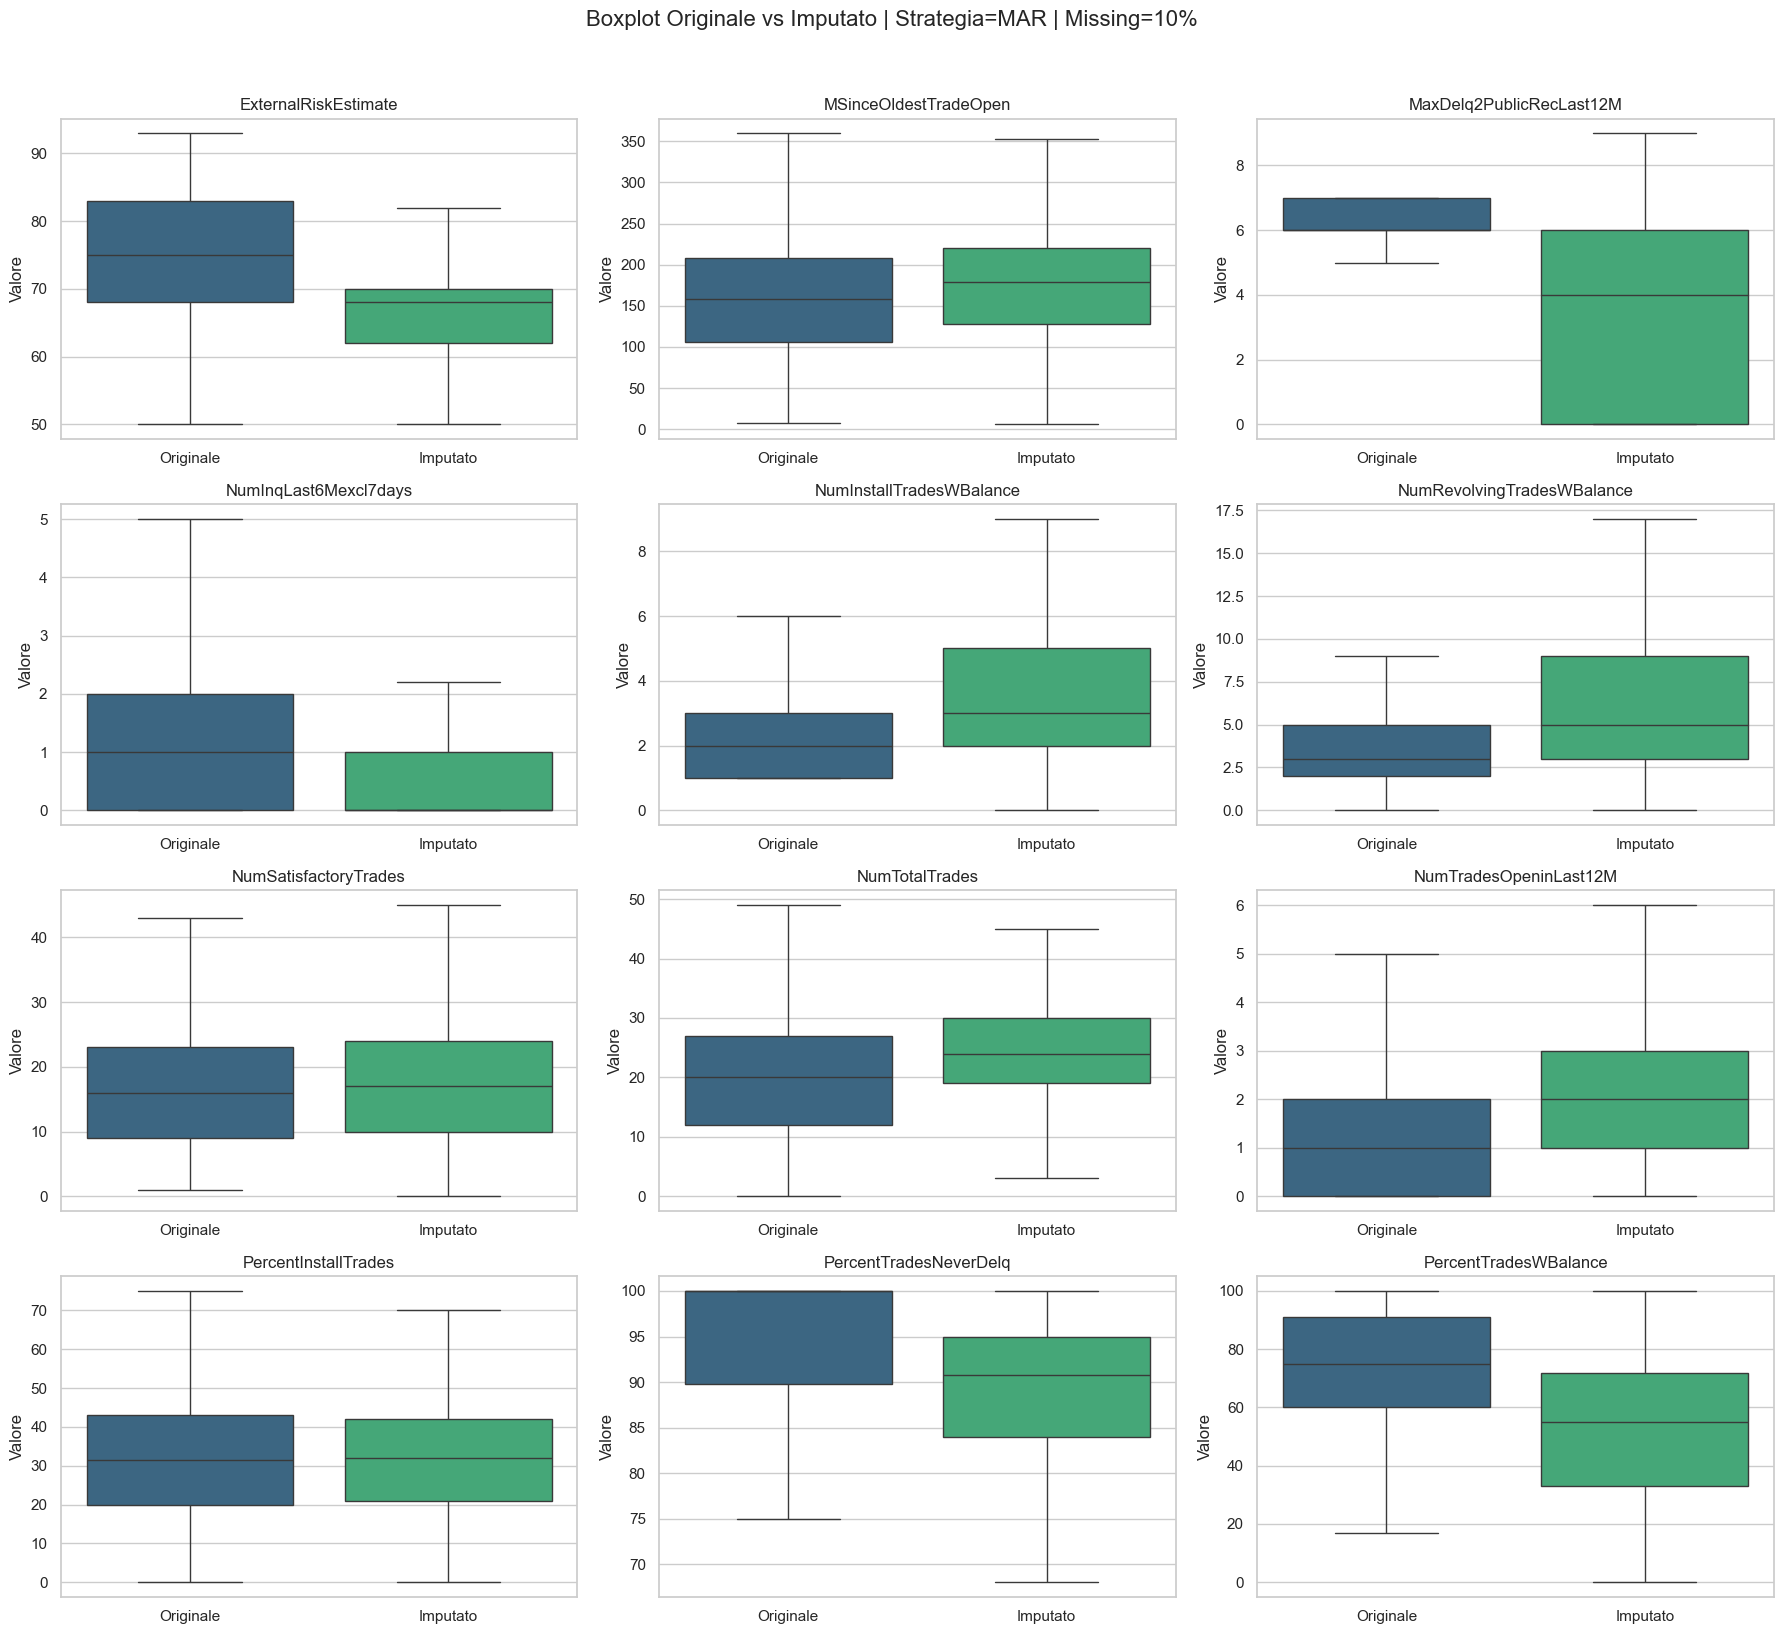

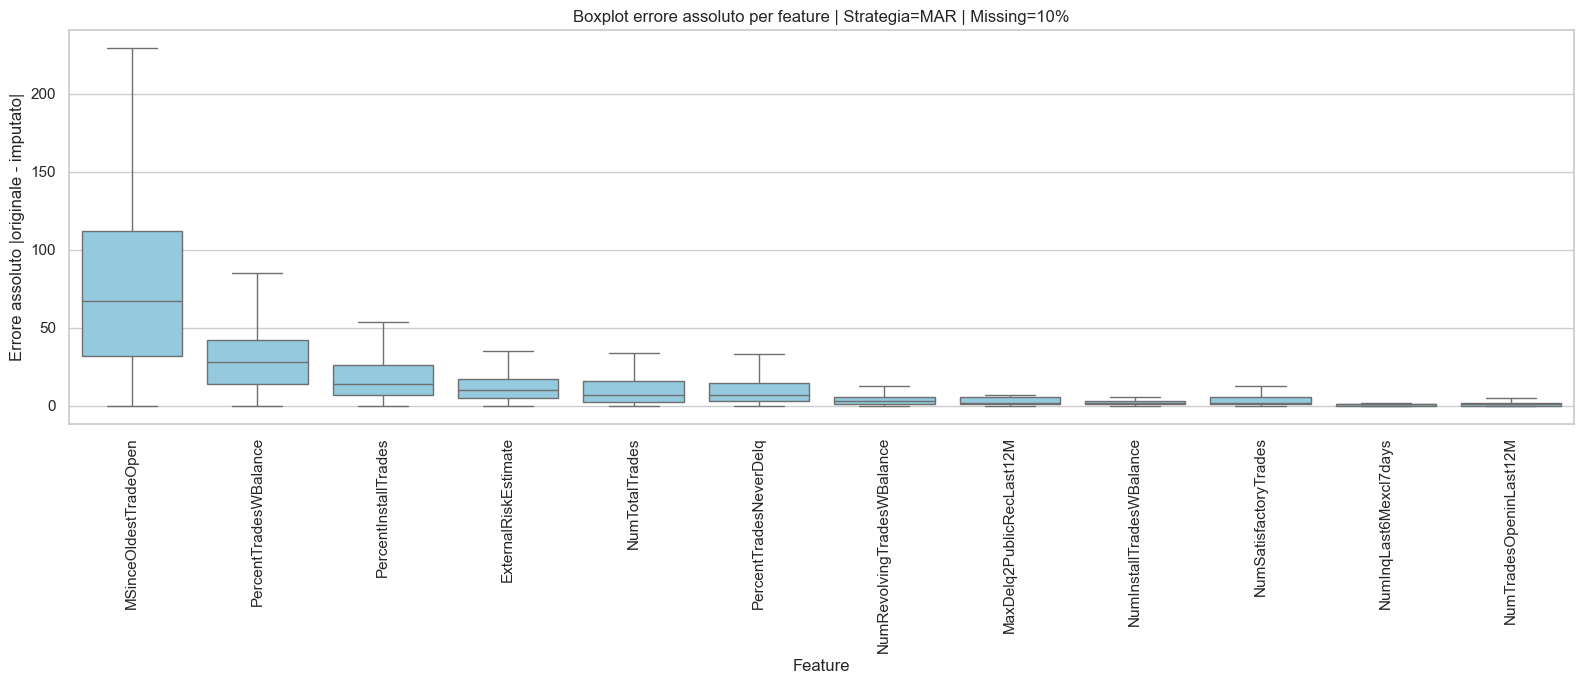

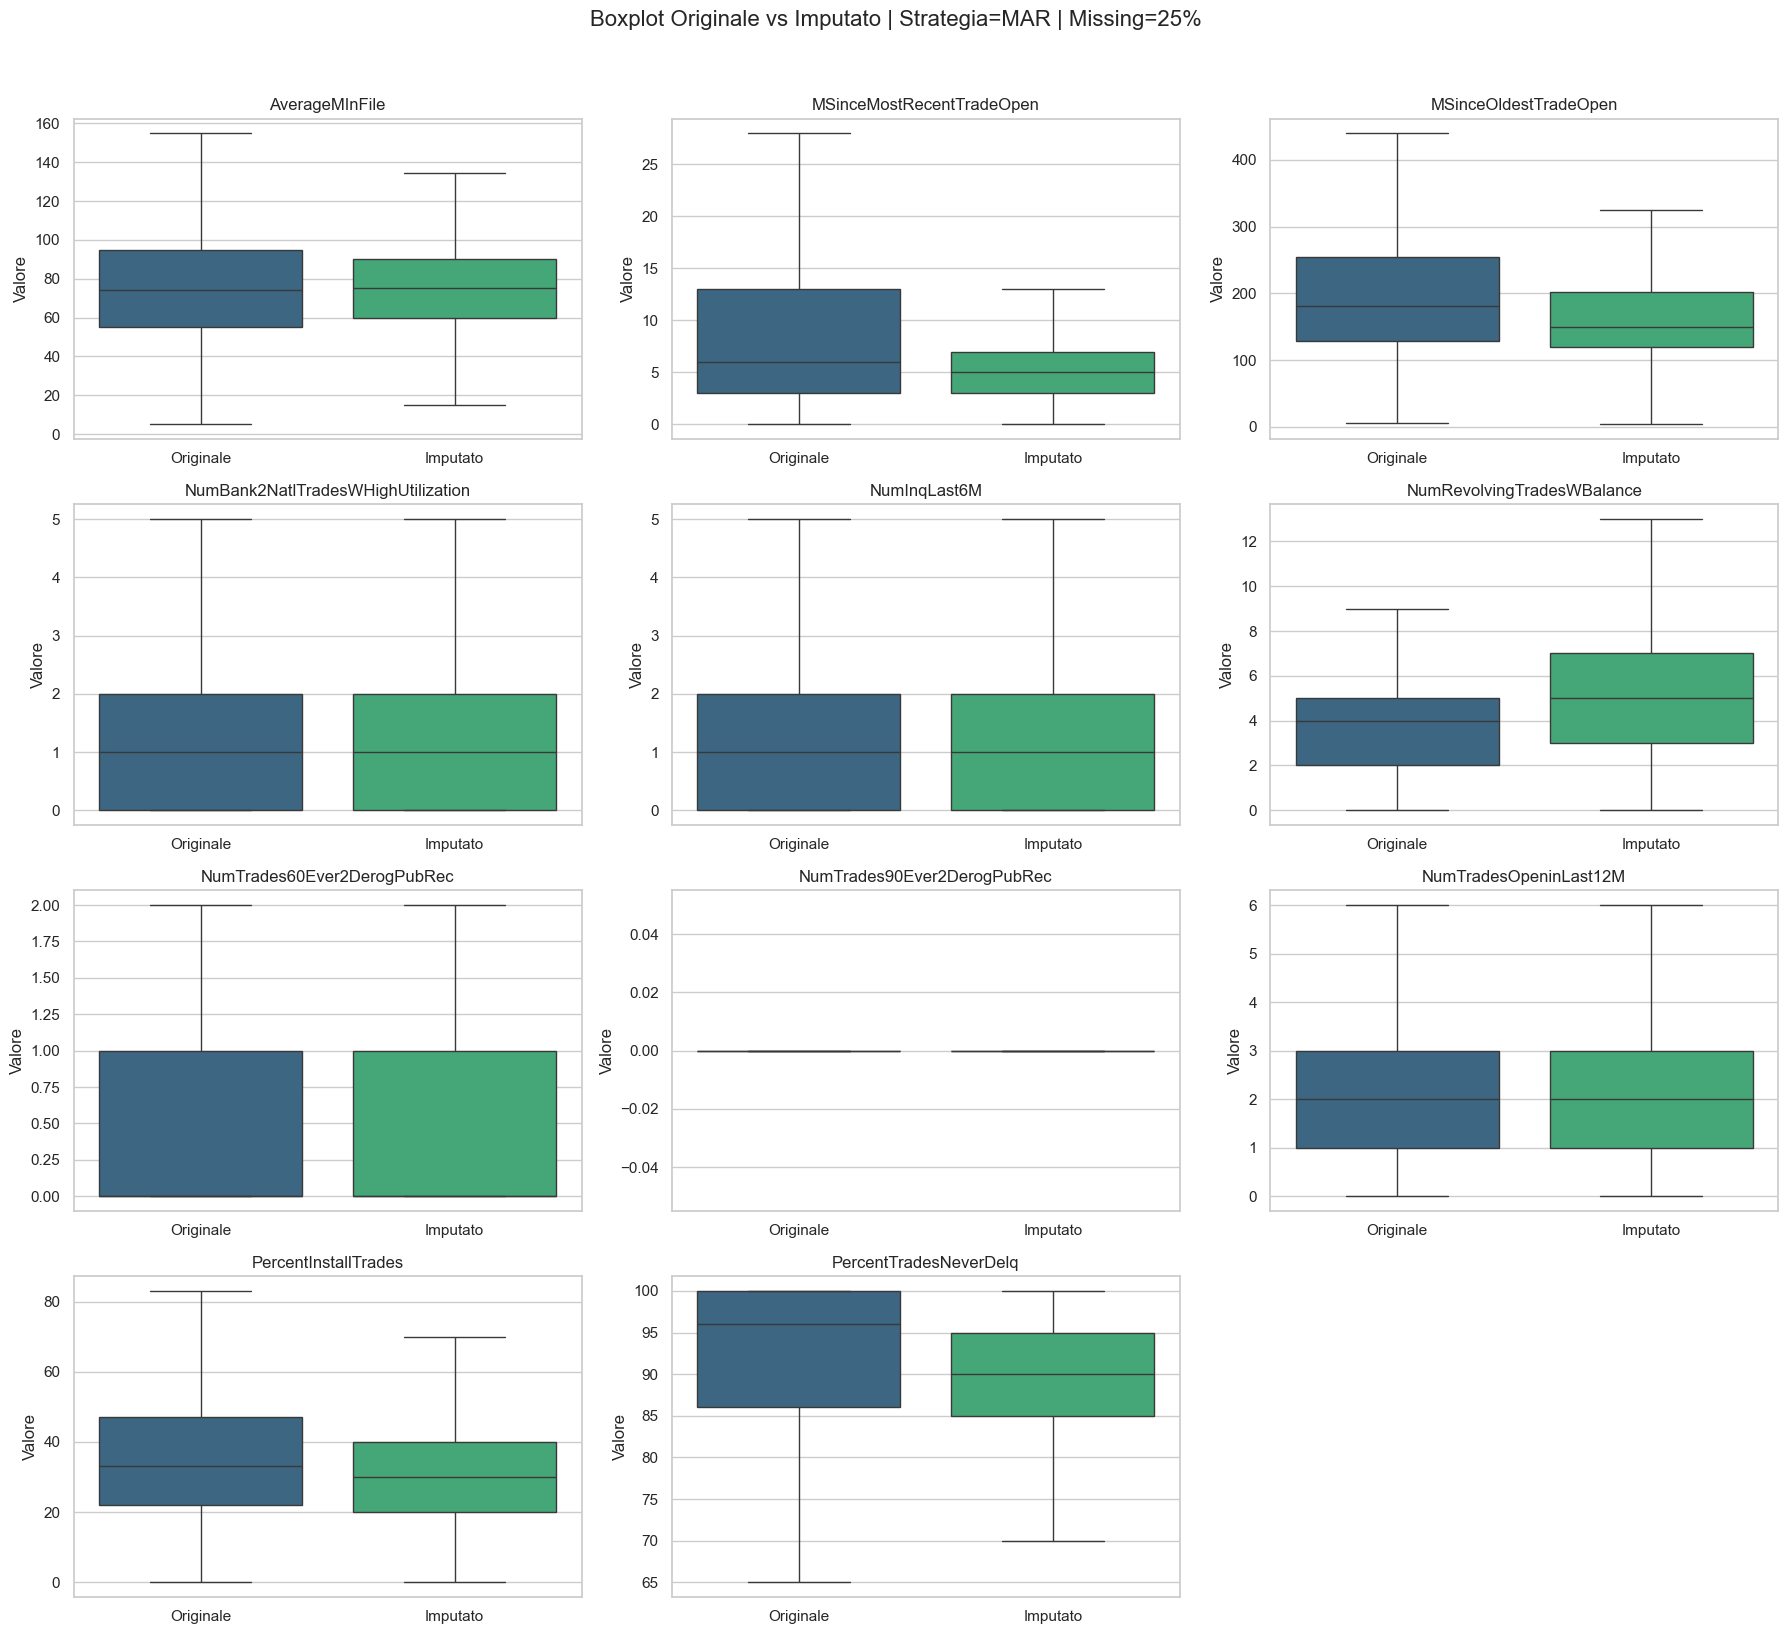

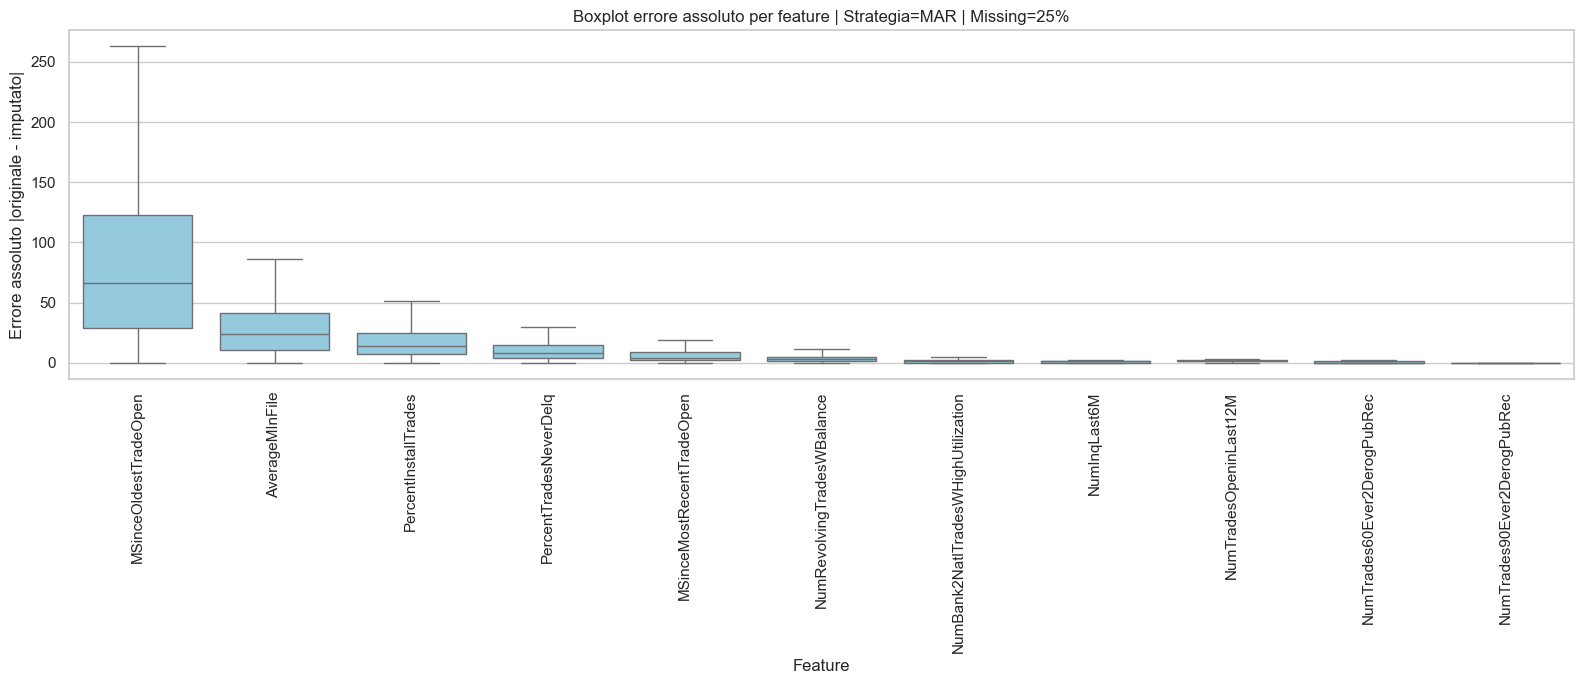

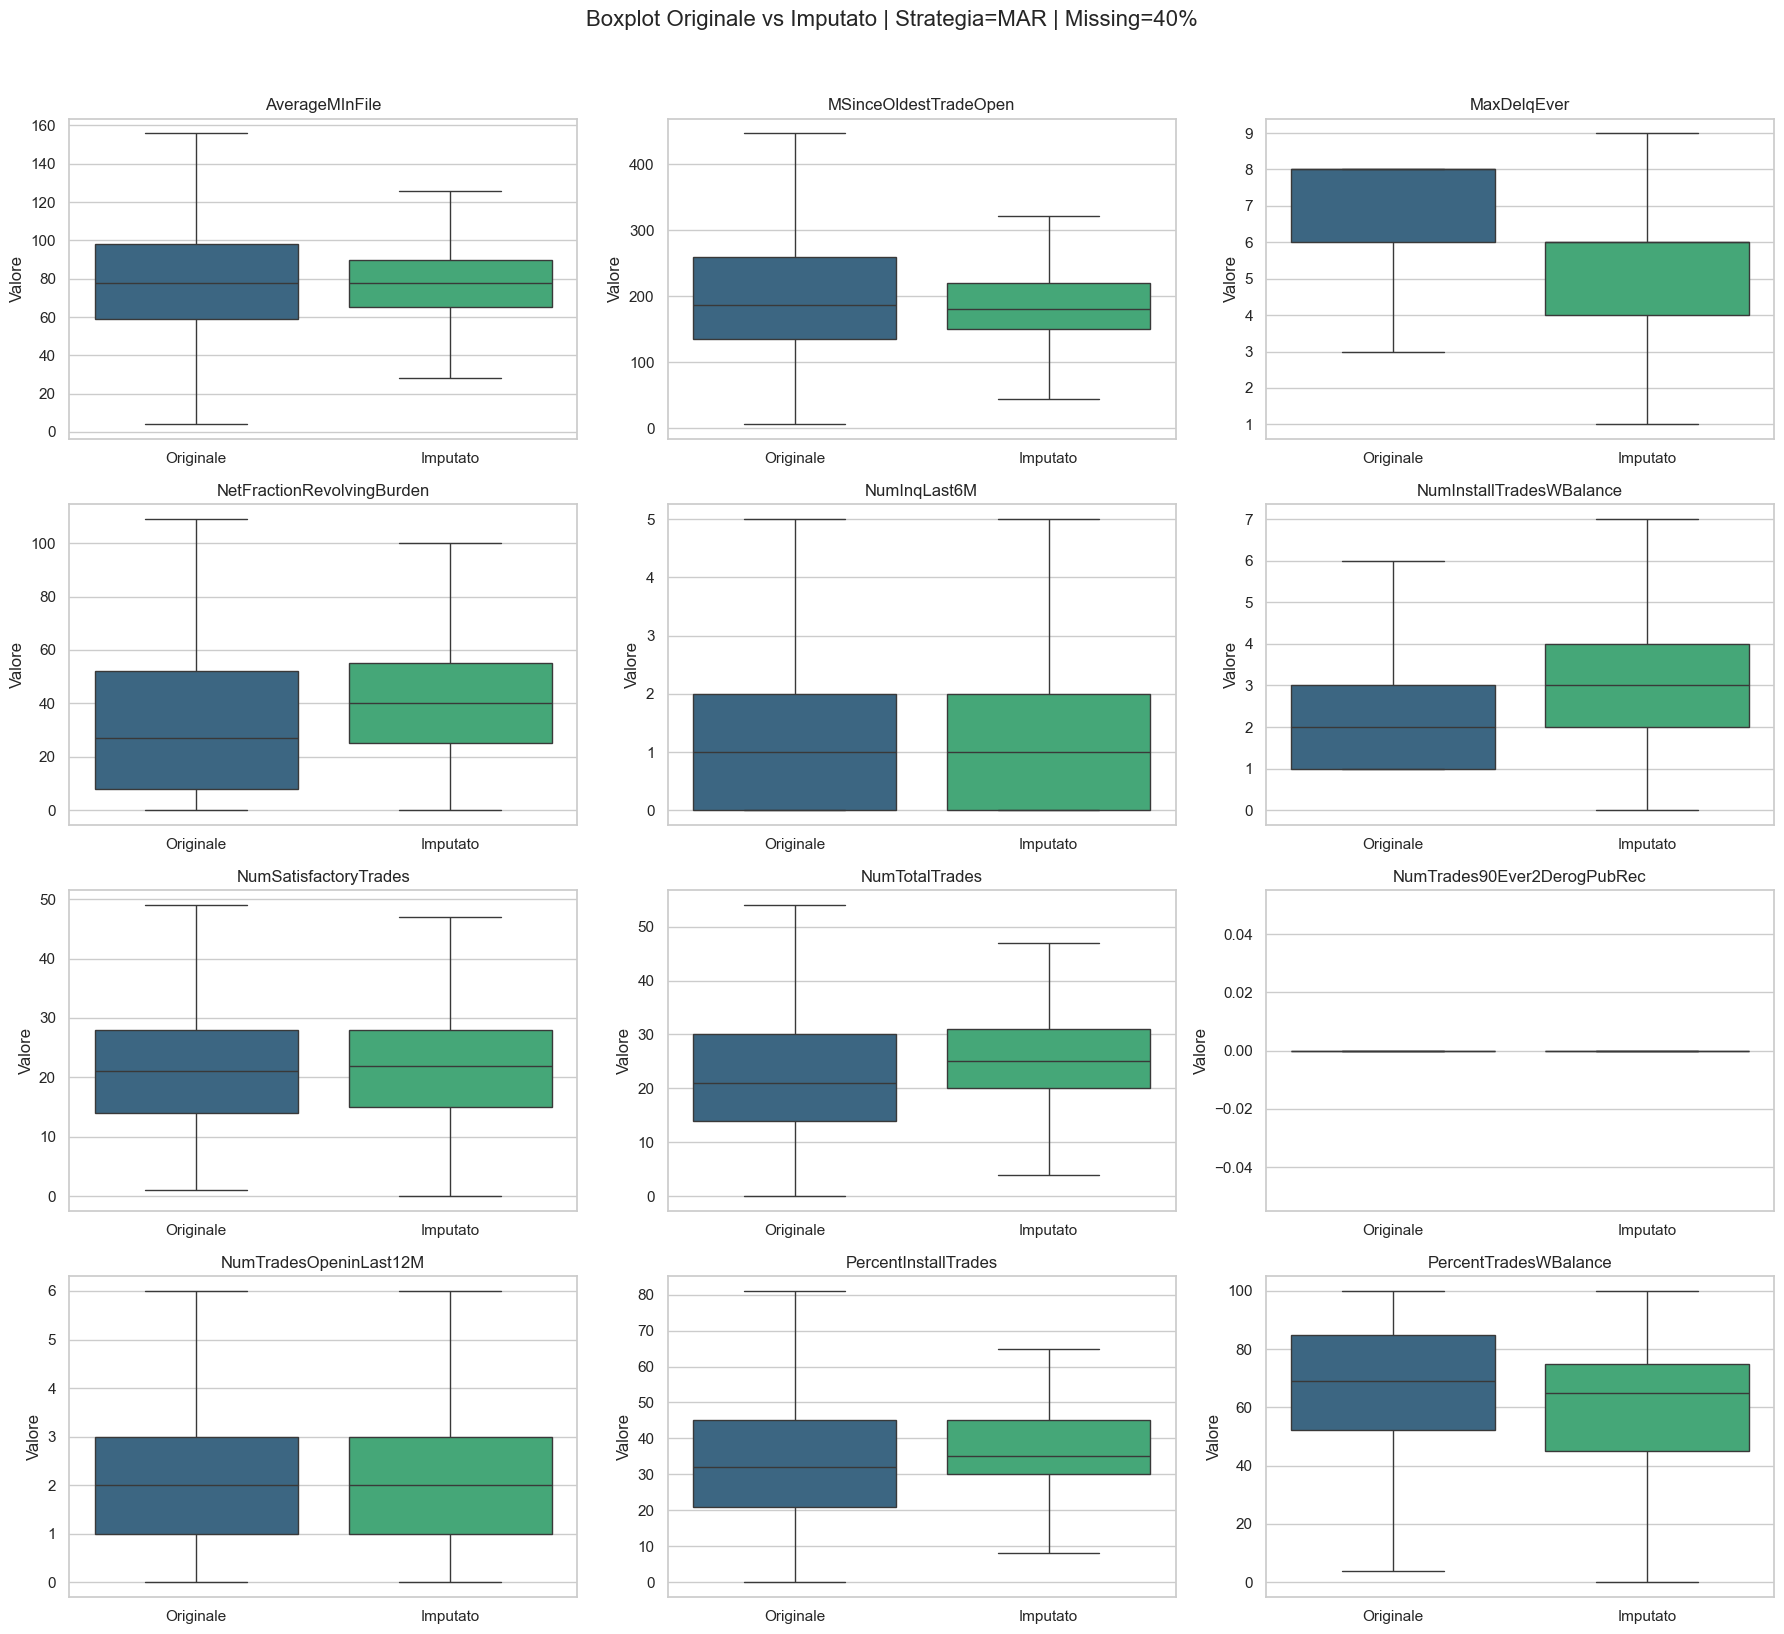

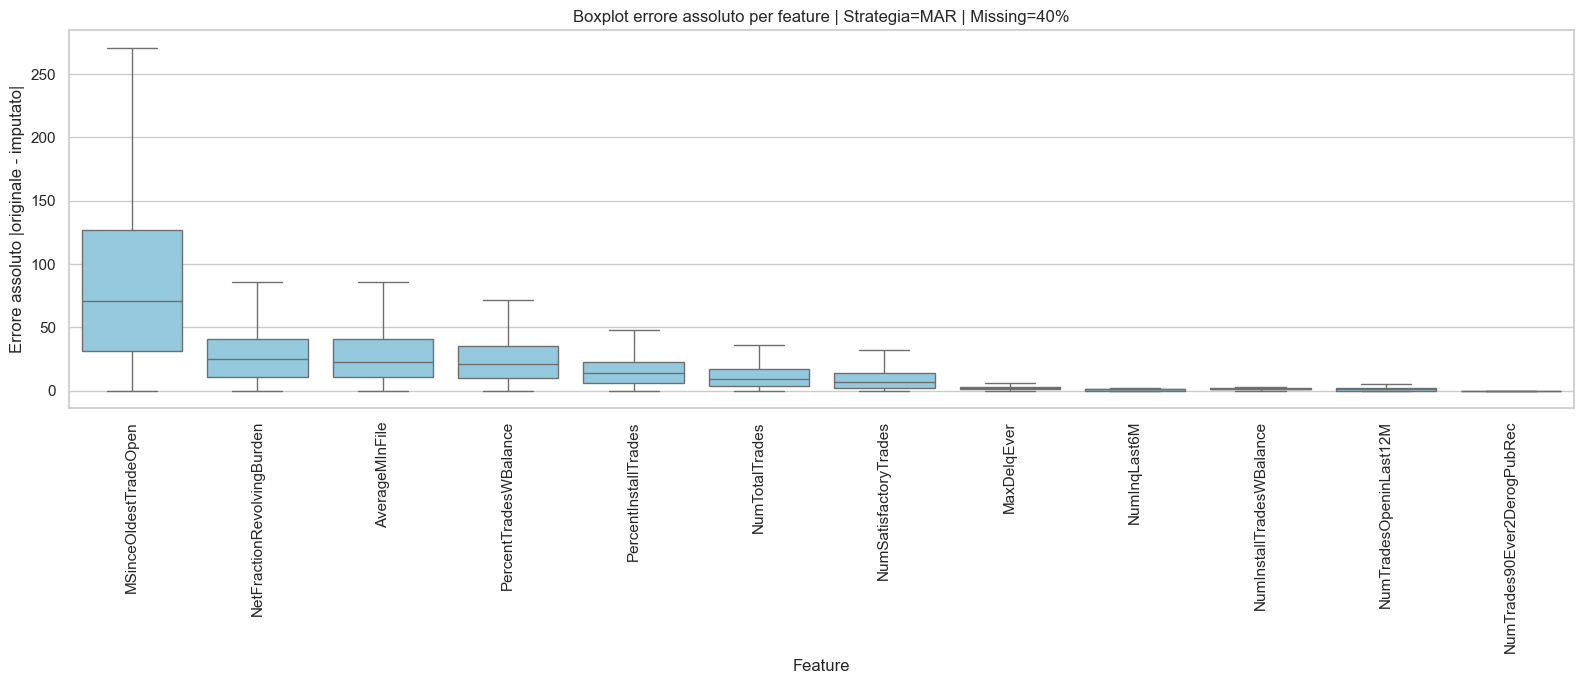

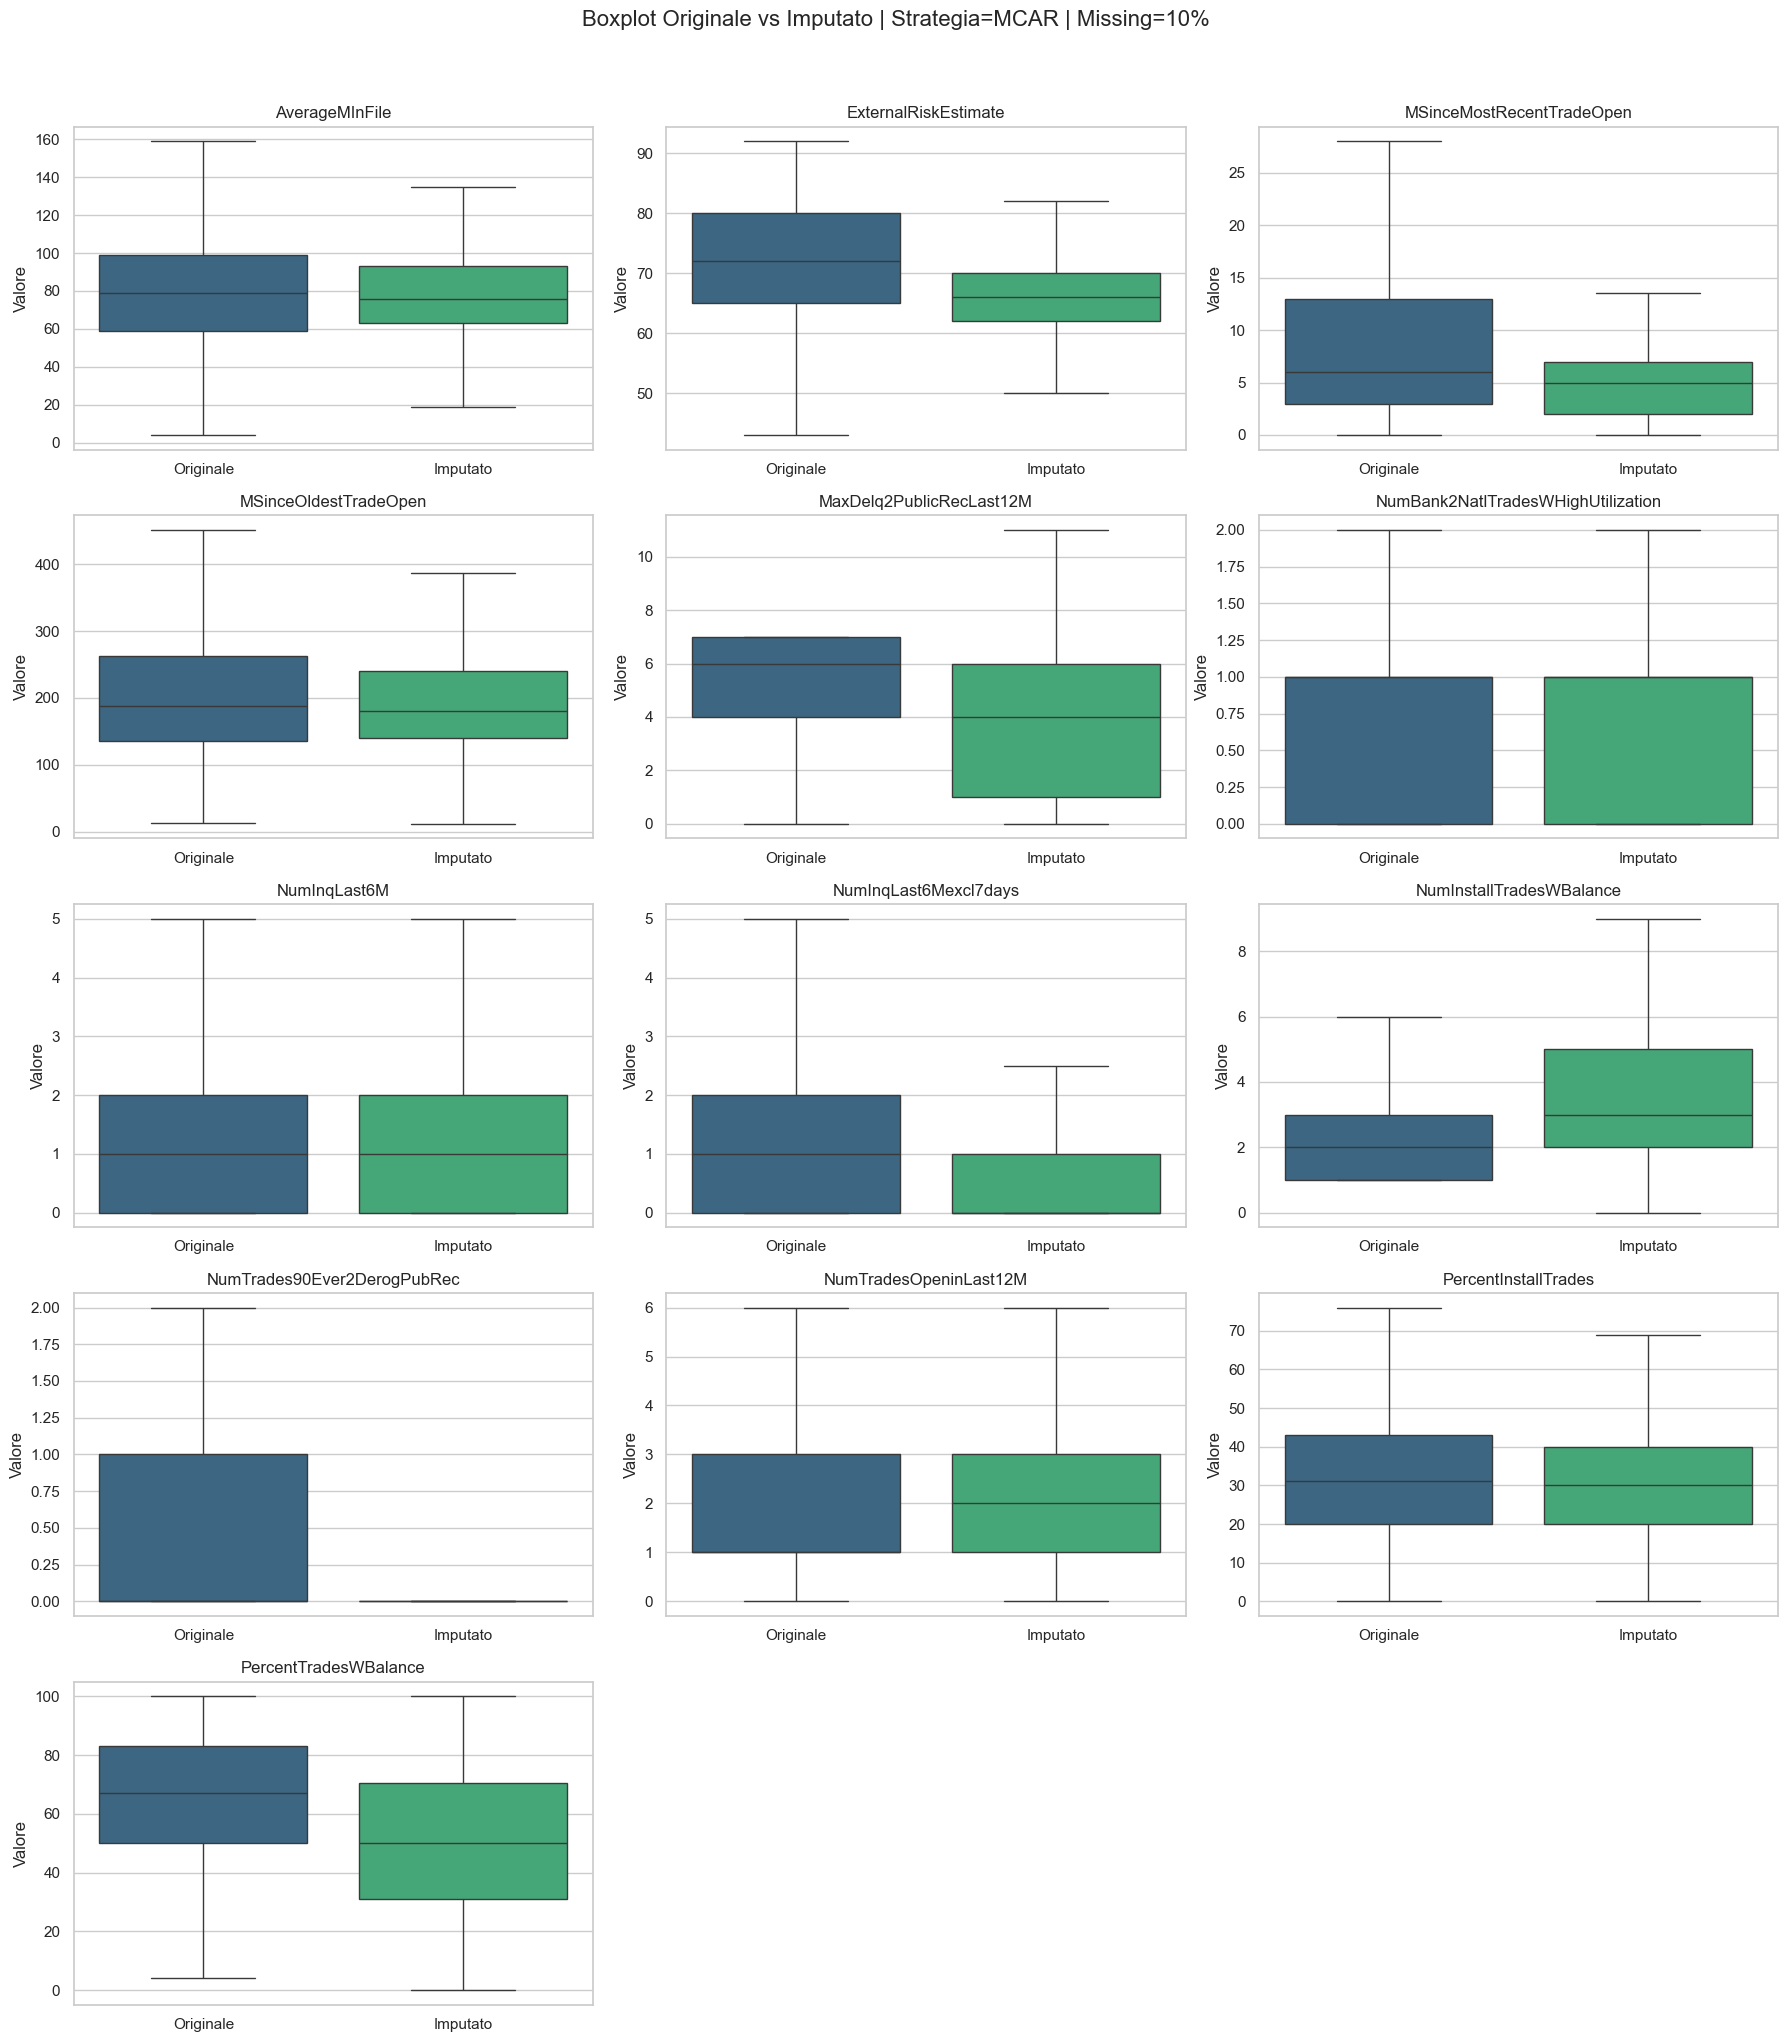

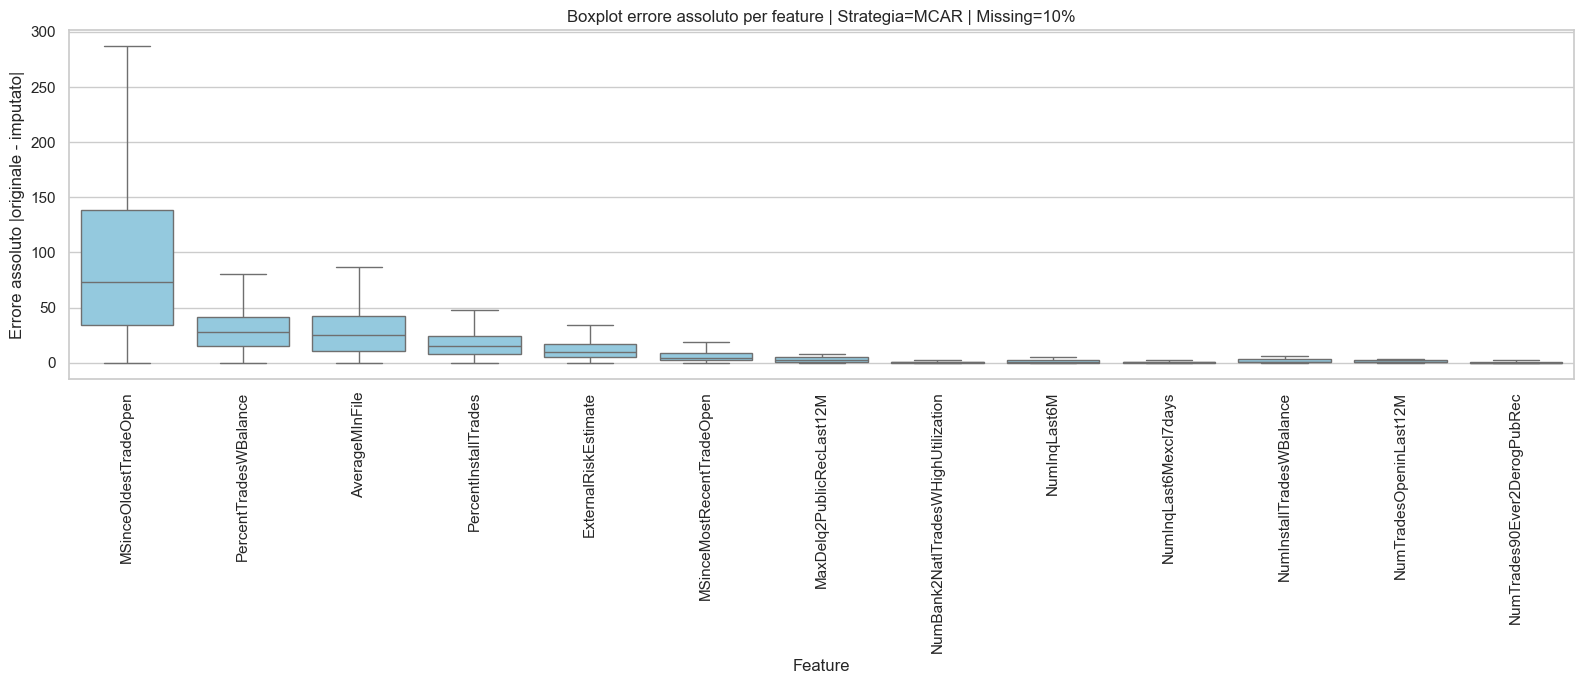

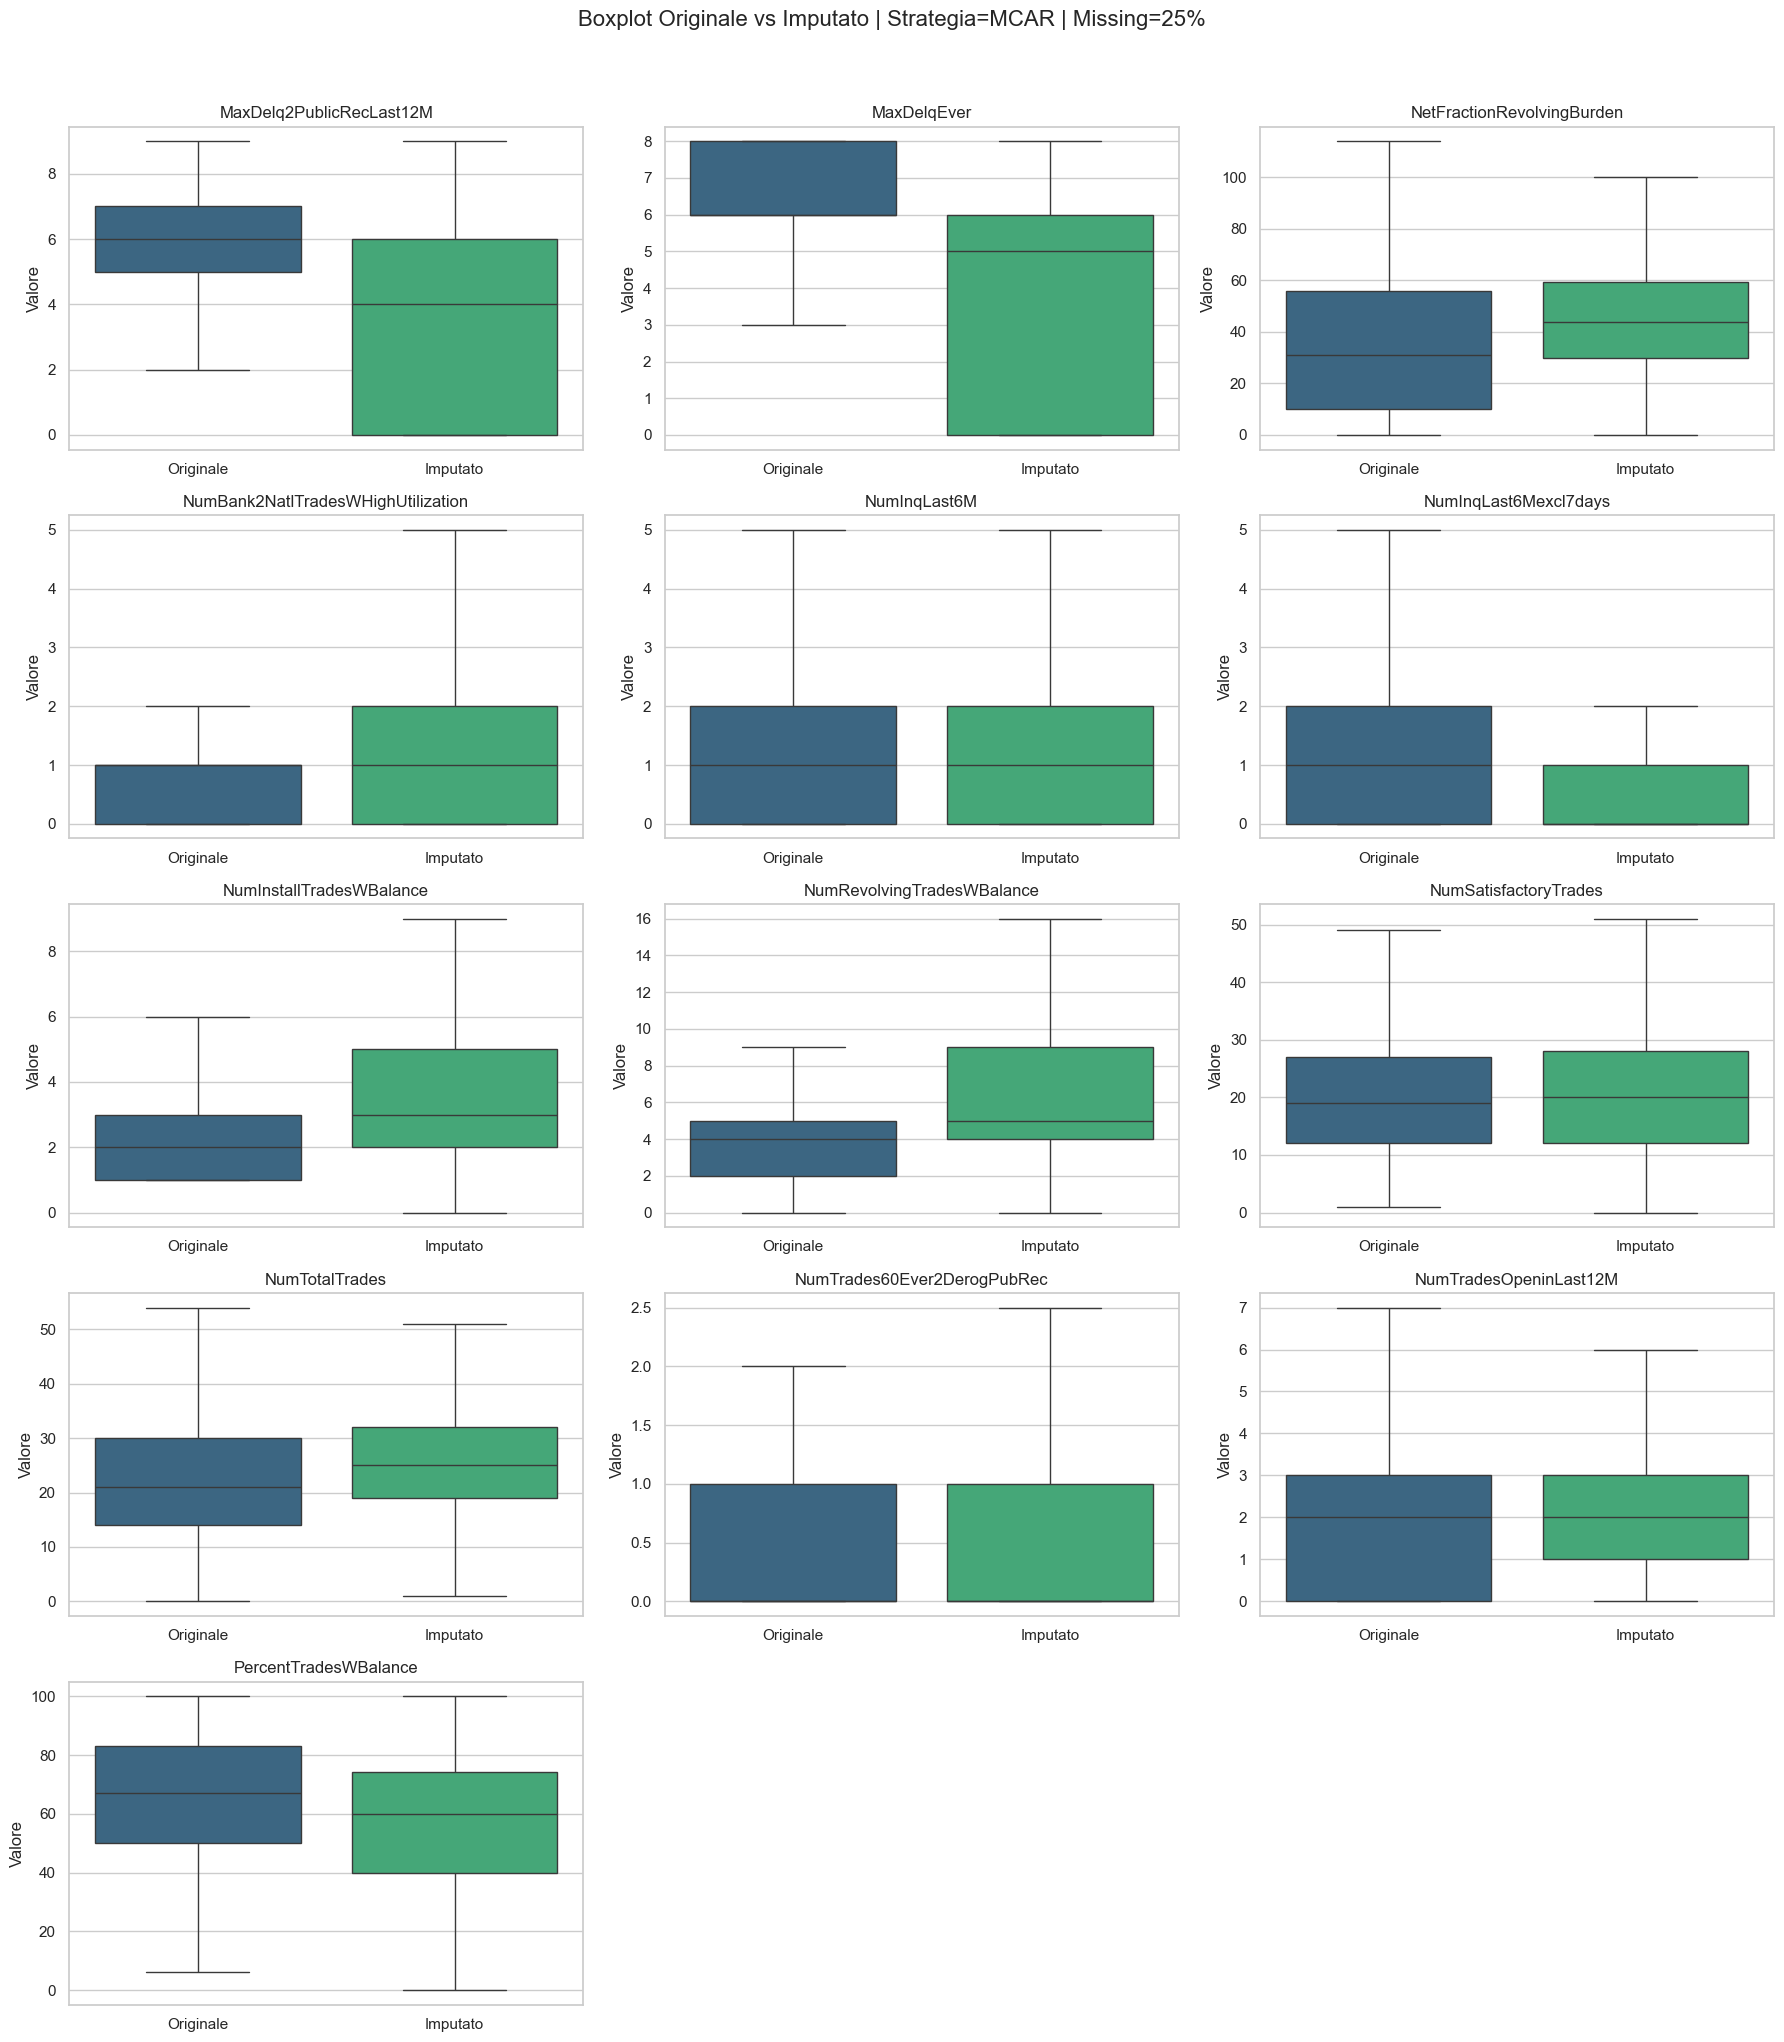

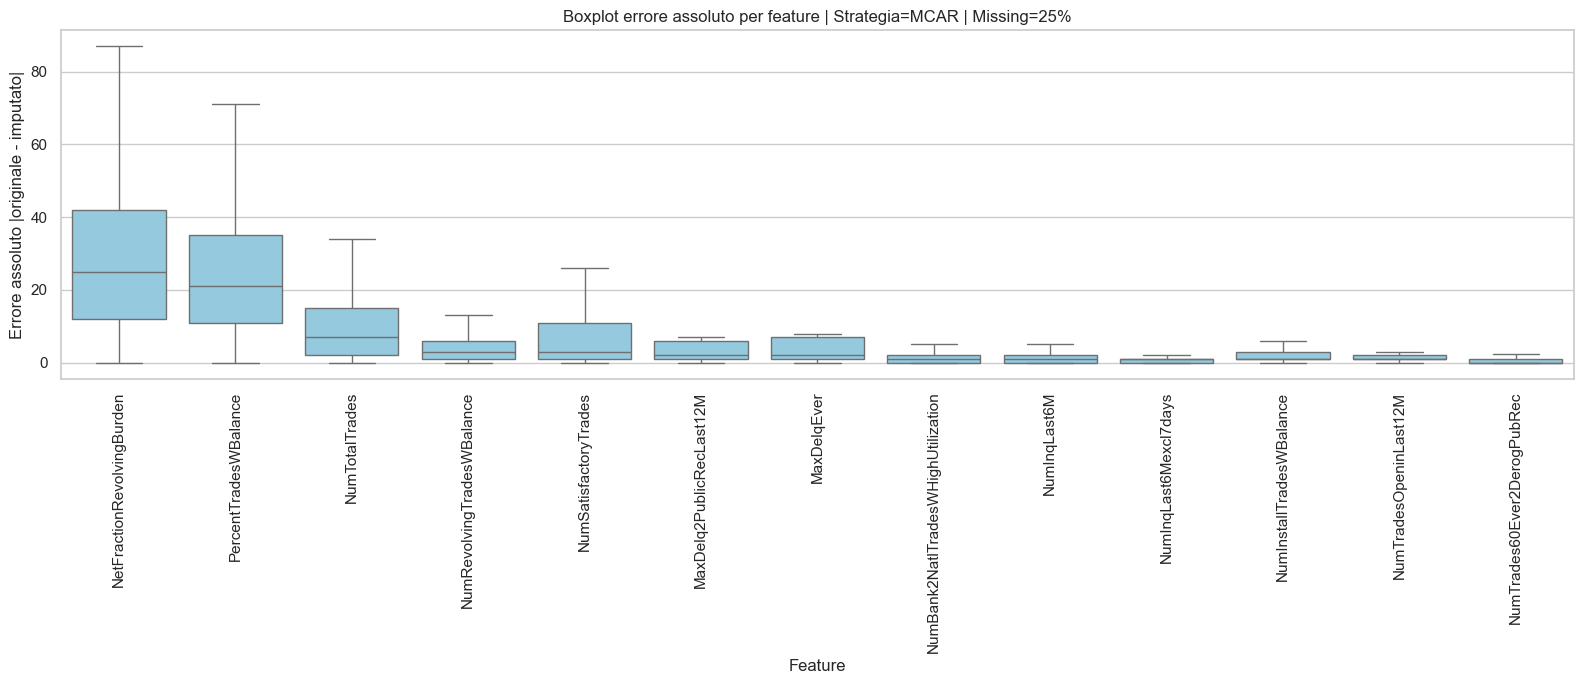

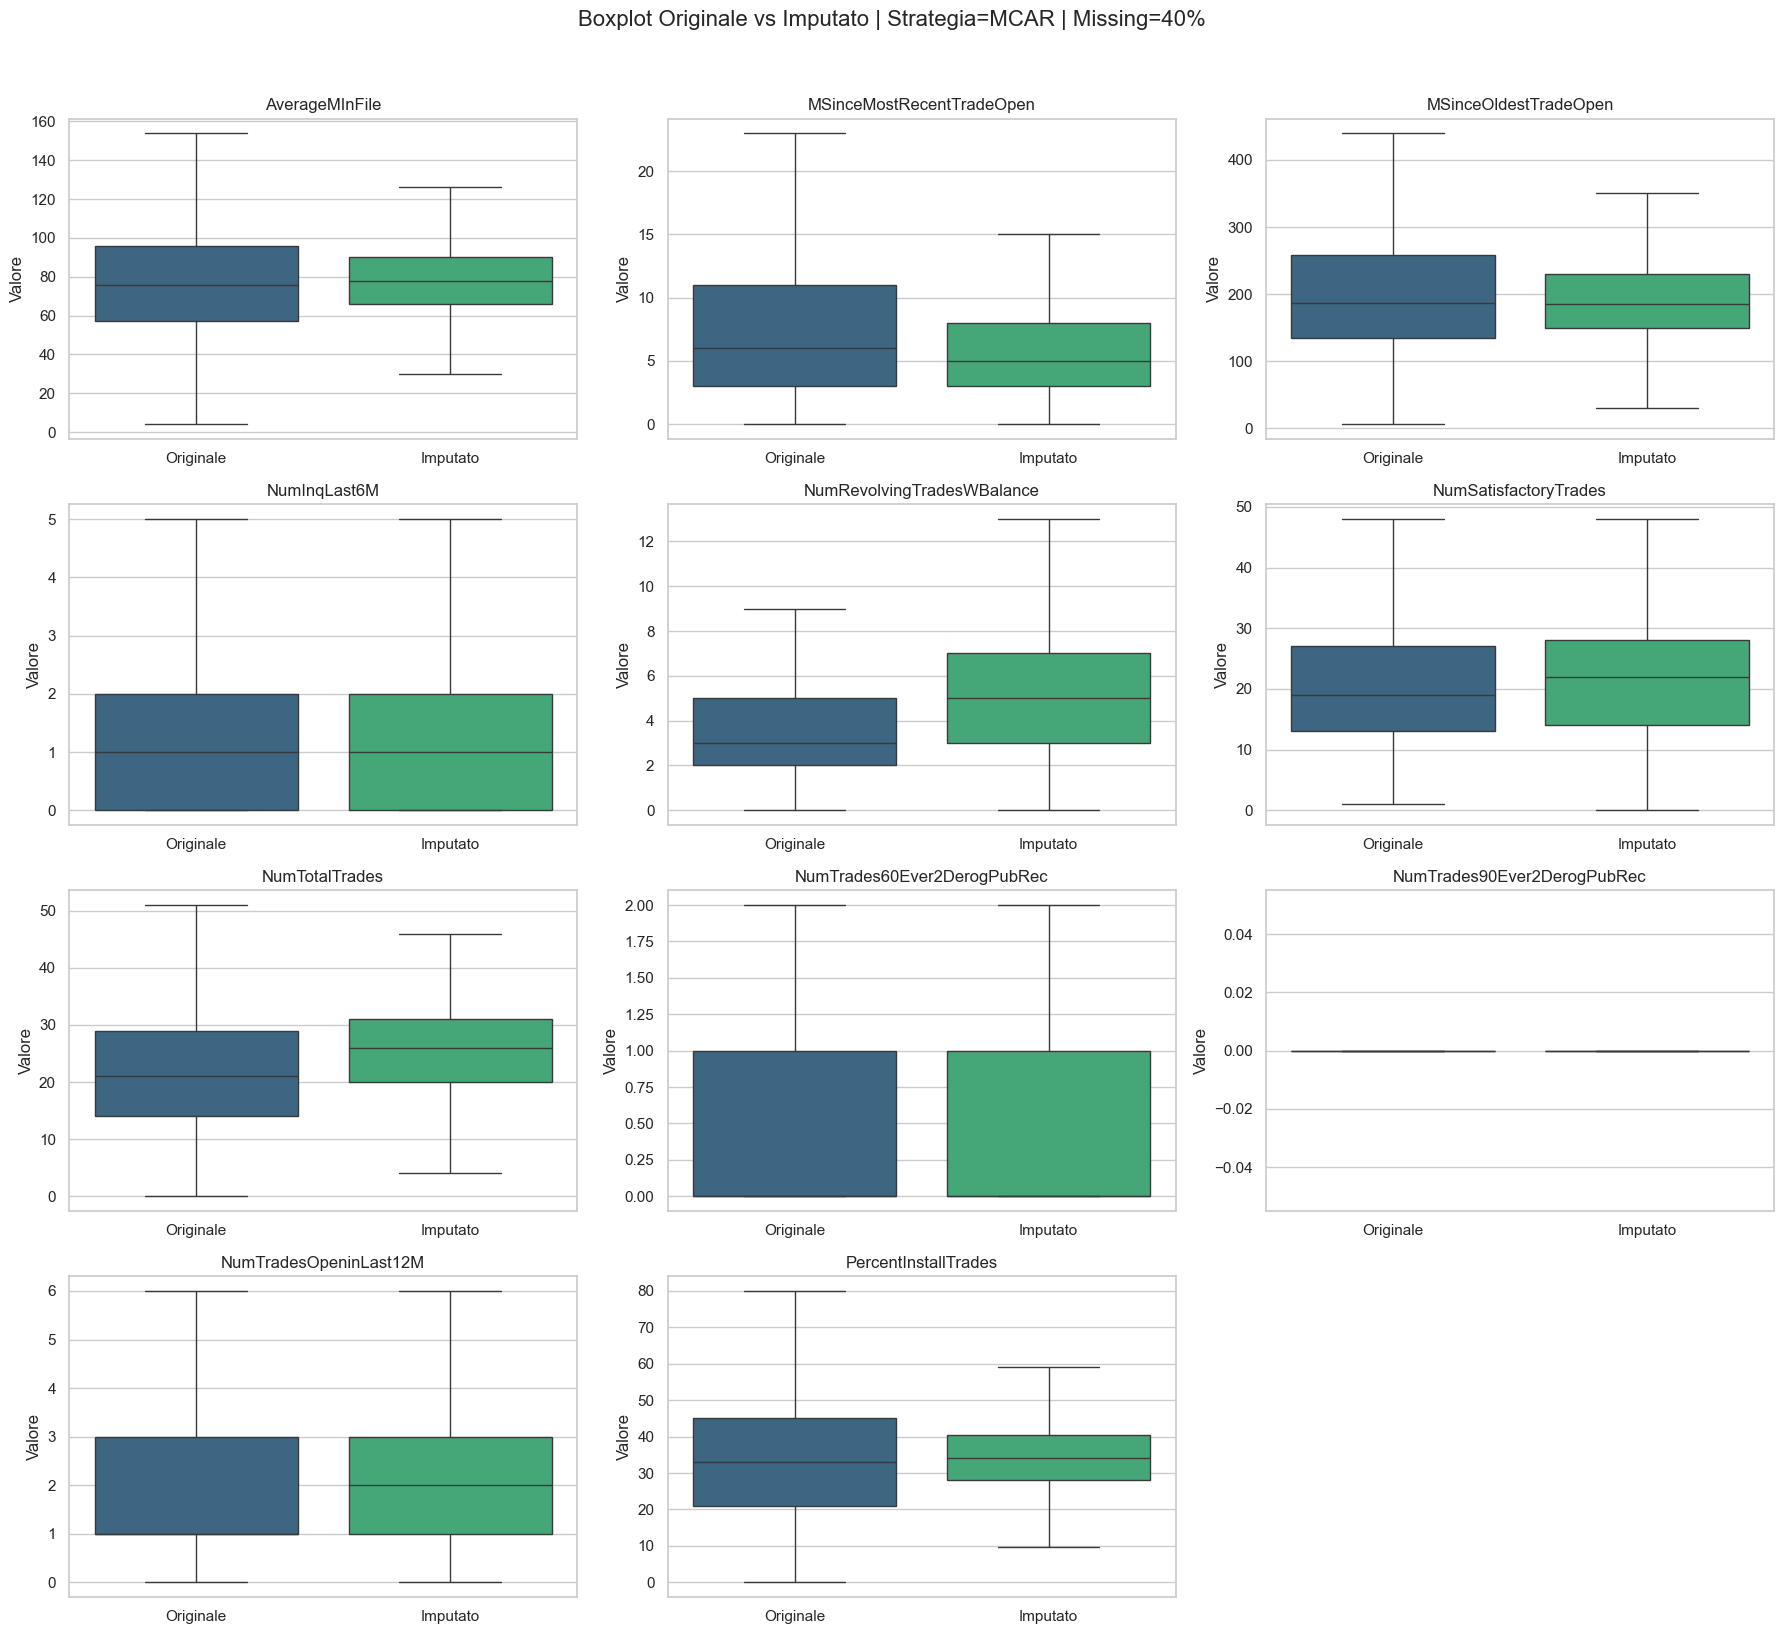

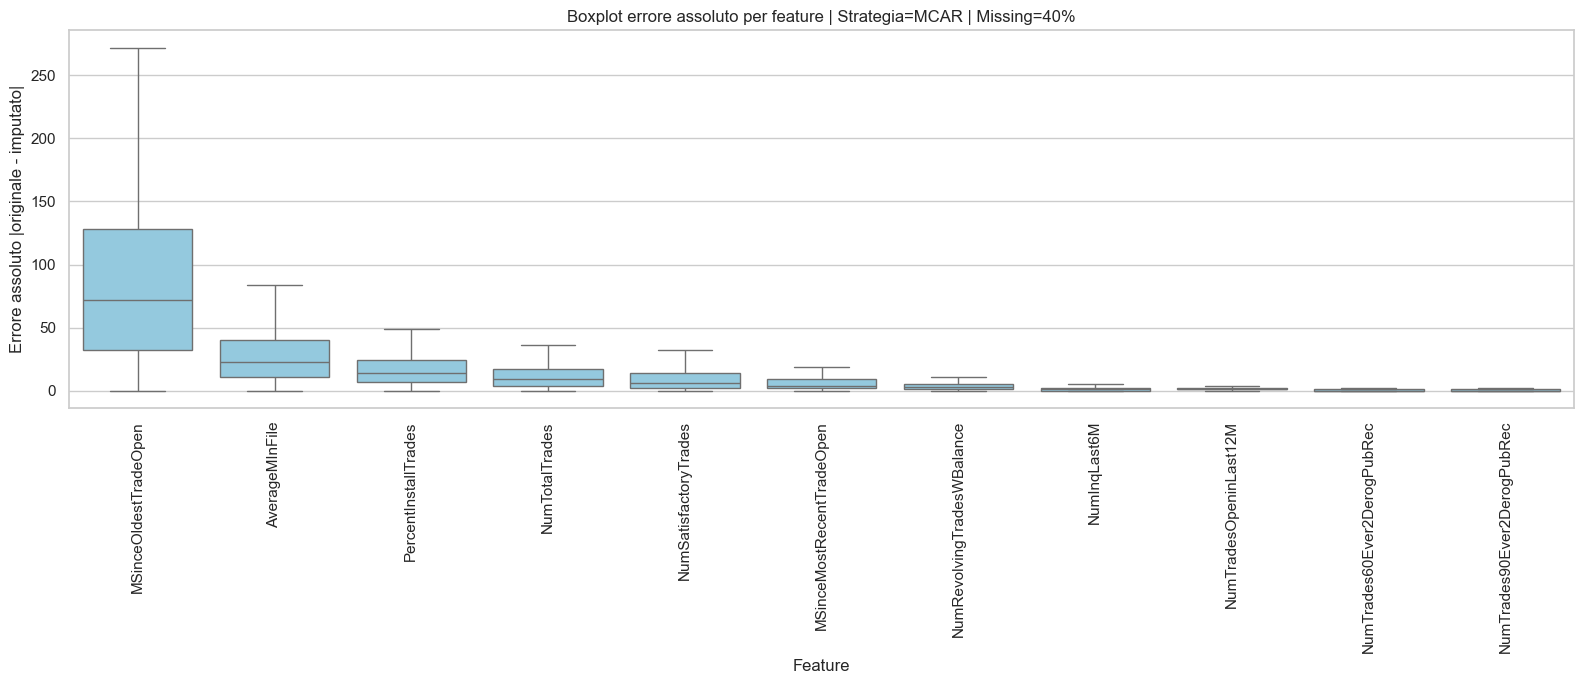

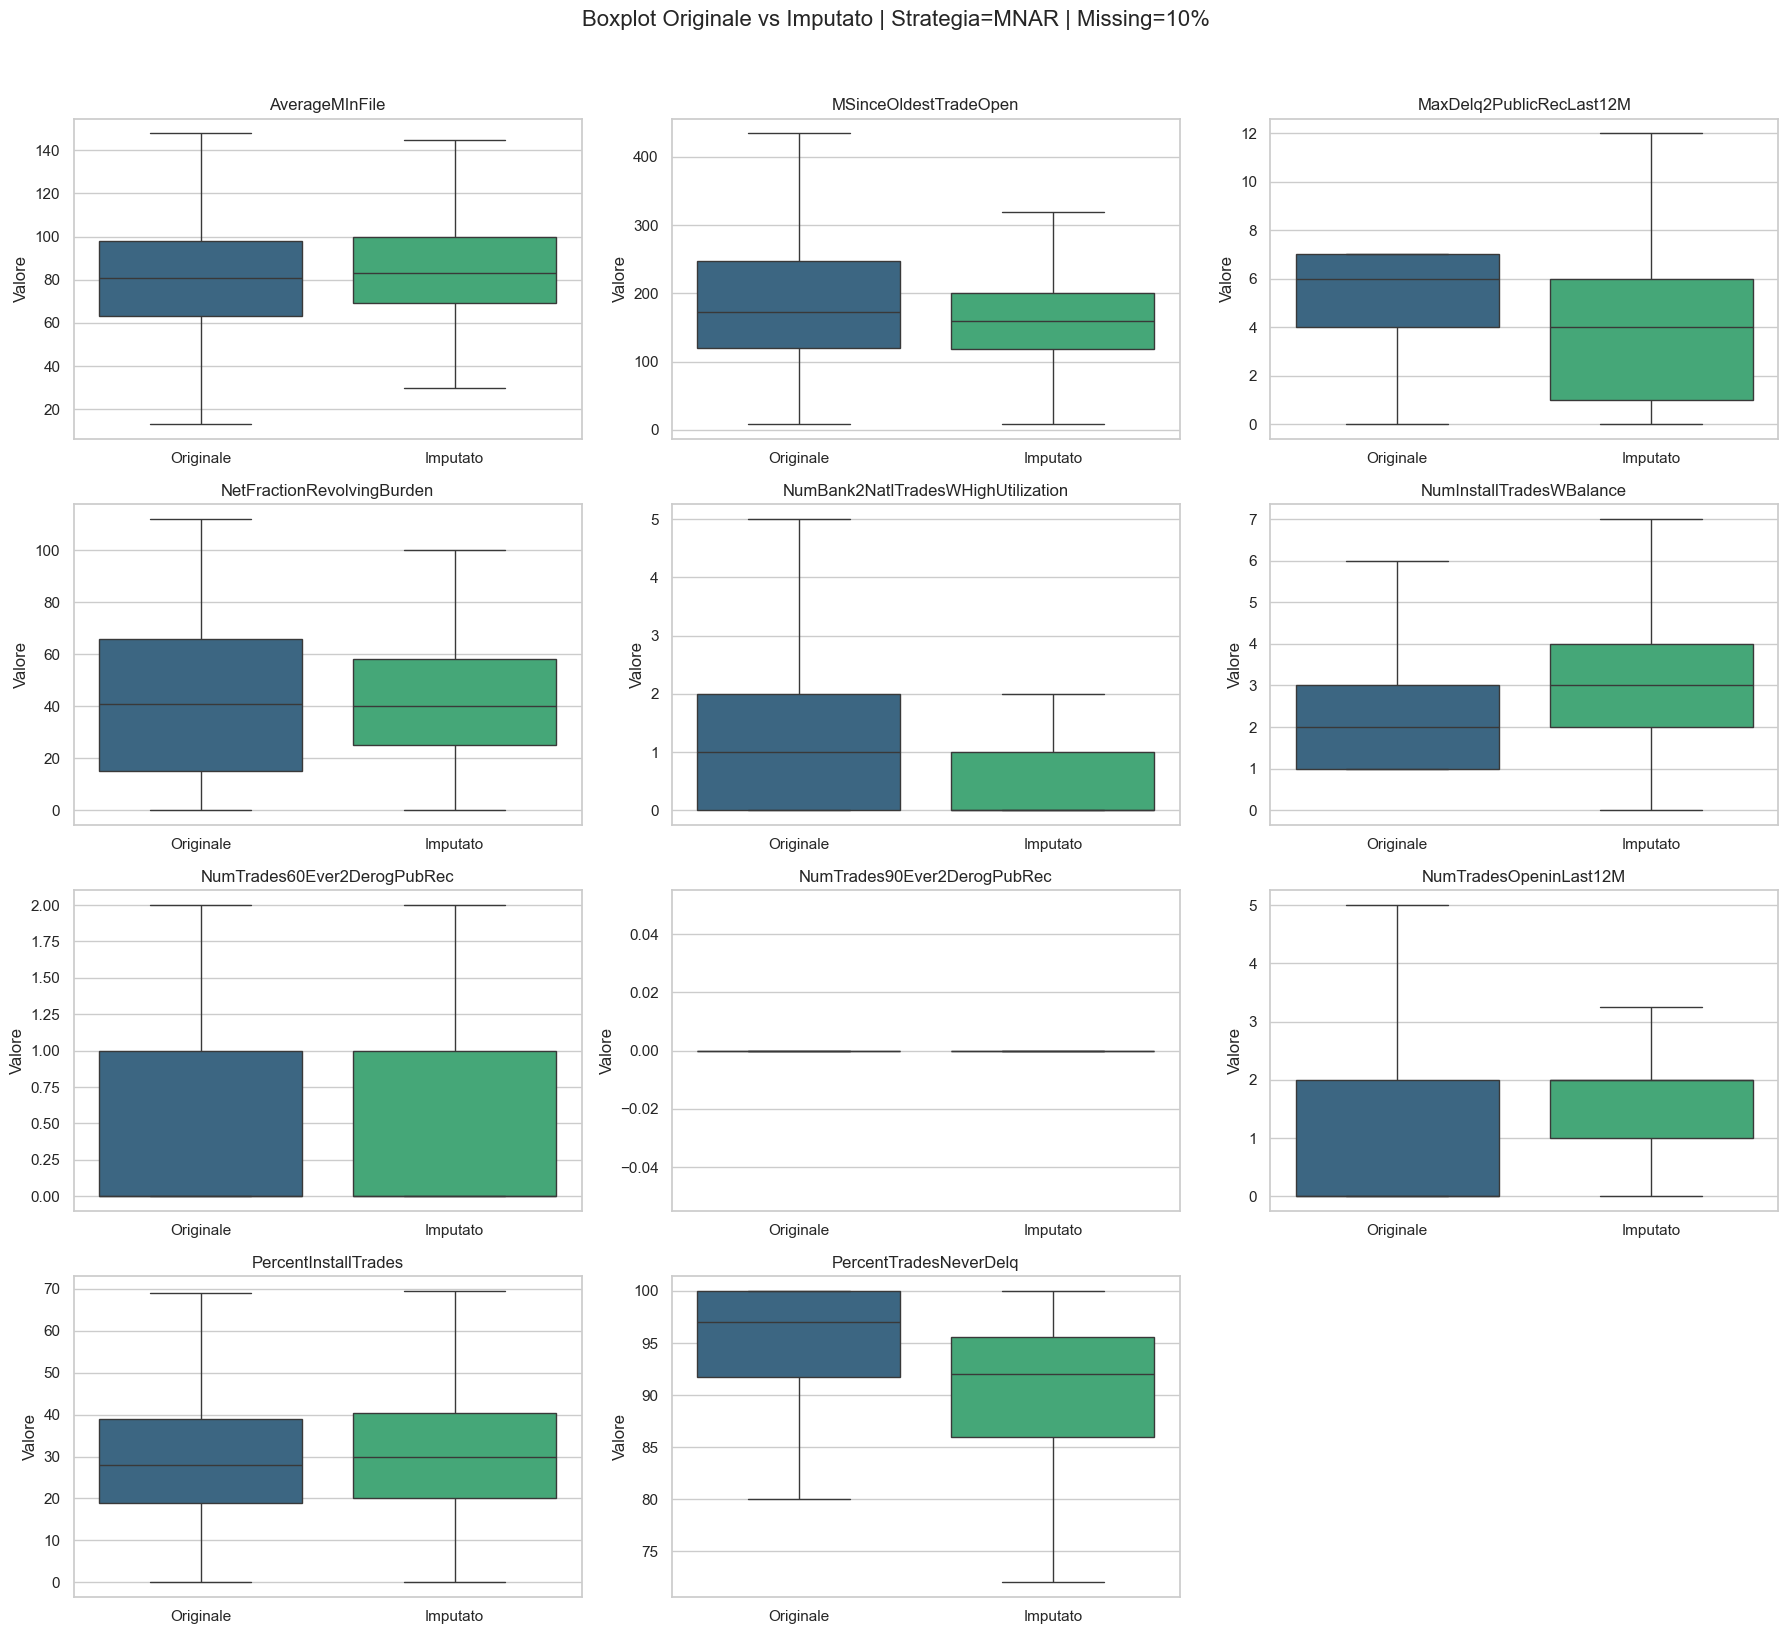

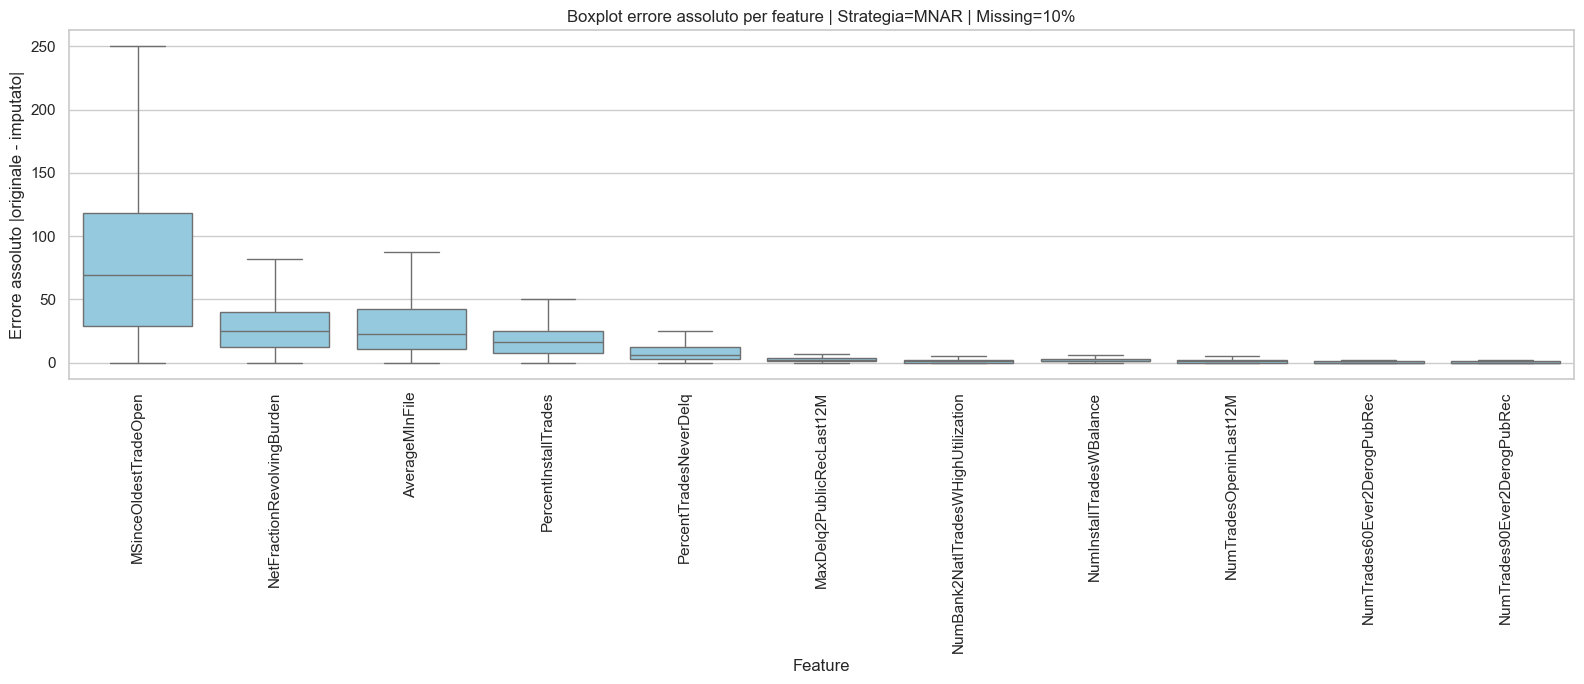

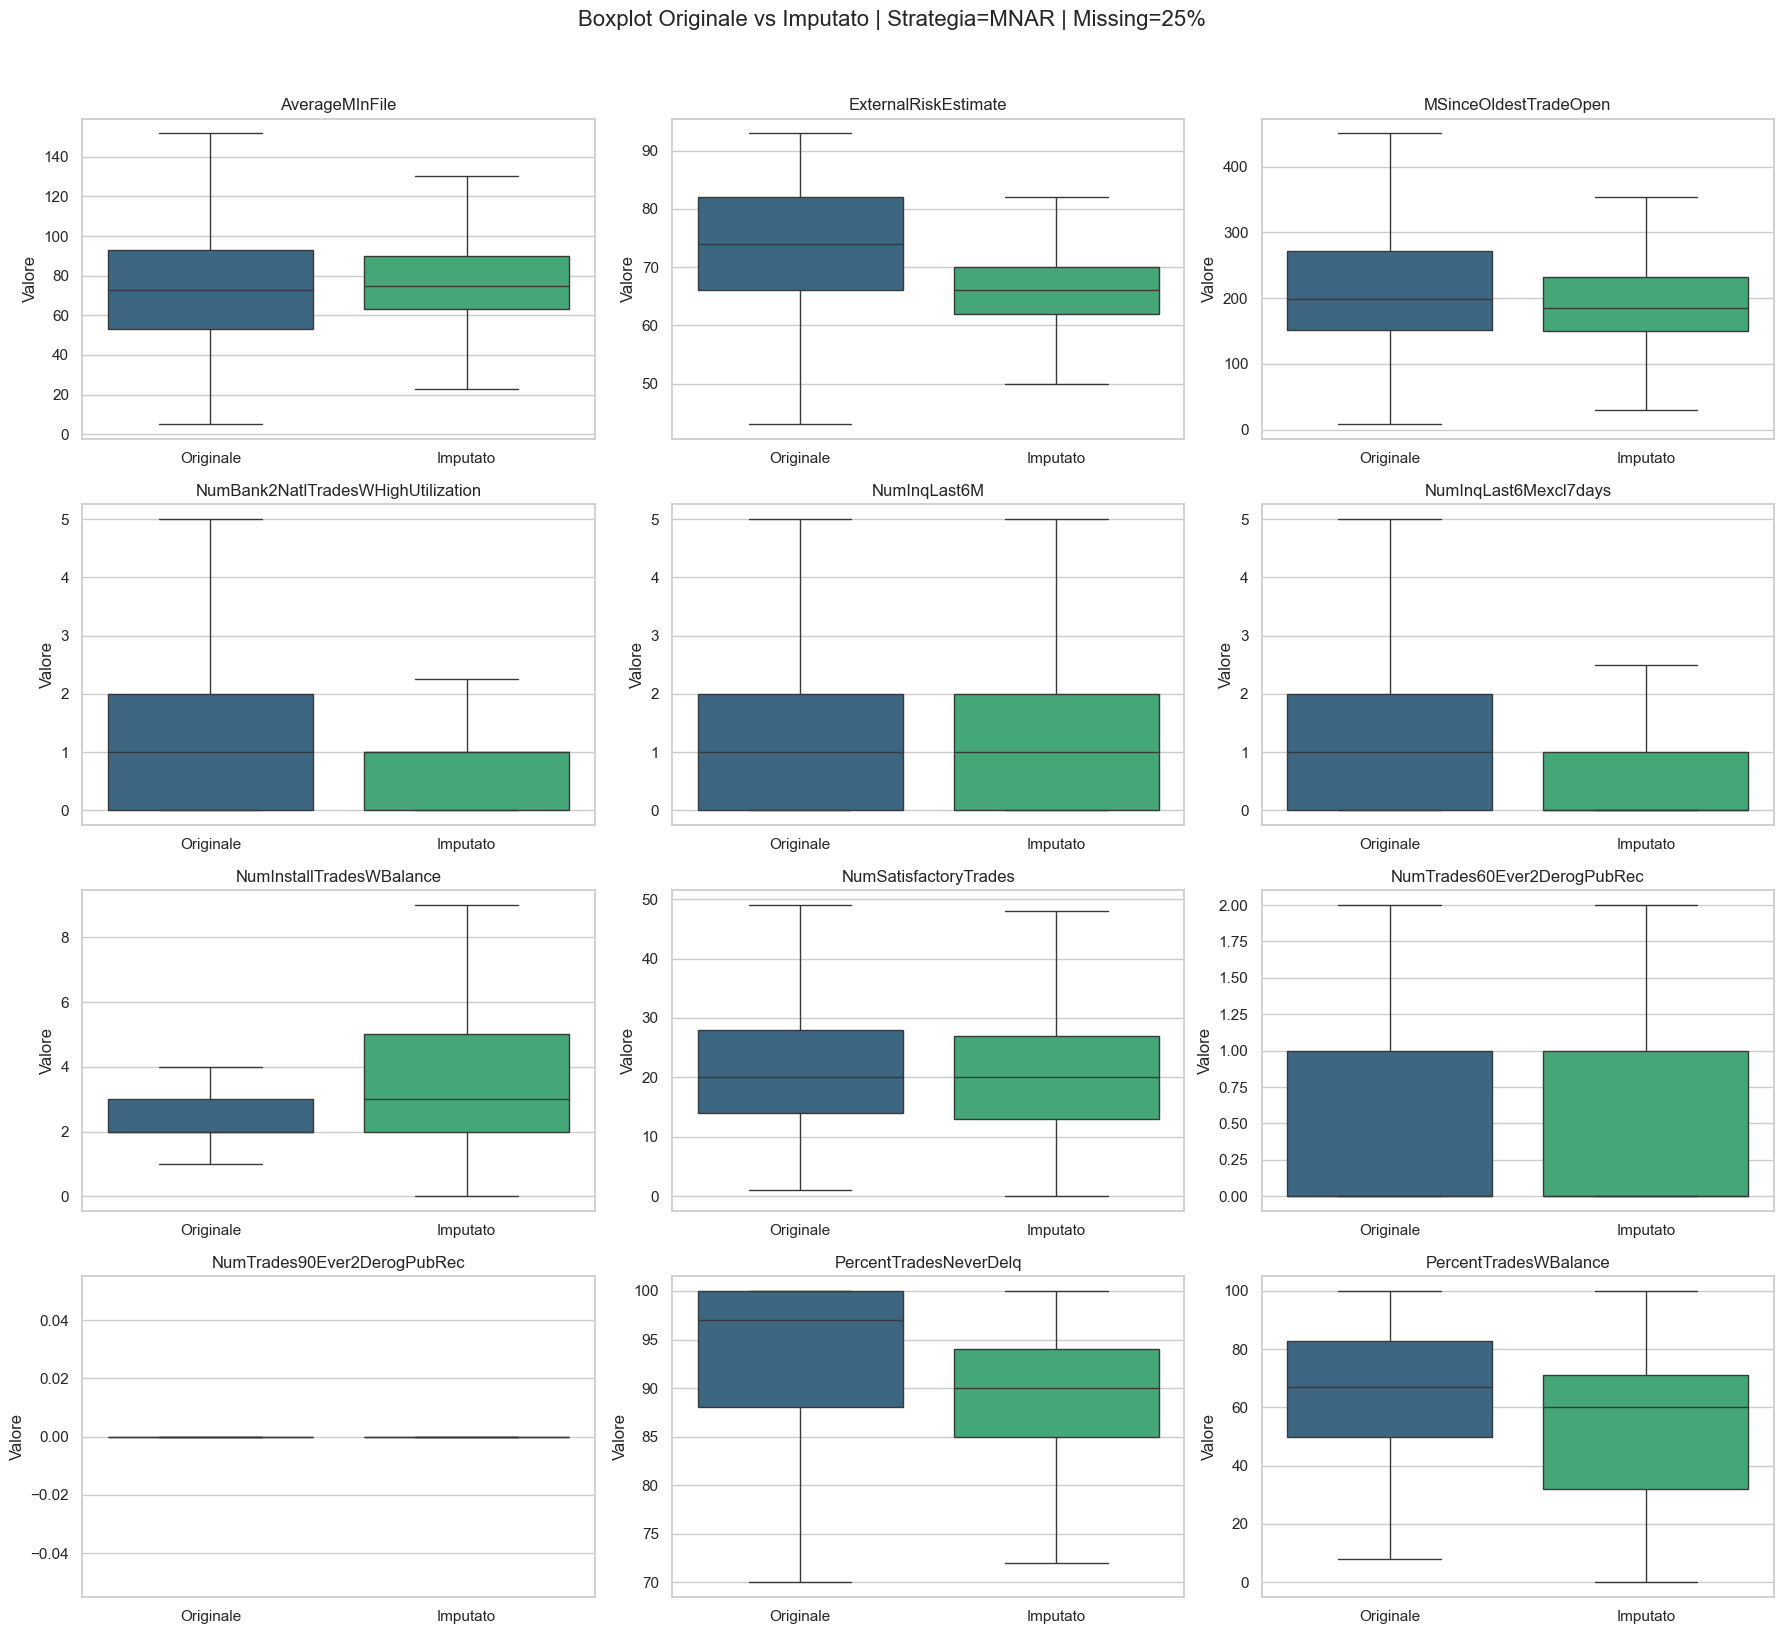

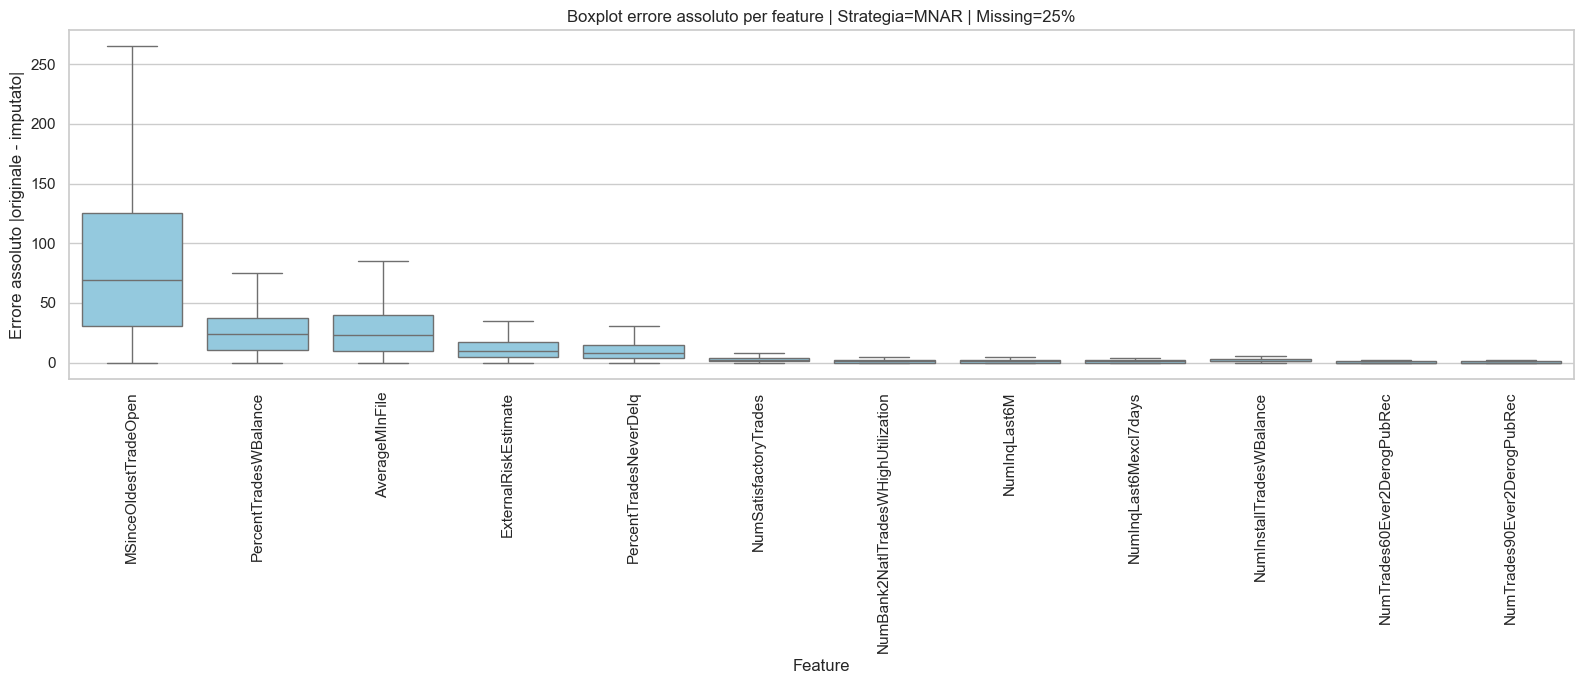

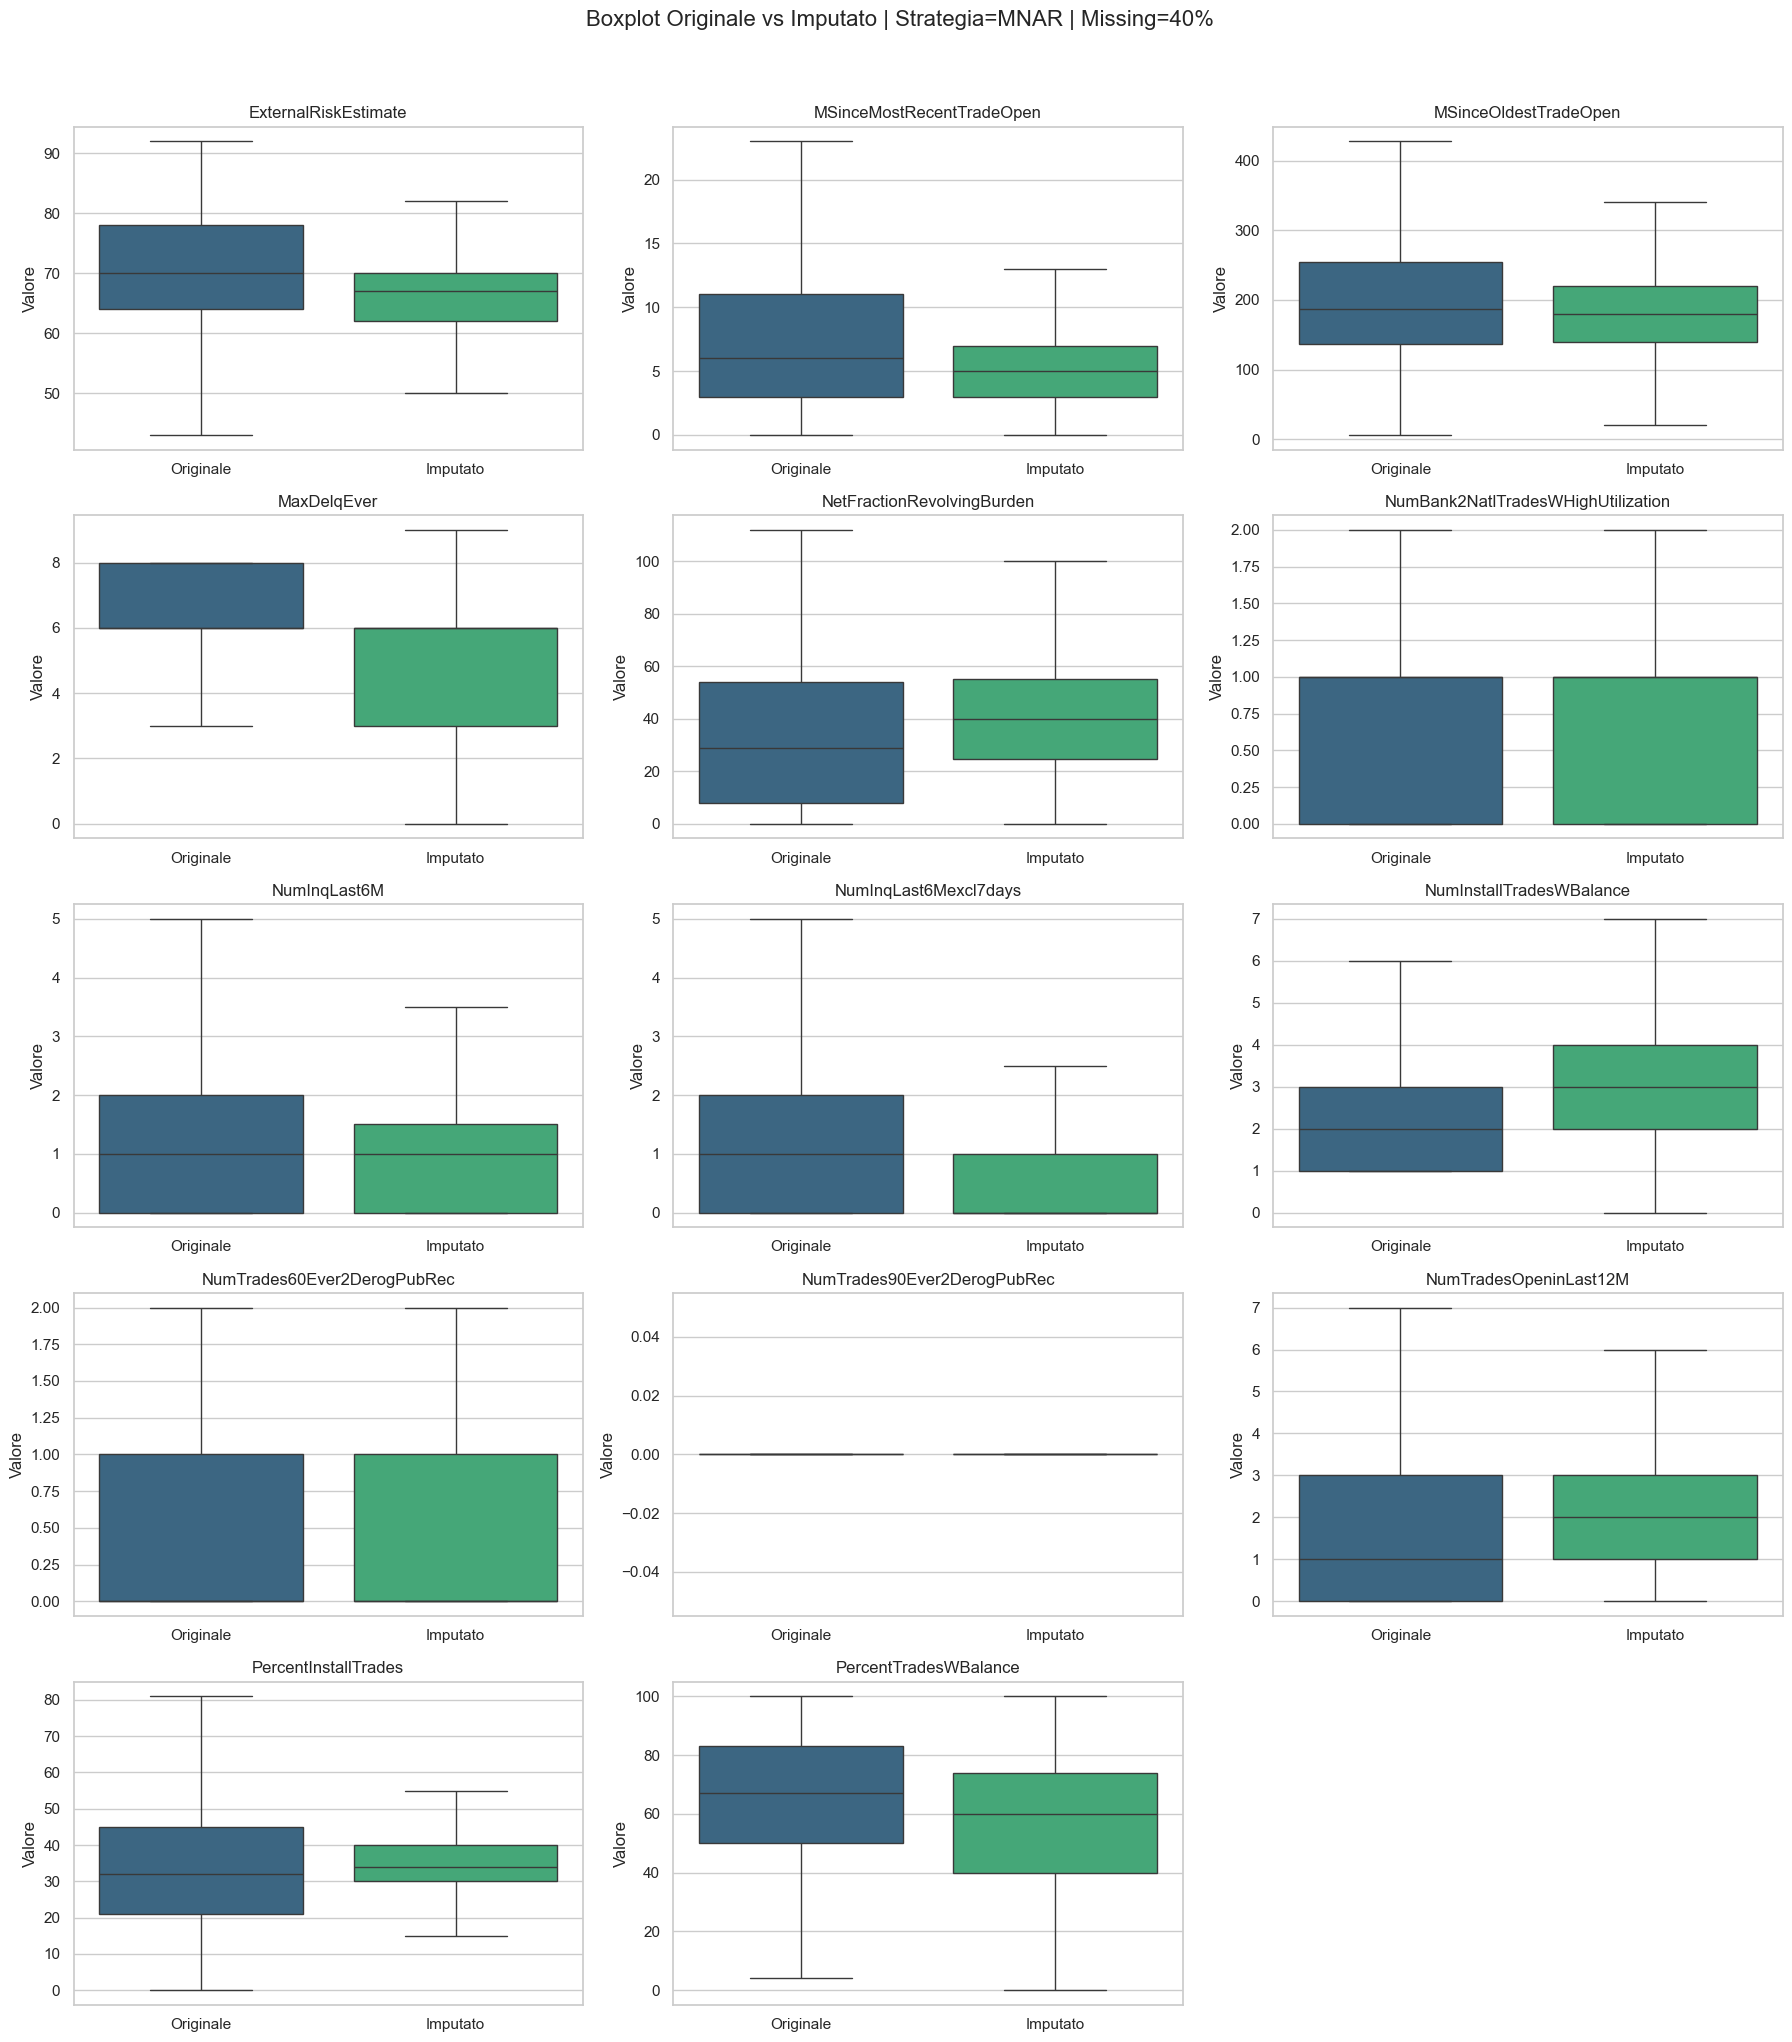

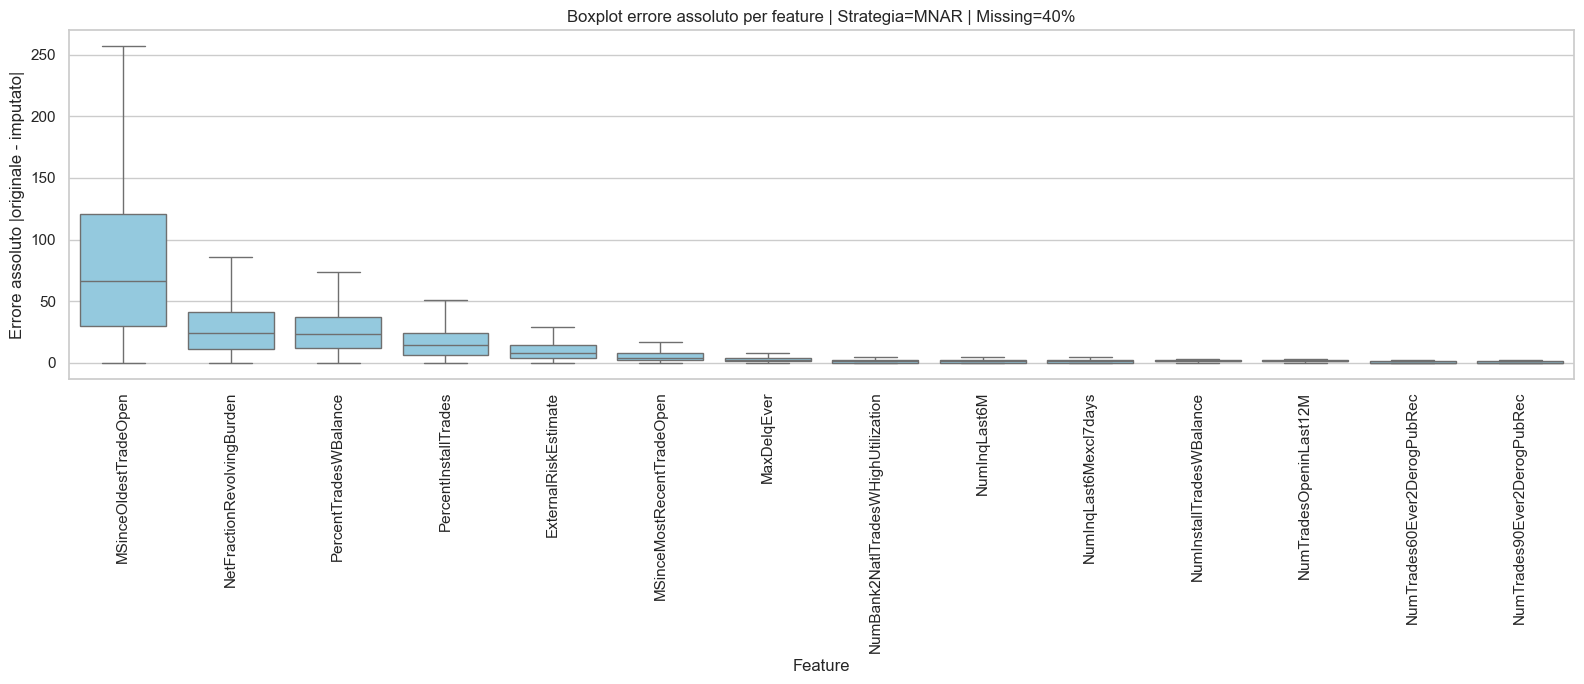

In [32]:
#esegue il ciclo per generare i boxplot dei valori originali vs imputati e degli errori assoluti per ogni strategia e percentuale di missingness
for strategy in sorted(df_feature_metrics['missing_strategy'].unique()):
    for pct in sorted(df_feature_metrics['missing_pct'].unique()):
        plot_feature_boxplots_values(df_box_values, strategy=strategy, pct=pct, features_per_row=3)
        plot_feature_boxplots_errors(df_box_errors, strategy=strategy, pct=pct, order_by='median')


,feature,mean_mae,mean_rmse,mean_median_shift,total_masked,n_scenarios
0,MSinceOldestTradeOpen,88.901921,121.320389,-7.500000,10129,8
1,AverageMInFile,29.714812,39.530187,0.666667,7952,6
2,NetFractionRevolvingBurden,28.339712,35.200191,9.000000,5756,4
3,PercentTradesWBalance,26.544658,32.149993,-10.333333,7597,6
4,PercentInstallTrades,17.169509,21.674828,0.642857,9125,7
5,ExternalRiskEstimate,11.104471,13.862043,-6.000000,4283,4
6,NumTotalTrades,10.980269,14.898672,4.250000,6060,4
7,PercentTradesNeverDelq,10.631372,15.614939,-6.812500,3631,4
8,MSinceMostRecentTradeOpen,7.595688,14.678312,-1.000000,5939,4
9,NumSatisfactoryTrades,6.829352,10.386255,1.200000,7229,5


/var/folders/fy/nhpkc7js7ms2cyqnd8px47t80000gn/T/ipykernel_9253/669332521.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_summary, x='feature', y='mean_mae', palette='viridis')


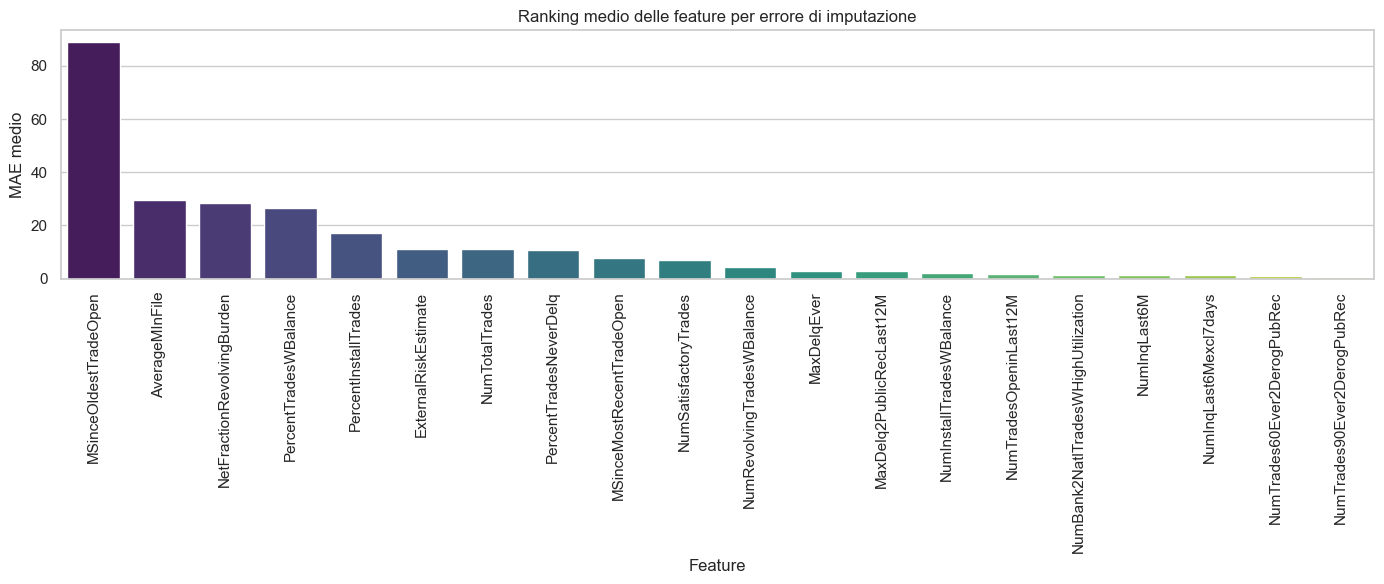

In [33]:
#summary
feature_summary = (
    df_feature_metrics
    .groupby('feature')
    .agg(
        mean_mae=('mae',           'mean'),
        mean_rmse=('rmse',         'mean'),
        mean_median_shift=('median_shift', 'mean'),
        total_masked=('n_masked_valid', 'sum'),
        n_scenarios=('feature',    'count')
    )
    .sort_values('mean_mae', ascending=False)
    .reset_index()
)

display(feature_summary)

plt.figure(figsize=(14, 6))
sns.barplot(data=feature_summary, x='feature', y='mean_mae', palette='viridis')
plt.xticks(rotation=90)
plt.xlabel("Feature")
plt.ylabel("MAE medio")
plt.title("Ranking medio delle feature per errore di imputazione")
plt.tight_layout()
plt.show()


Numero feature da plottare: 20
['AverageMInFile', 'ExternalRiskEstimate', 'MSinceMostRecentTradeOpen', 'MSinceOldestTradeOpen', 'MaxDelq2PublicRecLast12M', 'MaxDelqEver', 'NetFractionRevolvingBurden', 'NumBank2NatlTradesWHighUtilization', 'NumInqLast6M', 'NumInqLast6Mexcl7days', 'NumInstallTradesWBalance', 'NumRevolvingTradesWBalance', 'NumSatisfactoryTrades', 'NumTotalTrades', 'NumTrades60Ever2DerogPubRec', 'NumTrades90Ever2DerogPubRec', 'NumTradesOpeninLast12M', 'PercentInstallTrades', 'PercentTradesNeverDelq', 'PercentTradesWBalance']


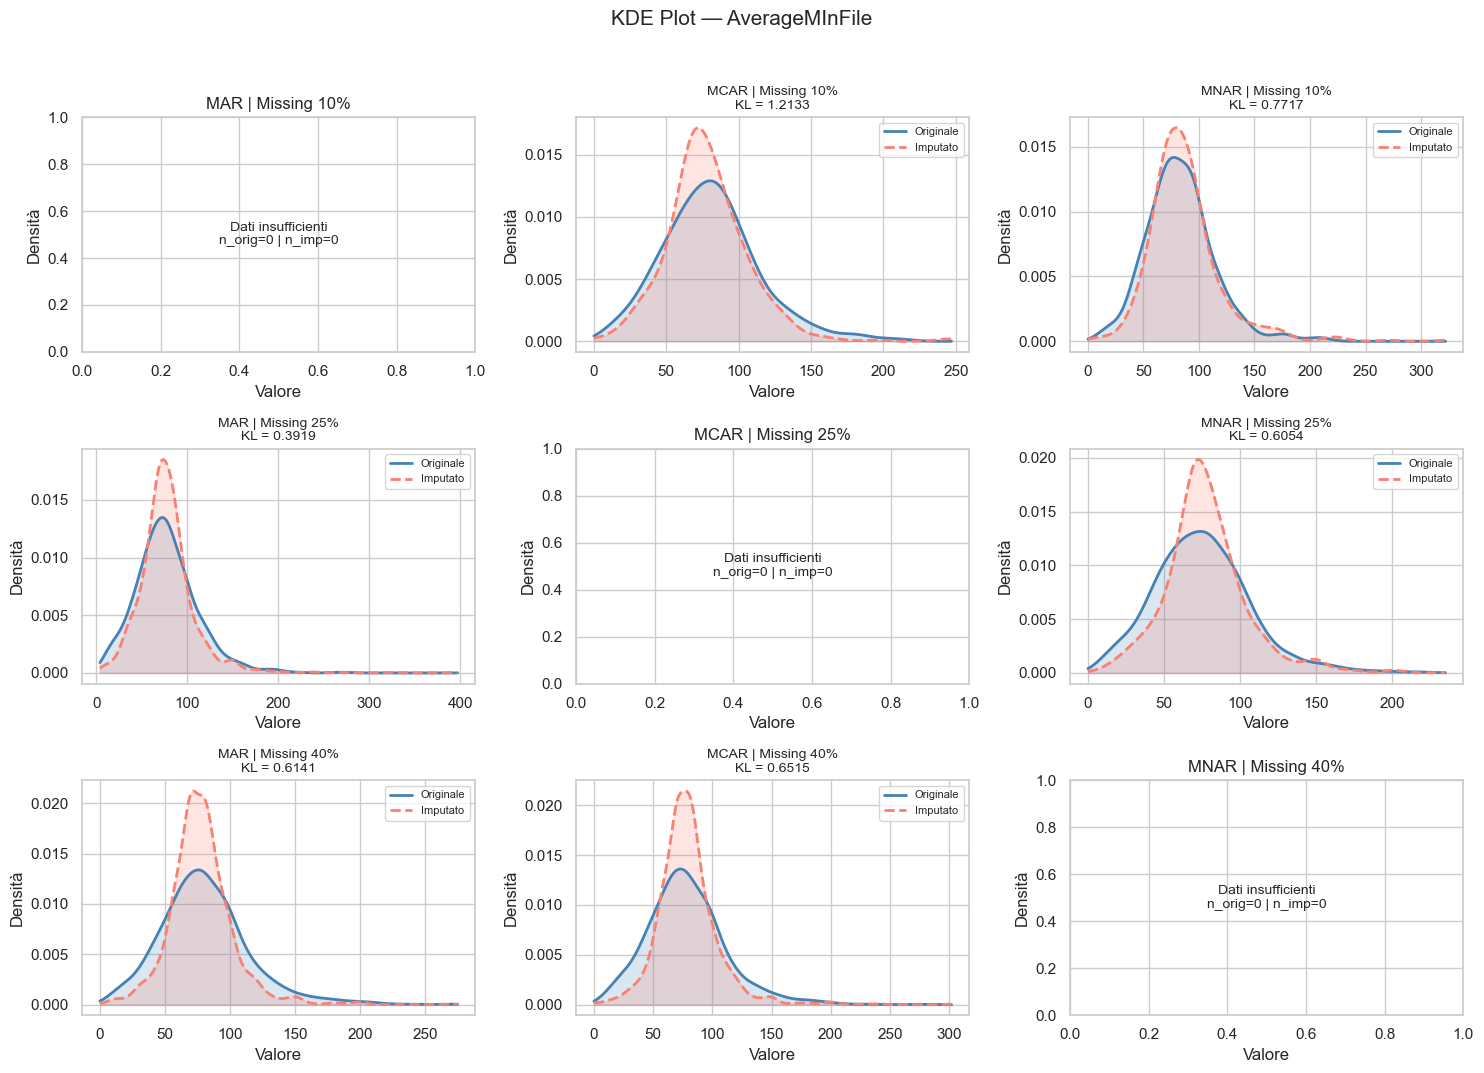

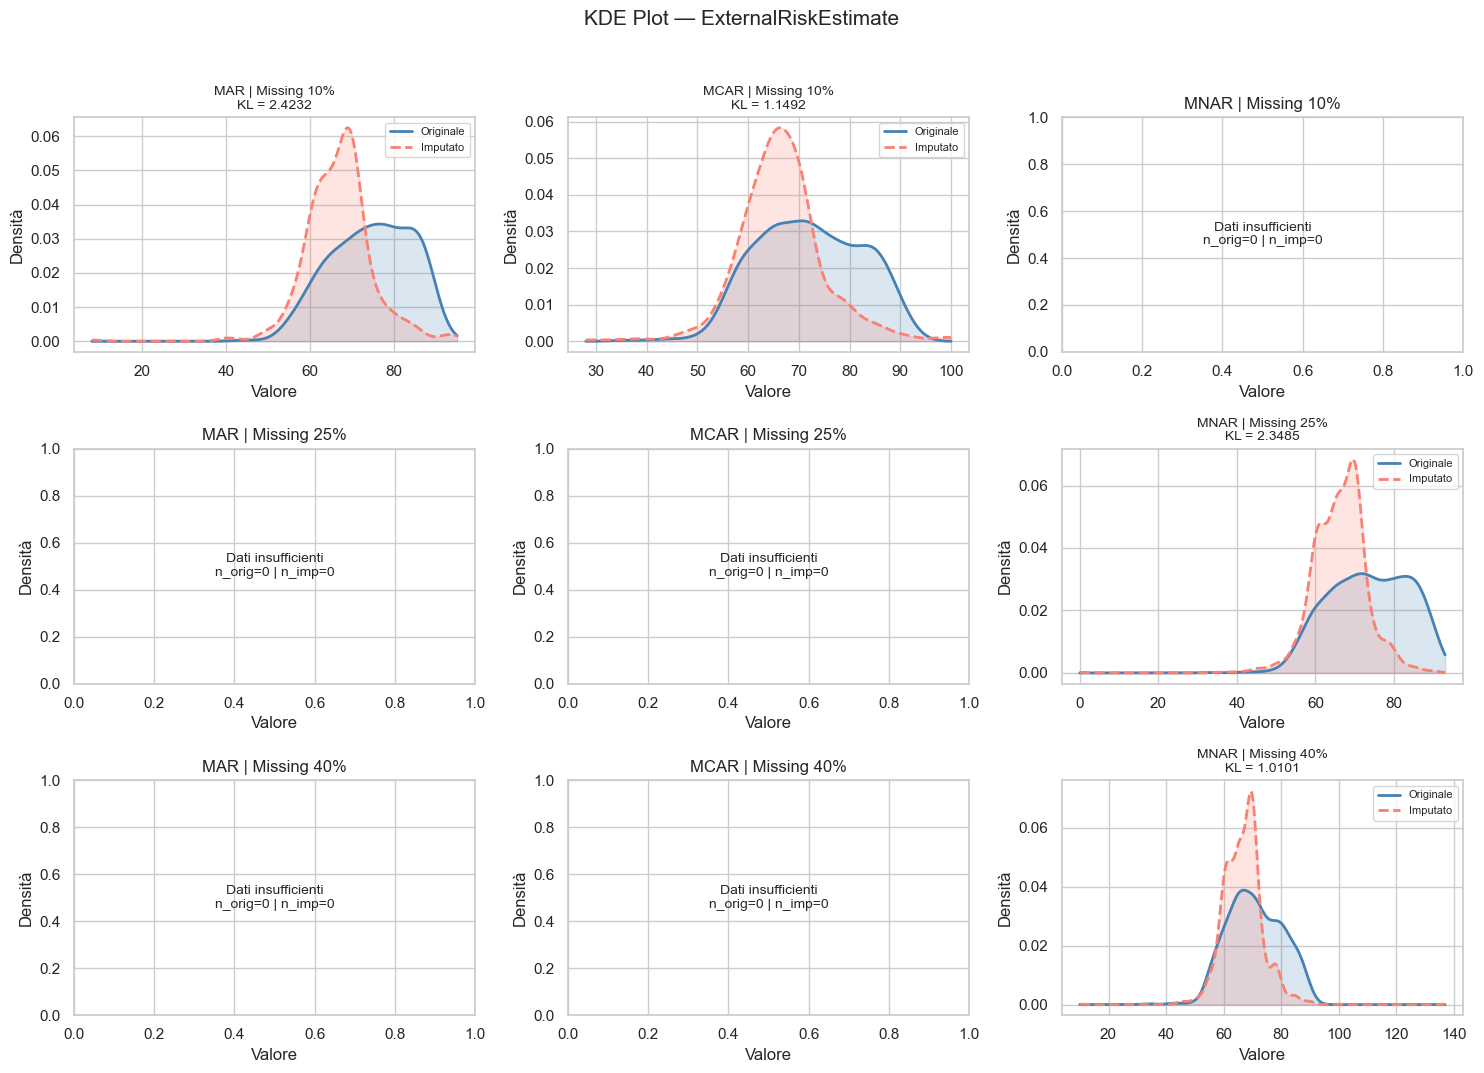

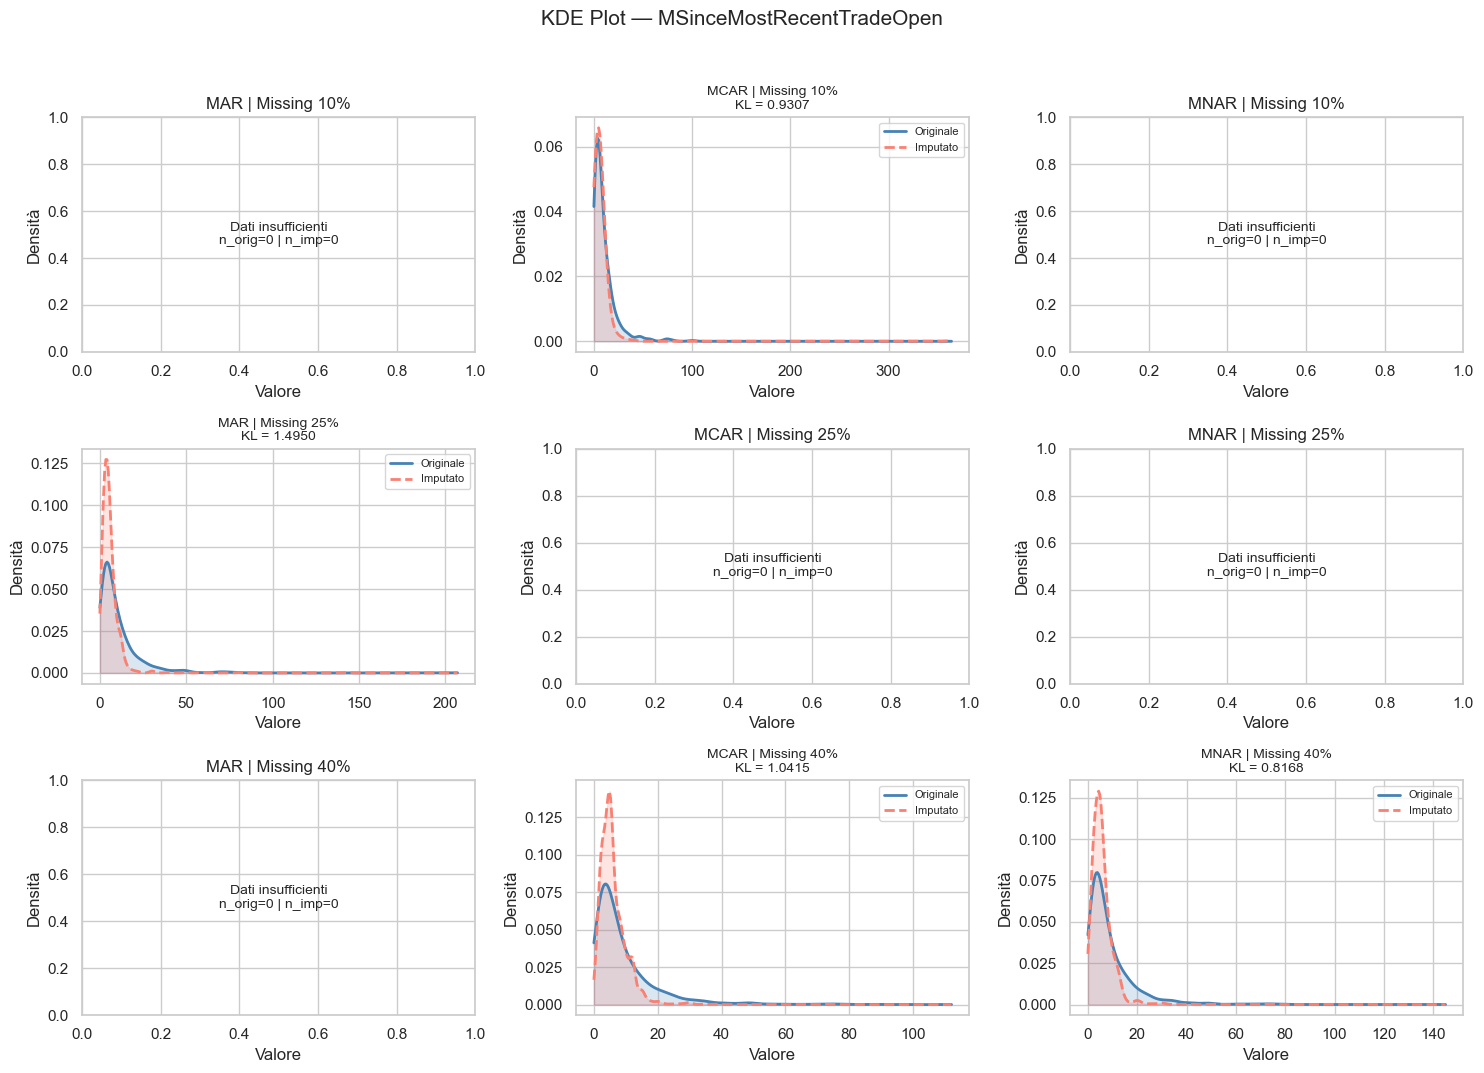

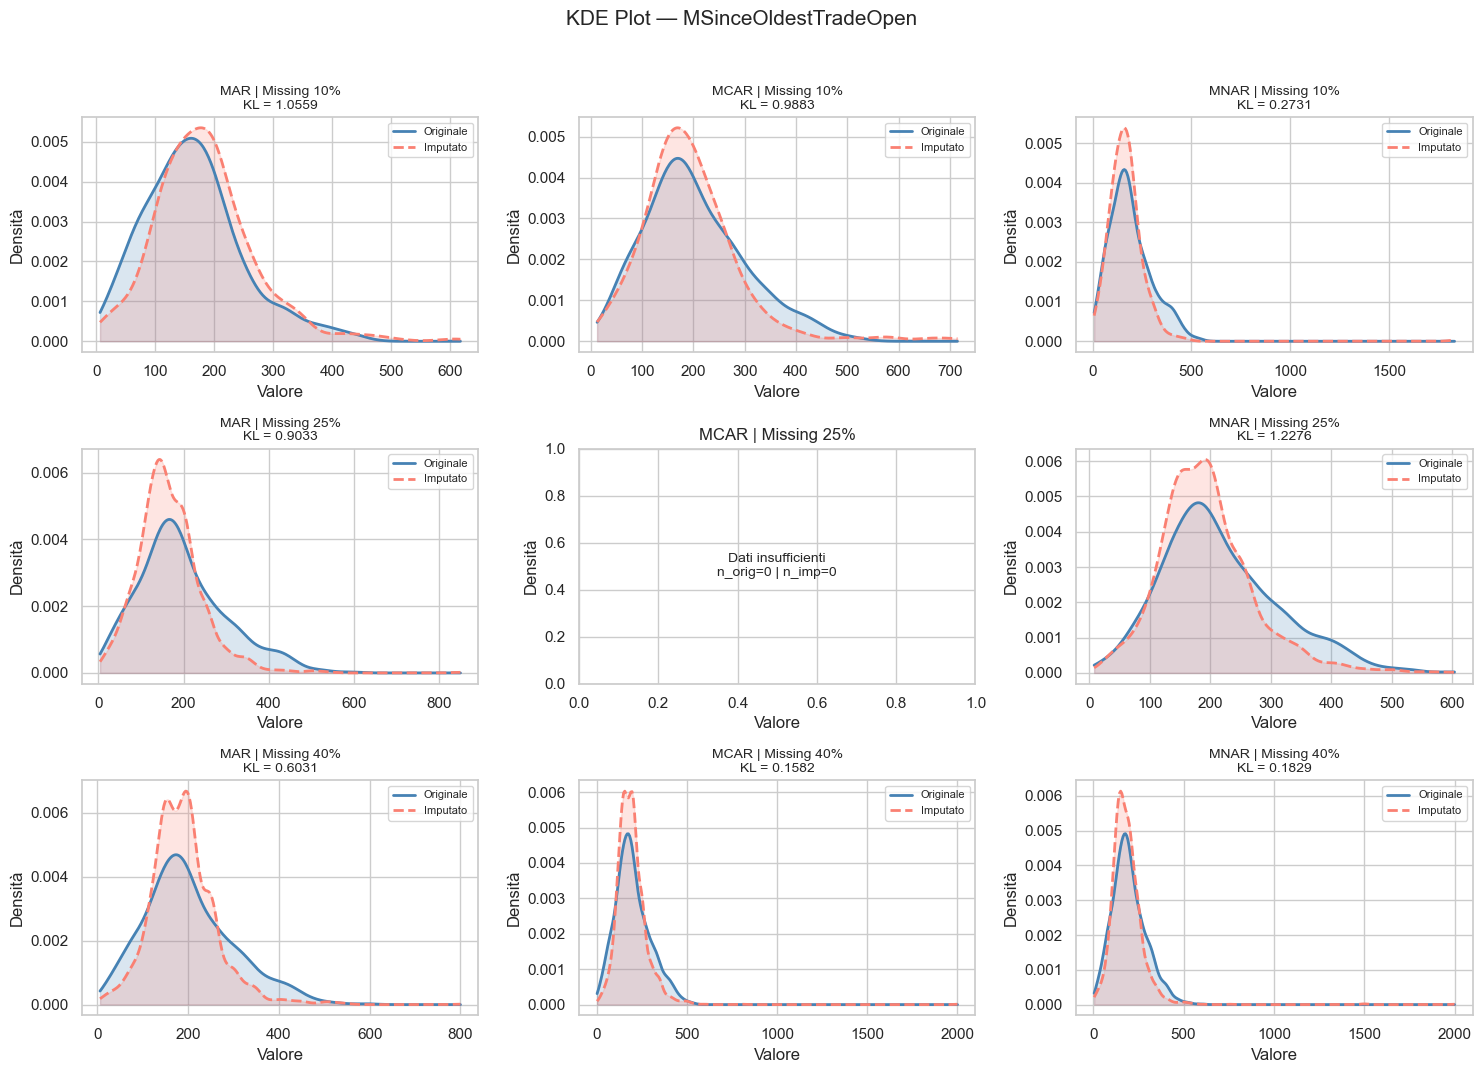

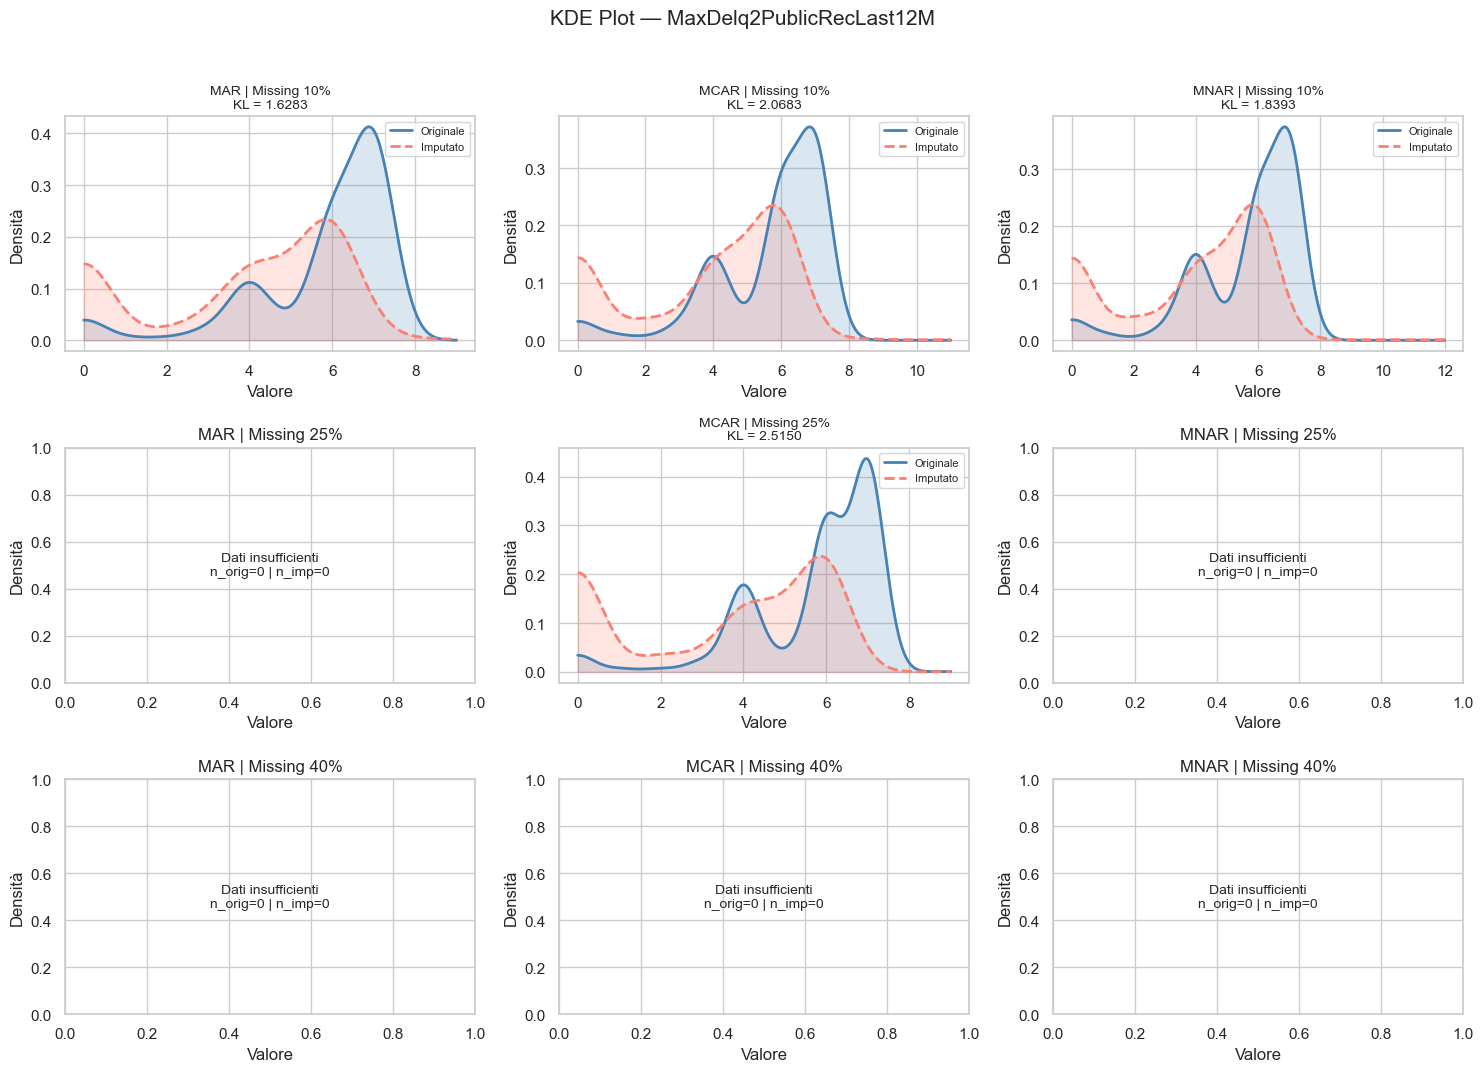

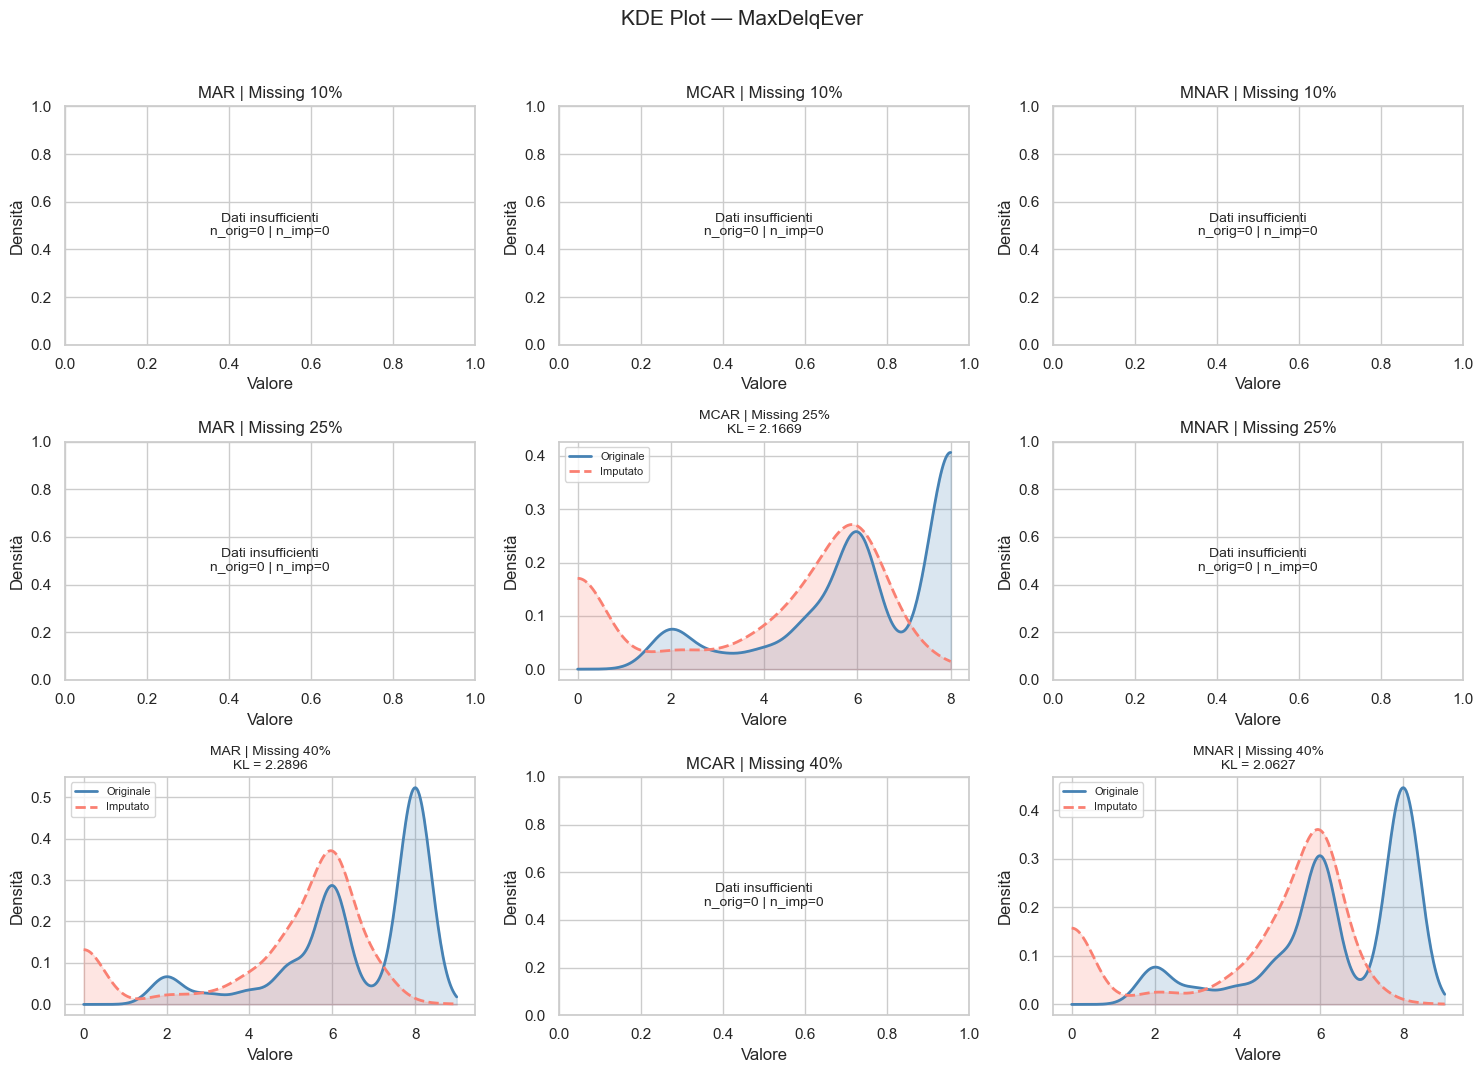

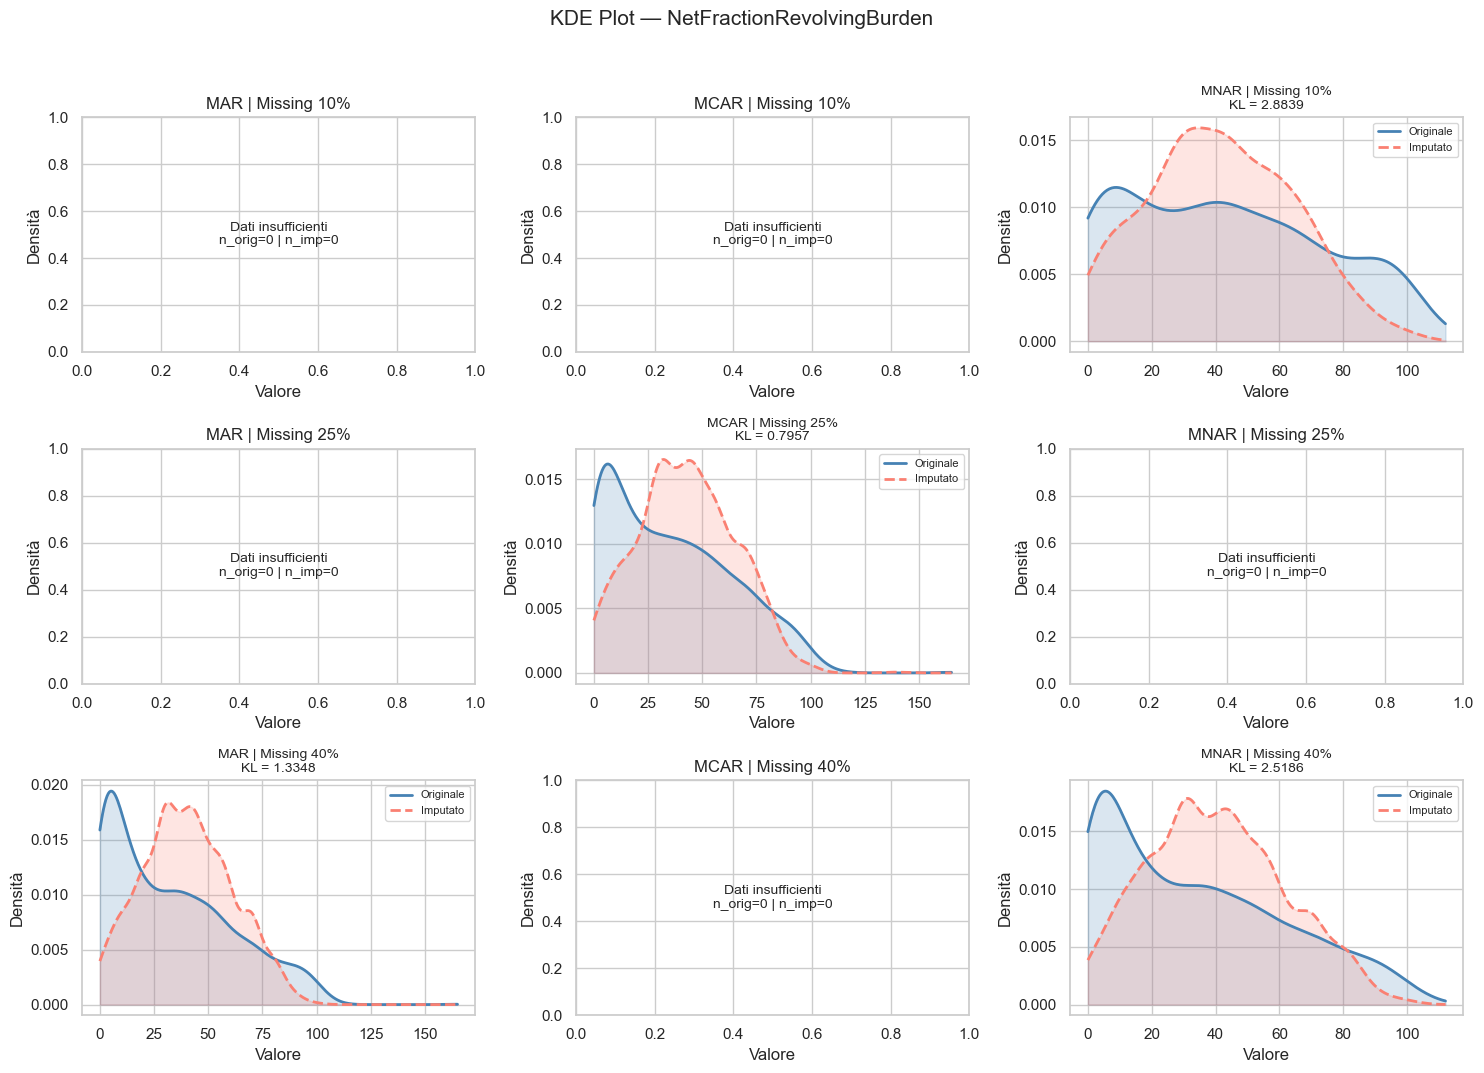

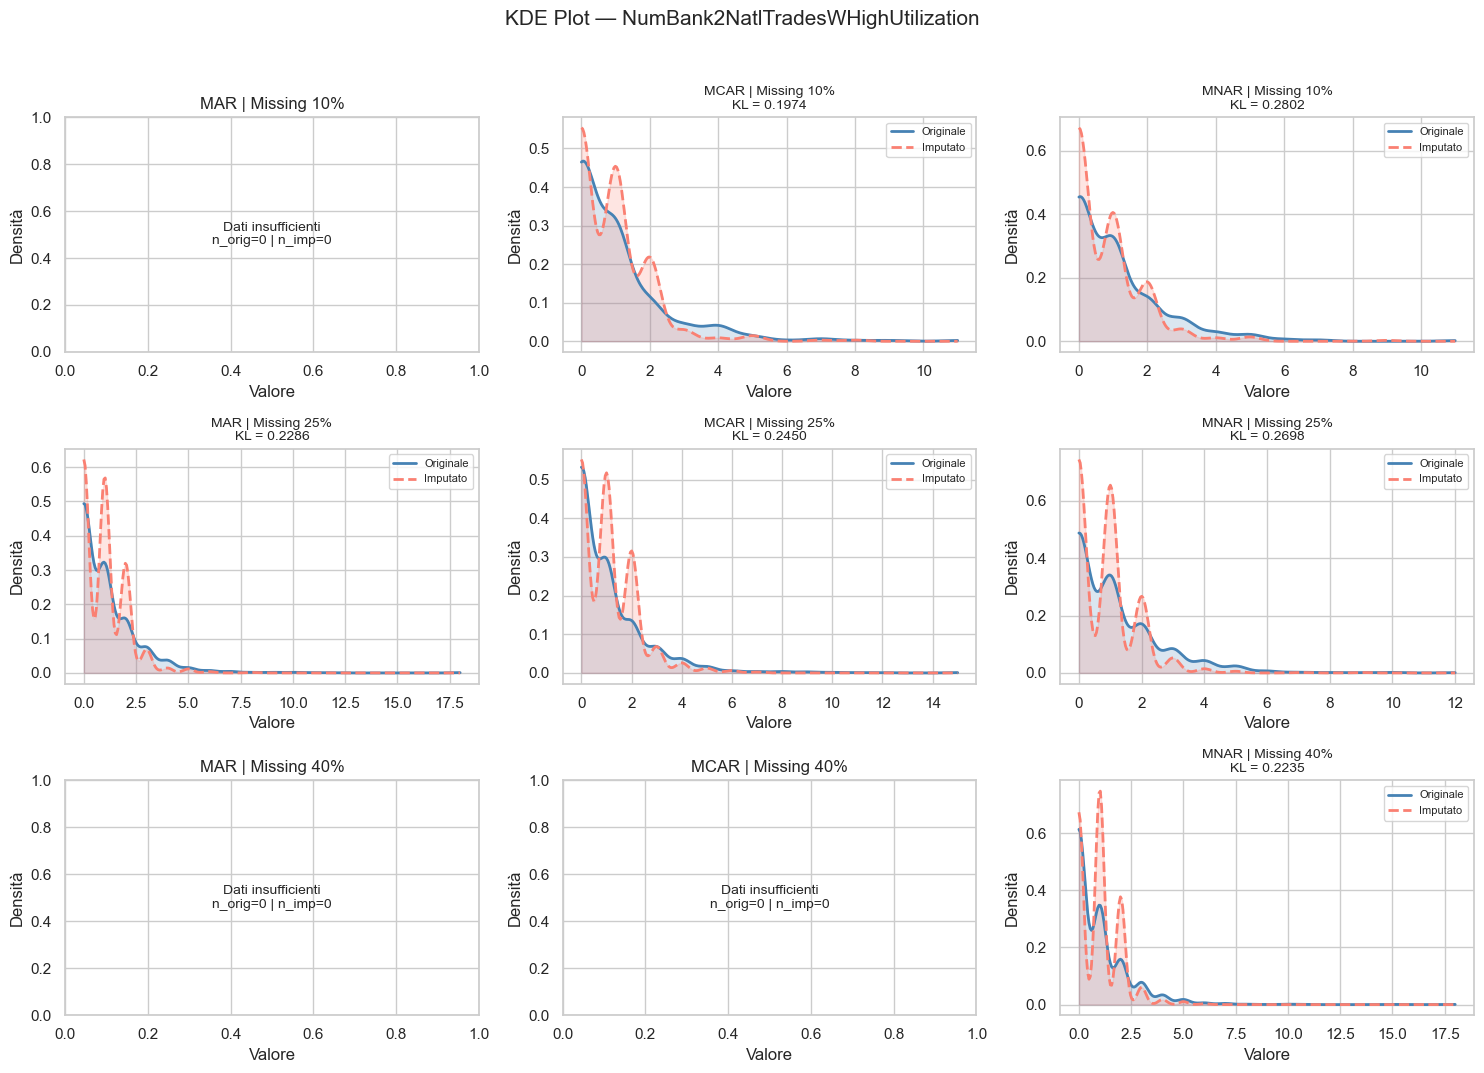

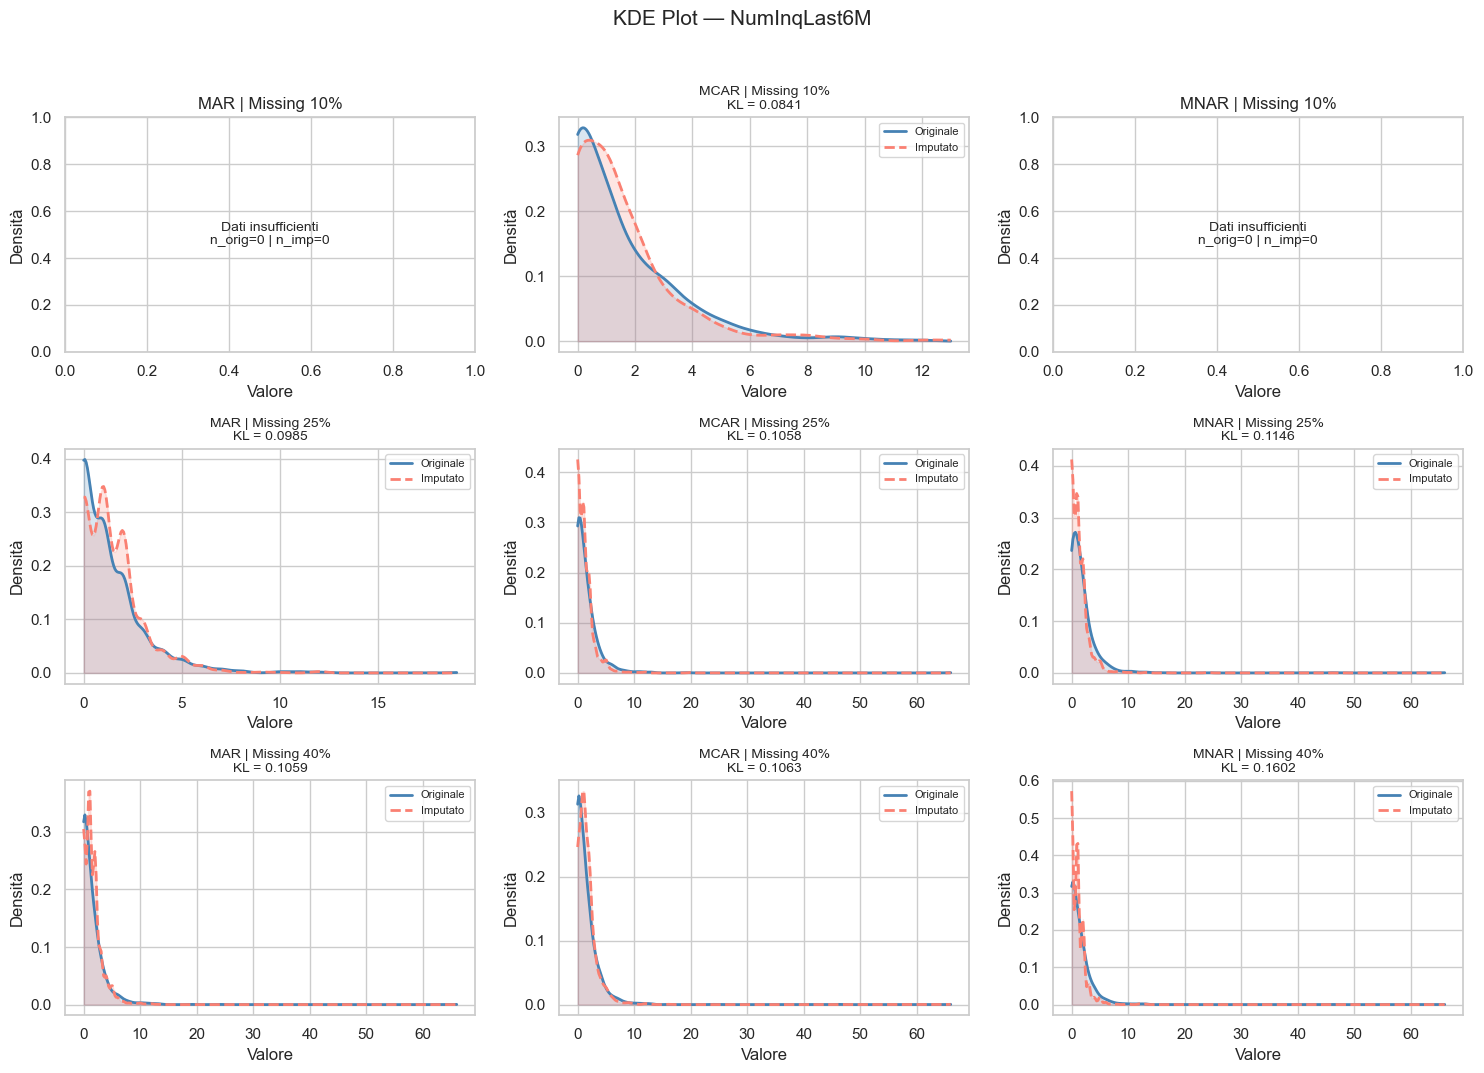

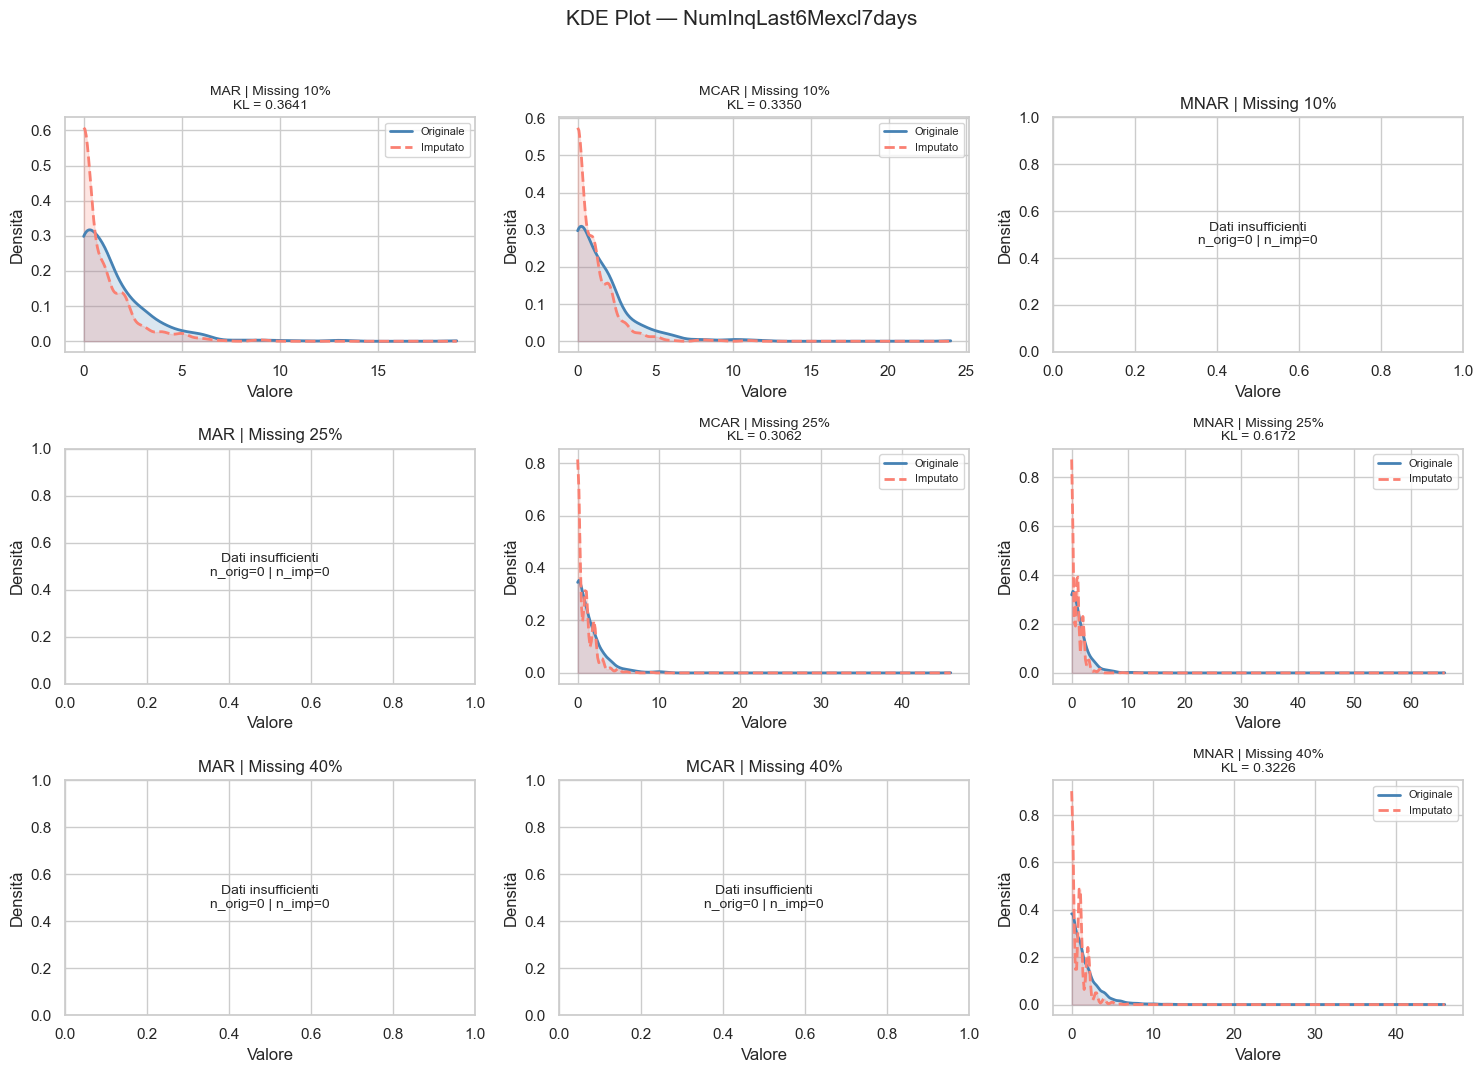

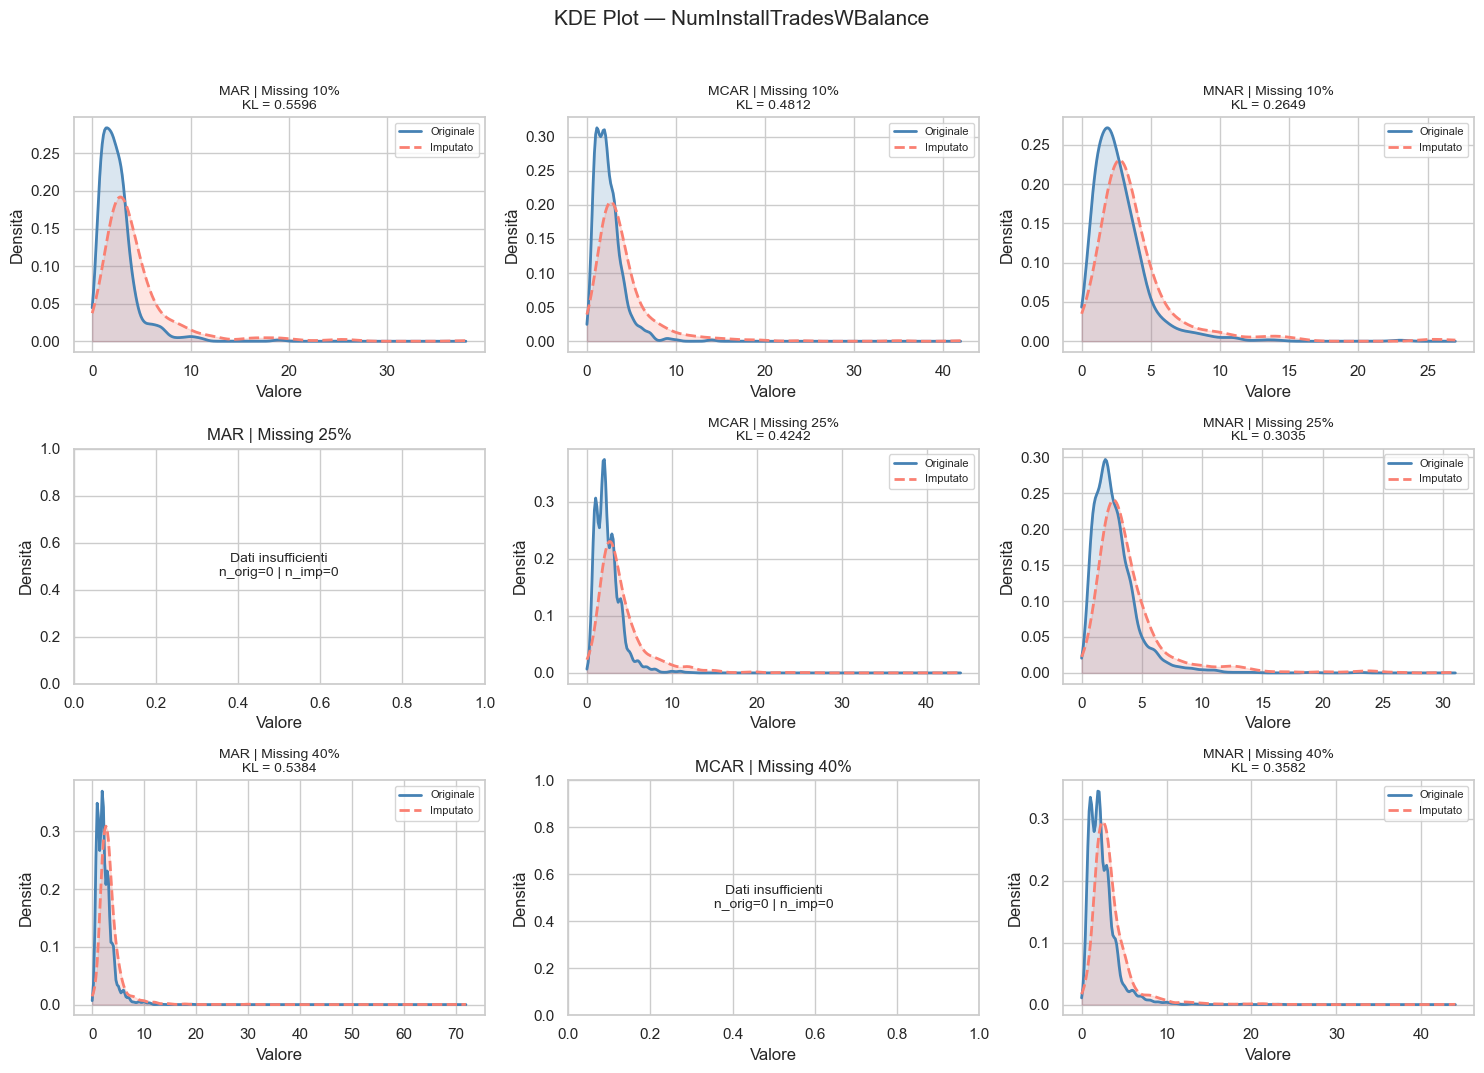

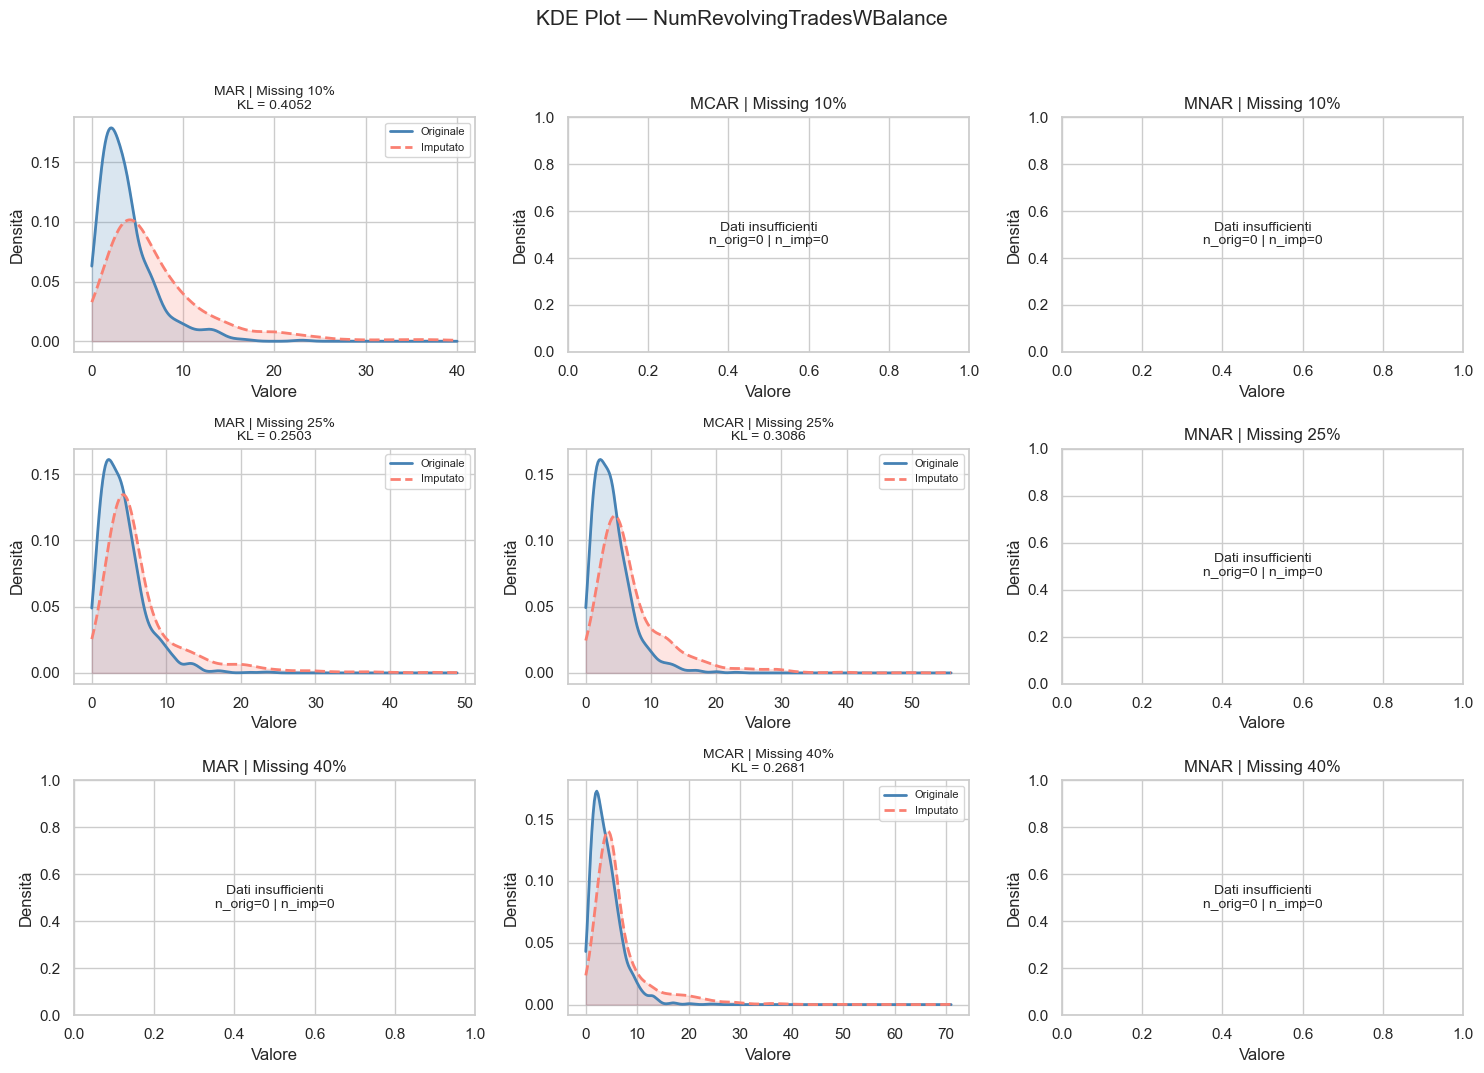

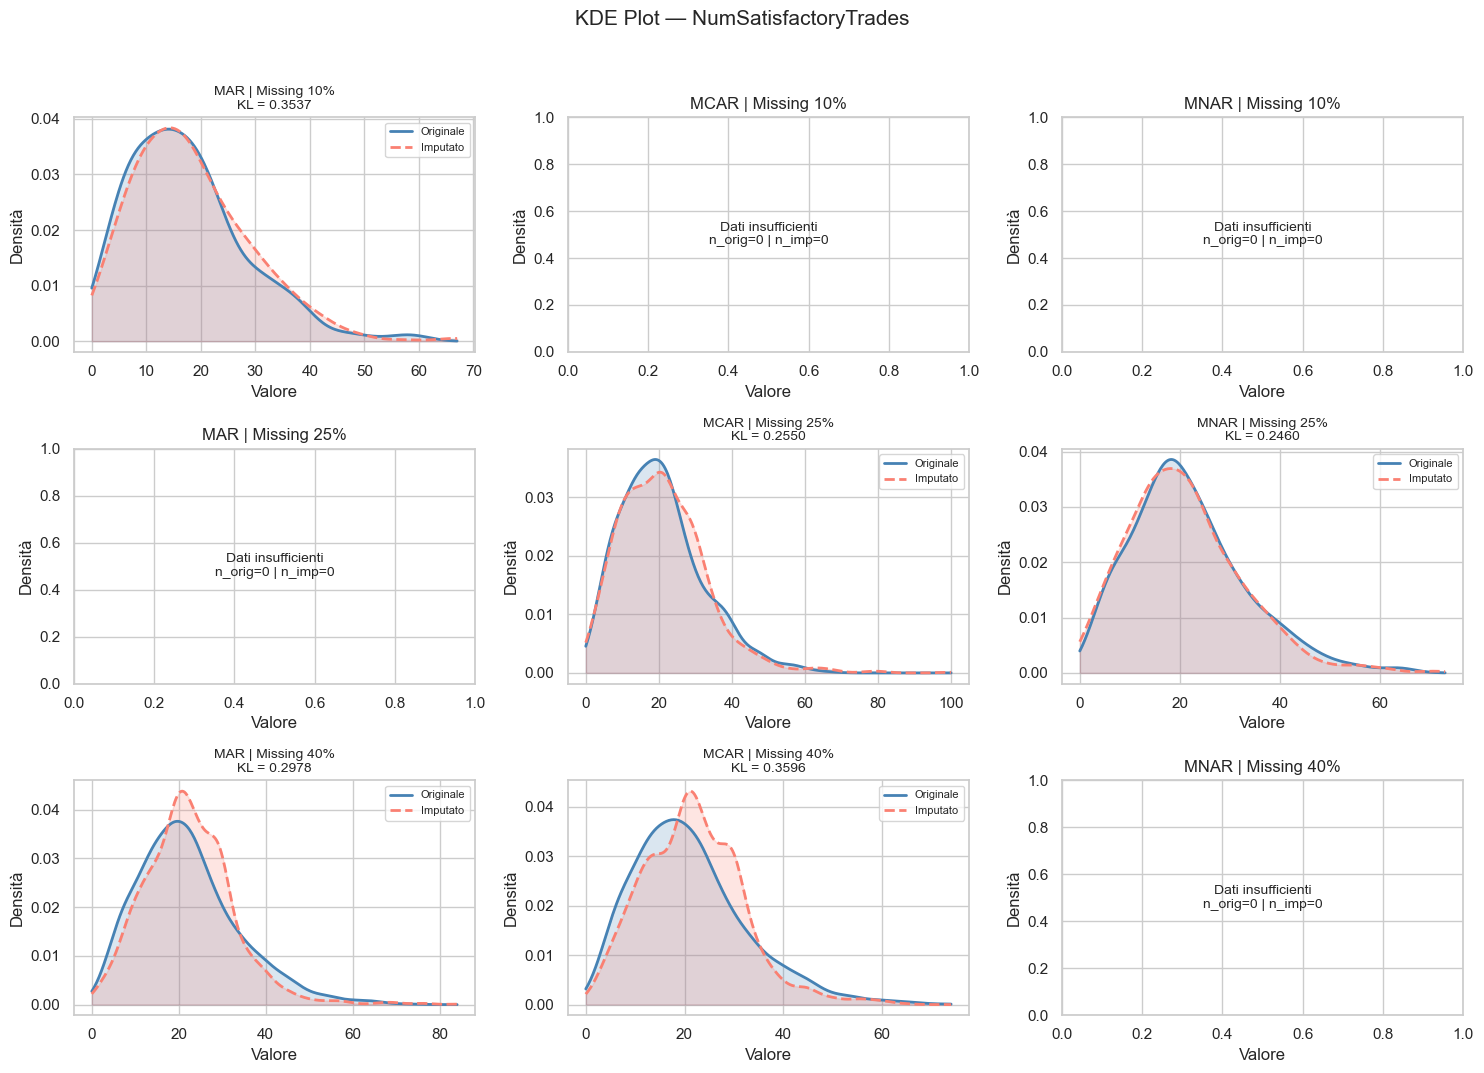

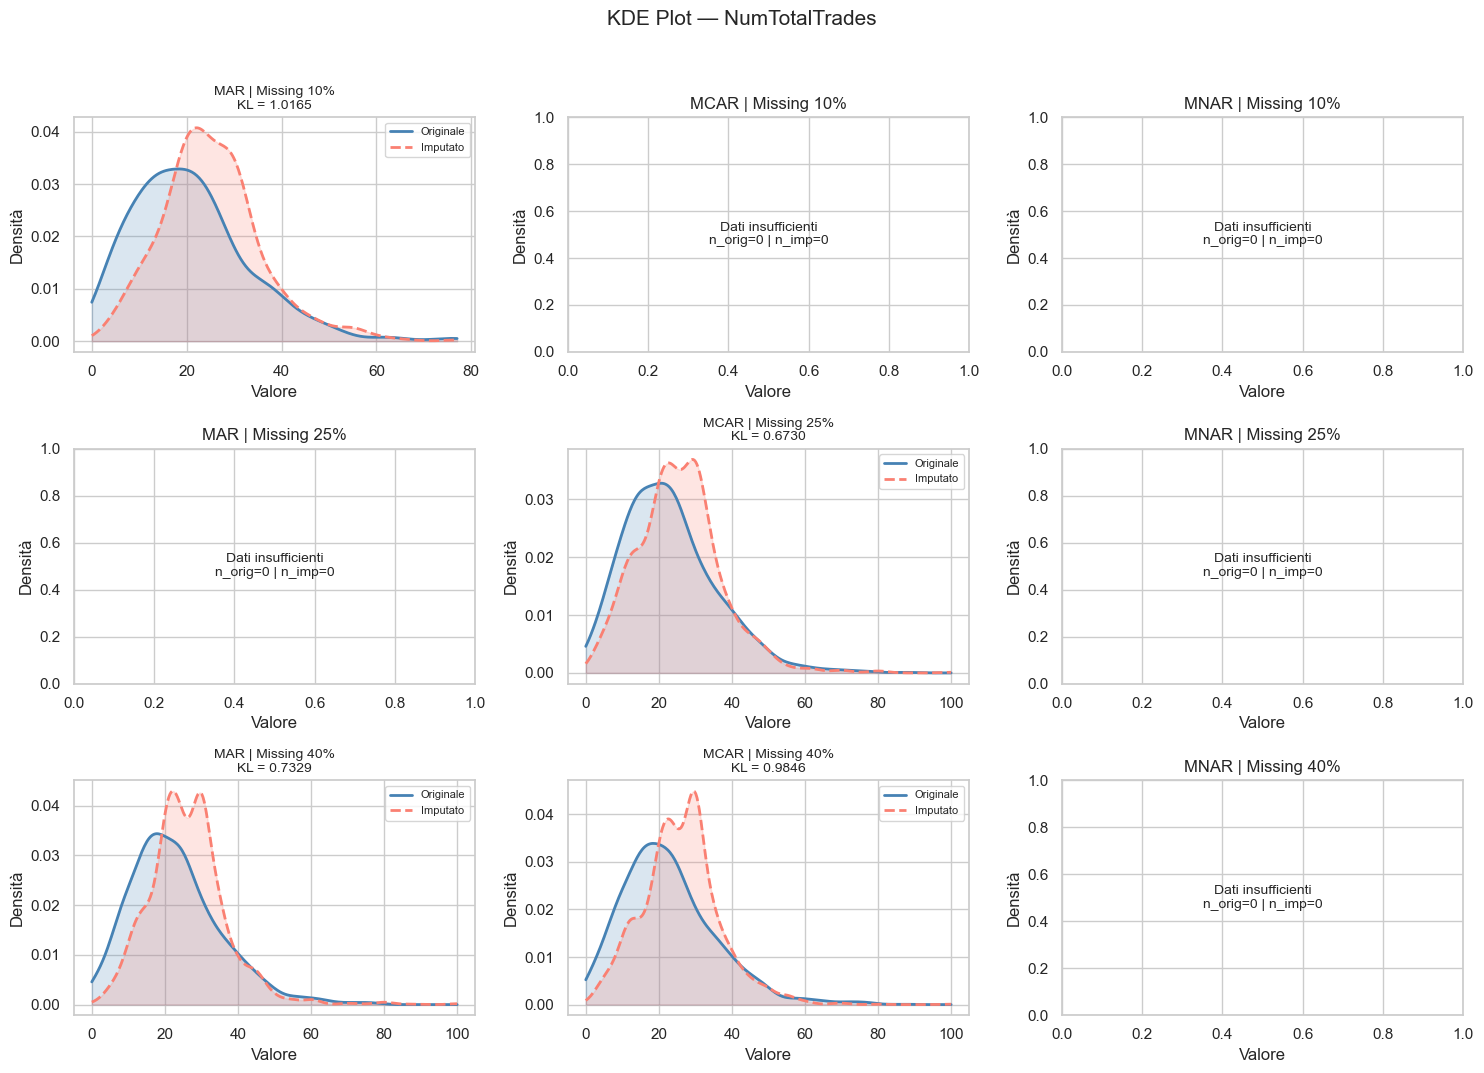

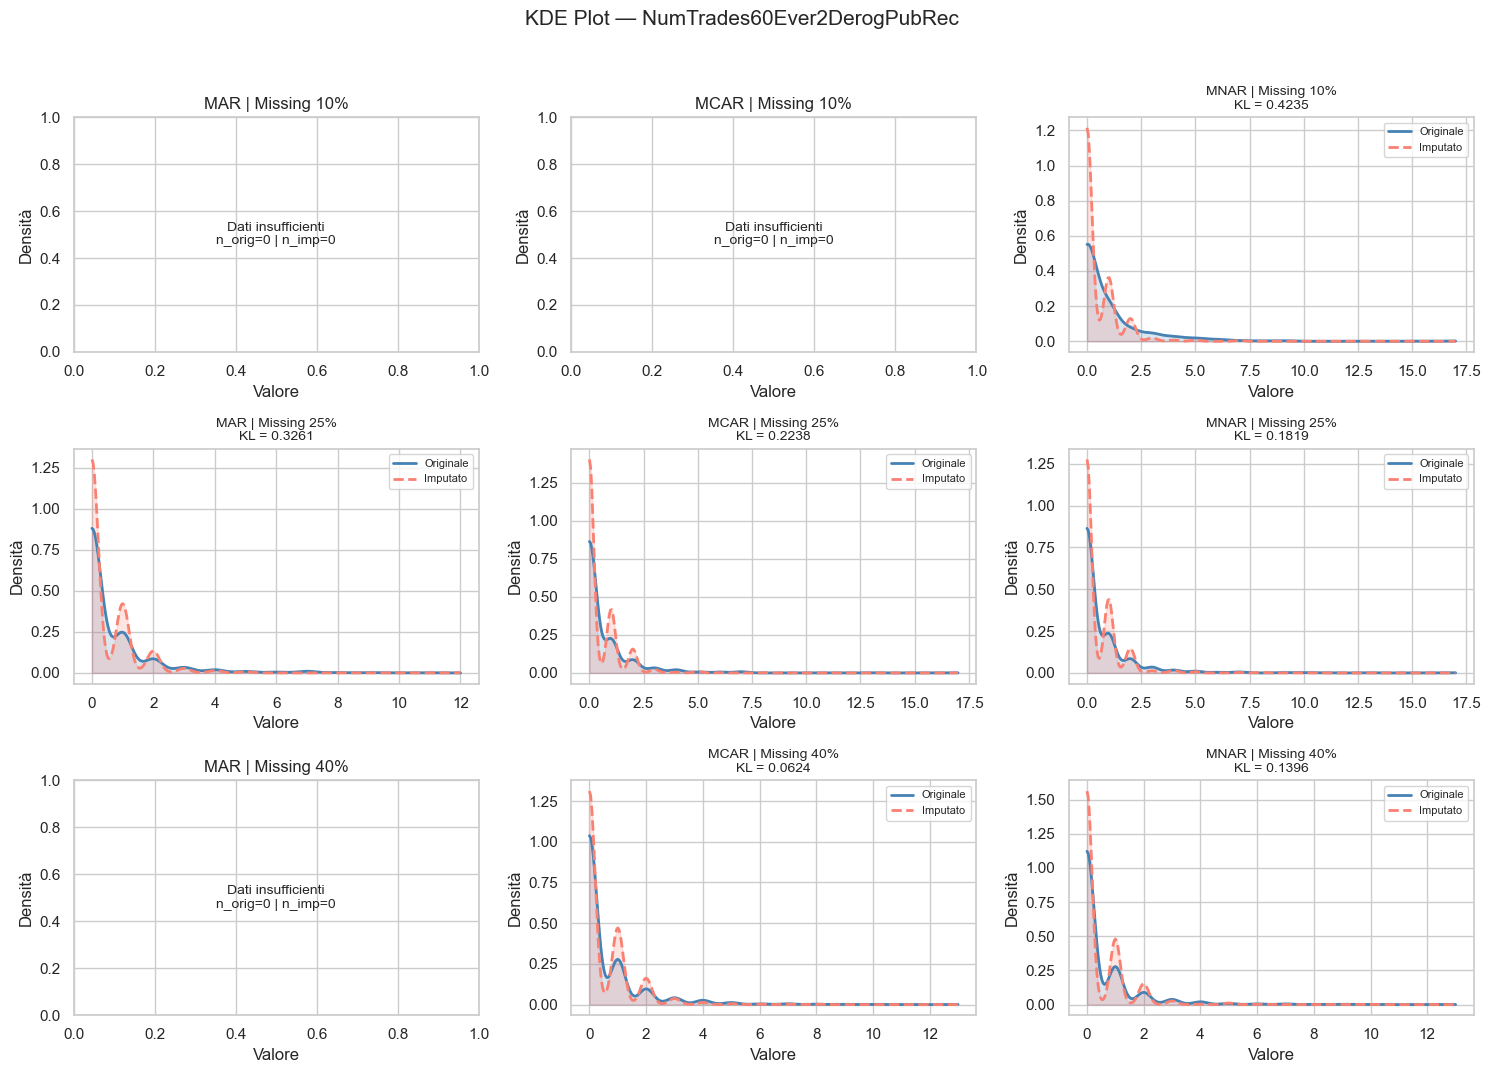

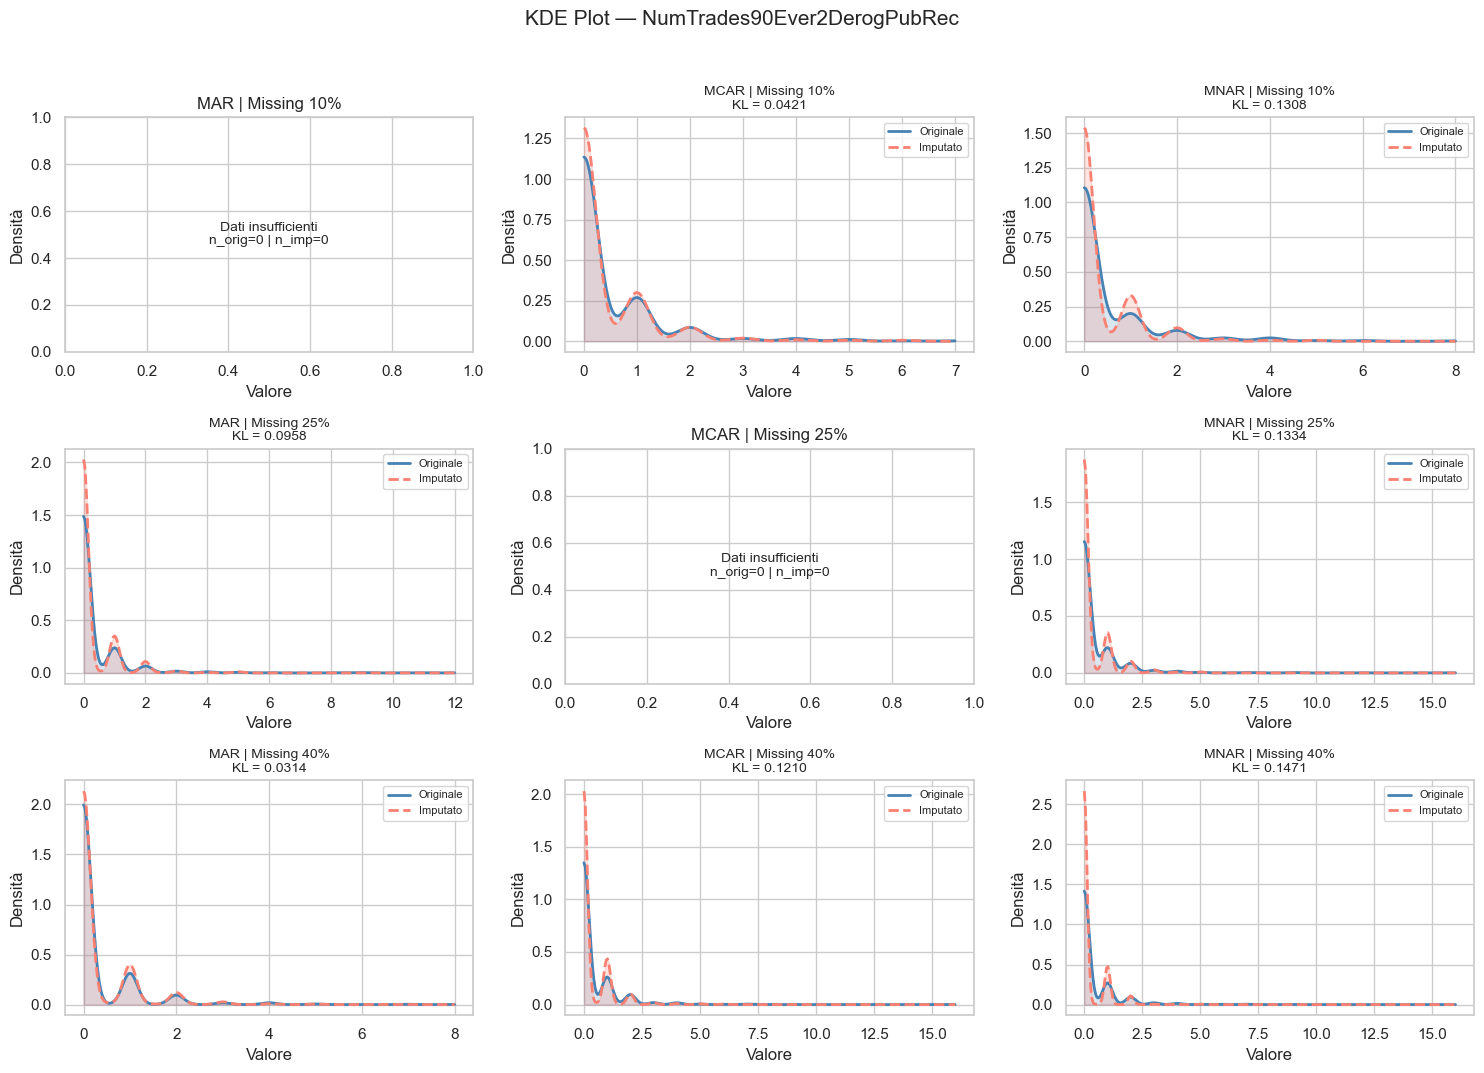

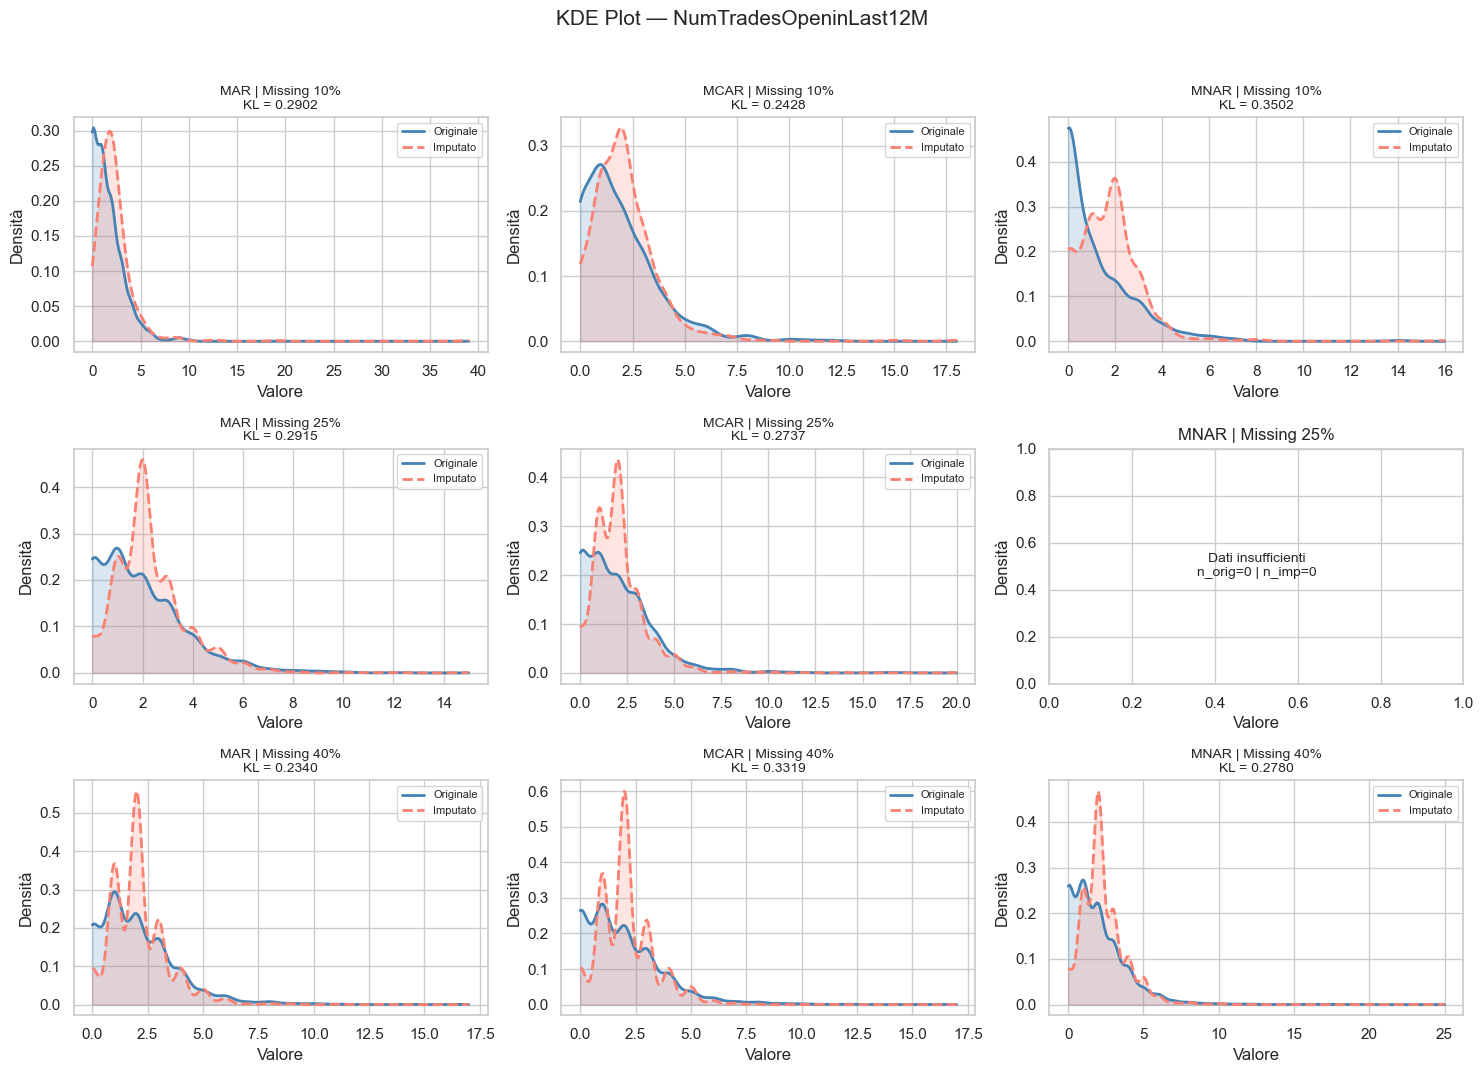

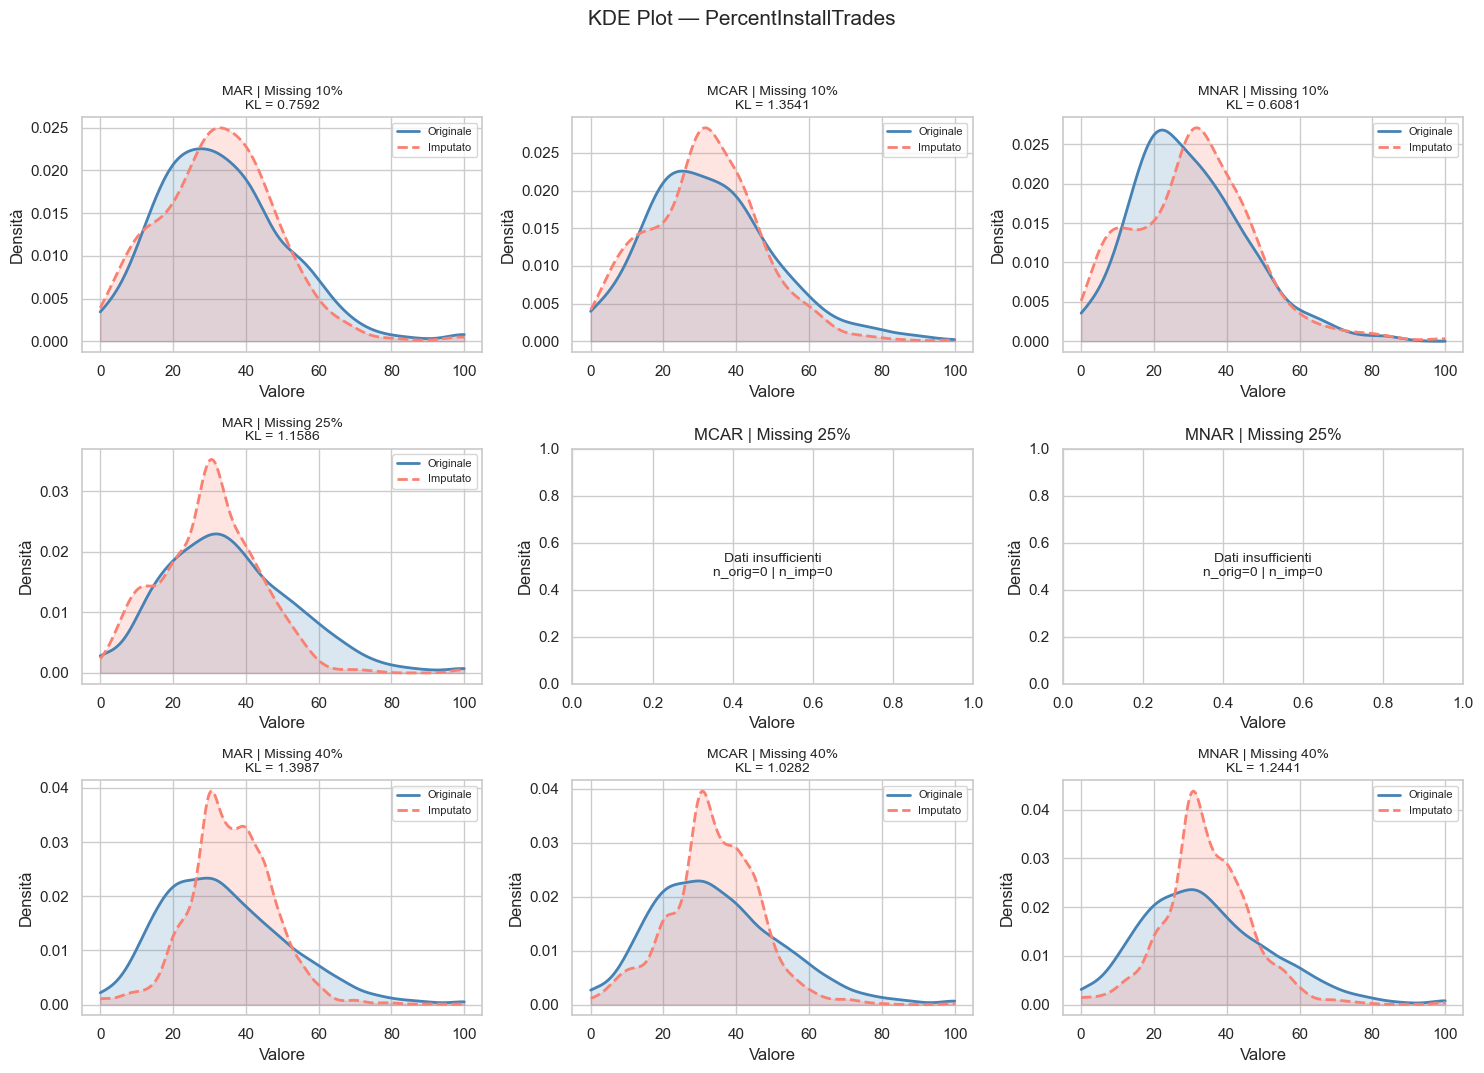

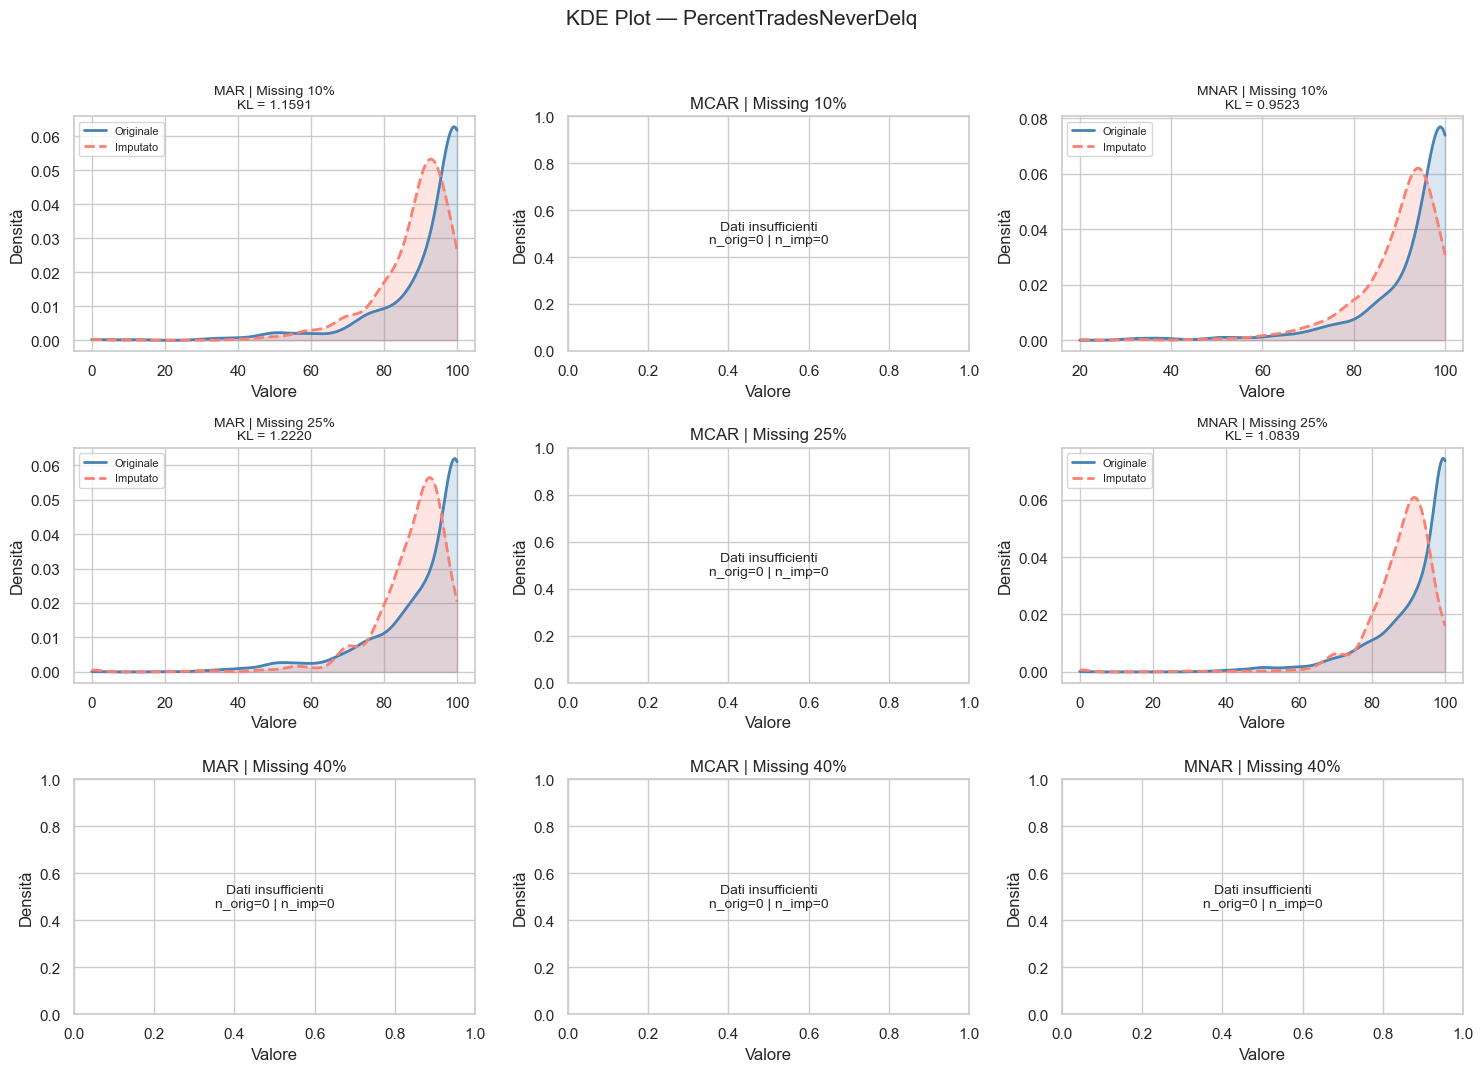

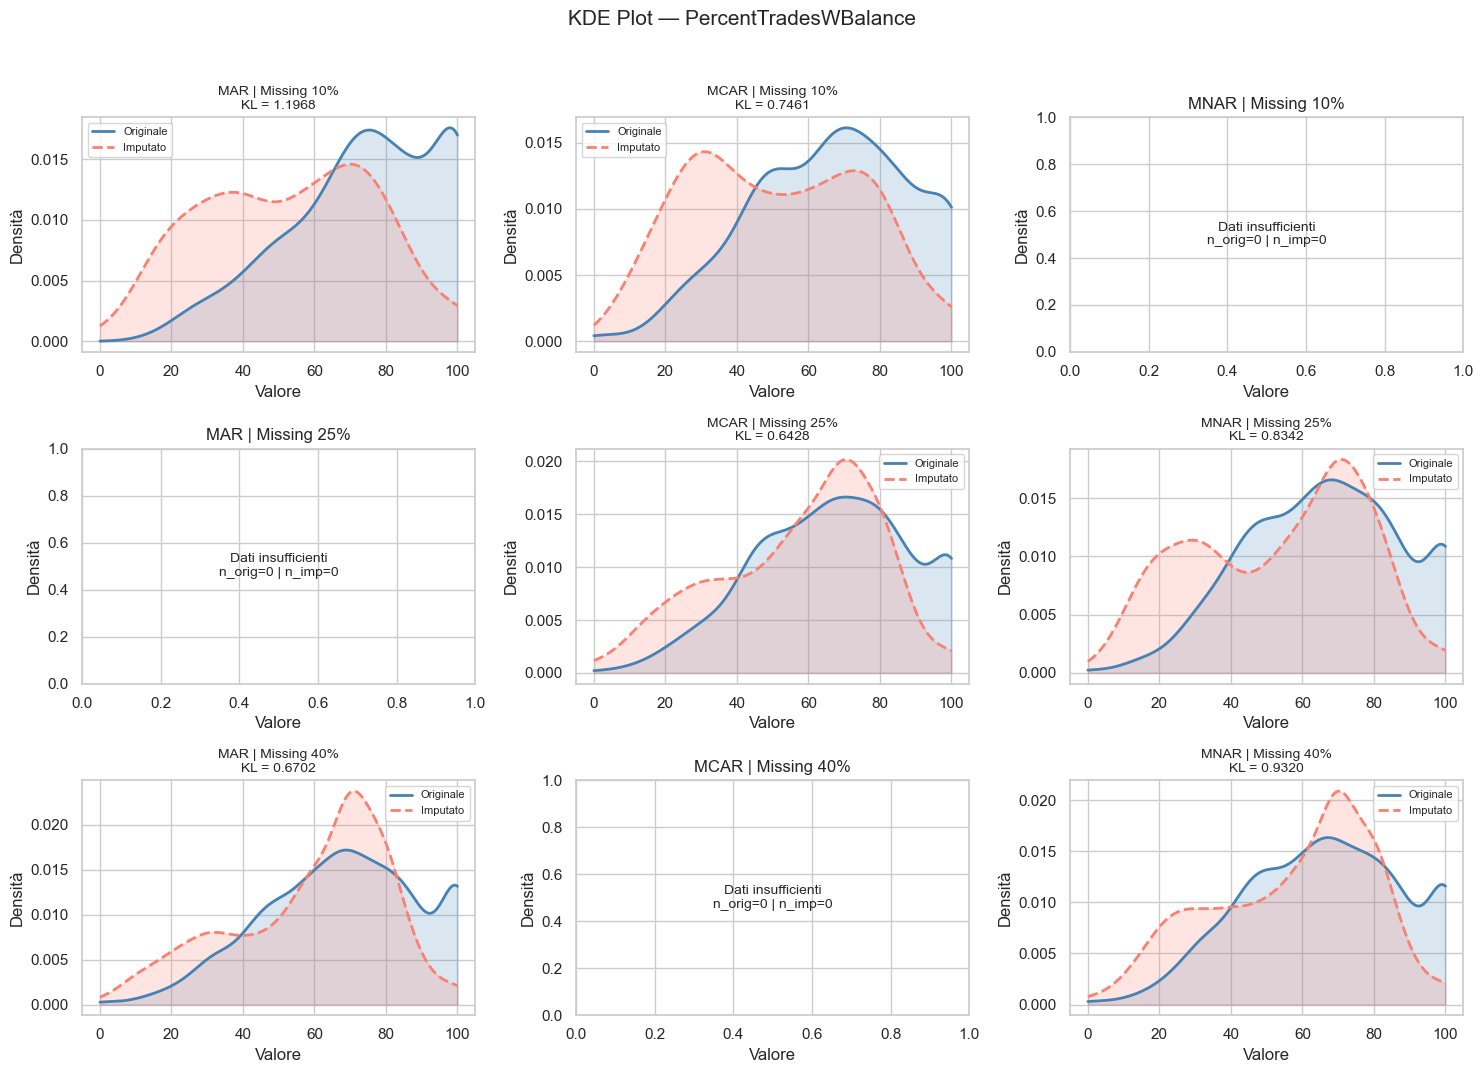

In [44]:
#plot KDE per confrontare la distribuzione dei valori originali vs imputati per ogni feature numerica, per ogni strategia e percentuale di missingness, calcolando anche la KL divergence tra le due distribuzioni
from scipy.stats import entropy, gaussian_kde

def kl_divergence_kde(orig_vals, imp_vals, n_bins=100):
    combined_min = min(orig_vals.min(), imp_vals.min())
    combined_max = max(orig_vals.max(), imp_vals.max())
    bins = np.linspace(combined_min, combined_max, n_bins + 1)

    p, _ = np.histogram(orig_vals, bins=bins, density=True)
    q, _ = np.histogram(imp_vals,  bins=bins, density=True)

    p = p + 1e-10
    q = q + 1e-10
    p = p / p.sum()
    q = q / q.sum()

    return entropy(p, q)


all_features = sorted(df_box_values['feature'].unique())
strategies   = sorted(df_box_values['missing_strategy'].unique())
pcts         = sorted(df_box_values['missing_pct'].unique())

print(f'Numero feature da plottare: {len(all_features)}')
print(all_features)

for feature in all_features:
    fig, axes = plt.subplots(
        len(pcts), len(strategies),
        figsize=(5 * len(strategies), 3.5 * len(pcts)),
        squeeze=False
    )

    for i, pct in enumerate(pcts):
        for j, strategy in enumerate(strategies):
            ax = axes[i][j]

            sub = df_box_values[
                (df_box_values['feature'] == feature) &
                (df_box_values['missing_strategy'] == strategy) &
                (df_box_values['missing_pct'] == pct)
            ]

            orig = sub[sub['value_type'] == 'Originale']['value'].dropna()
            imp  = sub[sub['value_type'] == 'Imputato']['value'].dropna()

            if len(orig) < 5 or len(imp) < 5:
                ax.text(
                    0.5, 0.5,
                    f'Dati insufficienti\nn_orig={len(orig)} | n_imp={len(imp)}',
                    ha='center', va='center',
                    transform=ax.transAxes,
                    fontsize=10
                )
                ax.set_title(f'{strategy} | Missing {pct}%')
                ax.set_xlabel("Valore")
                ax.set_ylabel("Densità")
                continue

            kl = kl_divergence_kde(orig, imp)

            x_min = min(orig.min(), imp.min())
            x_max = max(orig.max(), imp.max())
            x_grid = np.linspace(x_min, x_max, 300)

            y_orig = gaussian_kde(orig)(x_grid)
            y_imp  = gaussian_kde(imp)(x_grid)

            ax.plot(x_grid, y_orig, color='steelblue', linewidth=2, label='Originale')
            ax.plot(x_grid, y_imp,  color='salmon', linewidth=2, linestyle='--', label='Imputato')
            ax.fill_between(x_grid, y_orig, alpha=0.2, color='steelblue')
            ax.fill_between(x_grid, y_imp,  alpha=0.2, color='salmon')

            ax.set_title(f'{strategy} | Missing {pct}%\nKL = {kl:.4f}', fontsize=10)
            ax.set_xlabel("Valore")
            ax.set_ylabel("Densità")
            ax.legend(fontsize=8)

    fig.suptitle(f'KDE Plot — {feature}', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()
